# Predicting Liver Disease from Blood Test Results

**Spring 2026 Data Science Project - CMSC 320**  
**Instructor:** Dr. Fardina Alam  
**Authors:** Edward Xiao, Nikhail Mann, Ocarina Lin, Amber Liu, Ben Tran

In this tutorial, you will learn how to apply the data science life cycle to a real-world data set about liver diseases. Not only will you learn about the topic itself (liver diseases and blood test predictors) but also a run-book of how to apply data science to tackle a real problem!

---

## Contributions

| Member | Sections | Summary |
|---|---|---|
| Edward Xiao | A, B, C, D, E, F, G | Edward contributed across nearly every major part of the project. He helped develop the project idea, select and prepare the dataset, perform exploratory data analysis, build and evaluate the machine learning models, create visualizations, analyze results, and assemble the final tutorial report. |
| Nikhail Mann | A, B, C, D, F, G, H | Nikhail contributed across most parts of the project, including the project idea, dataset selection, preprocessing, EDA, model development, visualization, result interpretation, and final report writing. He also led much of the advanced analysis section, including feature engineering, SMOTE, cross-validation, and comparison with the primary analysis. |
| Ocarina Lin | A, B, C, D, E | Ocarina contributed to the data exploration, machine learning design, and model training/evaluation sections. She helped analyze the dataset, support model development, and interpret the performance of the classification models on the test data. |
| Ben Tran | A, B, C, G | Ben contributed to the project idea, dataset selection, preprocessing, exploratory analysis, and final tutorial report creation. He helped organize the early project direction and supported the write-up of the final report. |
| Amber Liu | A, B, F, G | Amber contributed to the project idea, dataset selection, visualization, result analysis, conclusion, and final tutorial report creation. She helped present the project findings clearly and supported the final organization of the tutorial report. |

**Section Key:**
- A: Project idea
- B: Dataset Curation and Preprocessing
- C: Data Exploration and Summary Statistics
- D: ML Algorithm Design/Development
- E: ML Algorithm Training and Test Data Analysis
- F: Visualization, Result Analysis, Conclusion
- G: Final Tutorial Report Creation
- H: Advanced Analysis


## Table of Contents

1. Introduction
2. Data Curation
3. Data Processing
4. Exploratory Data Analysis
5. Primary Analysis
6. Primary Analysis Insights and Conclusions
7. Advanced Analysis
8. Looking Forward and Next Steps

<a id="sec-intro"></a>
## 1. Introduction

Hepatitis C is a viral infection that affects the liver, and if untreated, it can lead to liver diseases, including fibrosis, cirrhosis, and even liver cancer. According to the World Health Organization, it is estimated that 58 million people worldwide are living with chronic Hepatitis C, and around 1.5 million new infections each year. Even though it is curable with antiviral medications, many people don't get diagnosed until late stages because of the lack of noticeable symptoms. 

Stages of Liver Disease:

1. Blood Donor / Healthy - No liver disease; used as a control group.

2. Hepatitis - Active inflammation of the liver caused by the Hepatitis C virus.

3. Fibrosis - Scarring of liver tissue due to prolonged inflammation.

4. Cirrhosis - Advanced, severe scarring that disrupts normal liver function and can lead to liver failure.

Routine blood tests are non-invasive and used to monitor liver health. We hope with our analysis of this data set, we can discovered if will explore blood tests are able to reliably predict which stage of liver disease a patient is in.

### Research Questions

1. Can routine blood lab tests reliably distinguish healthy patients from those with liver disease?

2. Can lab values predict the specific stage of liver disease?

### Why This Matters

Early and accurate detection of liver disease stage is important for treatment decisions. Liver biopsies are the best way for detection, but are invasive and costly. If machine learning models trained on routine blood tests can reliably classify disease stage, they could serve as a low-cost screening tool to prioritize patients for more intensive follow-up.

<a id="sec-collection"></a>

## 2. Data Curation
- **Dataset:** HCV (Hepatitis C Virus) Data Set (UCI Machine Learning Repository)
- **Original URL:** https://archive.ics.uci.edu/dataset/571/hcv+data
- **Rows:** 615 patient records
- **Predictor fields:** demographic + laboratory biomarkers (Age, Sex, ALB, ALP, ALT, AST, BIL, CHE, CHOL, CREA, GGT, PROT)
- **Target field:** Category
  - 0 = Blood Donor / Suspect Blood Donor
  - 1 = Hepatitis
  - 2 = Fibrosis
  - 3 = Cirrhosis

### Pre-model Transformations Performed Here

- Converted categorical strings to numeric form (Sex, Category) for downstream modeling.
- Audited duplicates and missingness before any train/test split.
- Applied median imputation to sparse missing lab values.
- Preserved a raw copy (df_raw) prior to imputation to support leakage-safe preprocessing checks.
- Excluded id from modeling because it is an arbitrary row identifier with no clinical signal.

### Library Imports



In [1]:
from scipy.stats import chi2_contingency, f_oneway, kruskal, binomtest
from scipy.stats import tukey_hsd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<a id="sec-processing"></a>
## 3. Data Processing

The next step of the data science lifecycle is to perform data processing. Data processing entails cleaning and transforming data to a useful form such that one would be able to effectively use it later on for data analysis and ML.

We perform the following steps to prepare the data for analysis:

- **Load** the CSV into a pandas DataFrame and inspect shape, dtypes, and a preview of the first rows.
- **Parse** string columns to numeric types - Sex (male,1 and female,0) and Category (string labels to numerical values 0 - 3).
- **Validate** that there are no duplicate patient IDs.
- **Impute** missing values (ALB, ALP, ALT, CHOL, PROT each have a handful of nulls) using median imputation.
- **Analyze** summary statistics and class/sex distributions to understand the dataset's baseline properties before modeling.


The first step to processing data is to load data into the notebook as a dataframe. In this notebook we choose to use Pandas but there are other options as well such as Polars and Riptable.

In [2]:
# First, let's read in the dataset and check out its properties
df = pd.read_csv('HepatitisCdata.csv')
df.head()


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


We observe from this cell that the data frame has 615 rows and 14 columns. 

In [3]:
df.shape


(615, 14)

Using `df.info`, we can see the data types that we were working with. Specifically, we find that `category` and `sex` are both strings, which might be very annoying for our ML models to use in the future. 

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    str    
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    str    
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), str(2)
memory usage: 67.4 KB


Observe here that the sex column has only the unique values of m and f for male and female. We need this baseline in order for us to have the ability to map them to a numerical value. 

In [5]:
df['Sex'].unique()


<StringArray>
['m', 'f']
Length: 2, dtype: str

Here we perform the mapping from m to 1 and f to 0. Observe that after the mapping, df.h shows that sex is either 1 or 0. 

In [6]:
# Parse strings to int for sex attribute
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0})
df.head()


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


Similarly, we investigate the unique categories that are currently encoded as strings in the data frame. 

In [7]:
df['Category'].unique()


<StringArray>
[         '0=Blood Donor', '0s=suspect Blood Donor',            '1=Hepatitis',
             '2=Fibrosis',            '3=Cirrhosis']
Length: 5, dtype: str

The unnamed zero column is actually an ID, which we can rename to ID in place using `df.rename`. After that, we perform a similar mapping as we did with sex, mapping from category to a numerical value for each possible category of patient. 

In [8]:
# Parse strings to int for category attribute
df.rename(columns={'Unnamed: 0': 'id'}, inplace=True)

category = {
    '0=Blood Donor': 0,
    '0s=suspect Blood Donor': 0,
    '1=Hepatitis': 1,
    '2=Fibrosis': 2,
    '3=Cirrhosis': 3
}

df['Category'] = df['Category'].map(category)
df.head()


,id,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


It's always important to check whether or not data sets have missing values. In this case, we use `df.isna().sum()` in order to figure this out. Here we can find that some of the columns indeed do have missing values, which we will have to do something to amend them. 

In [9]:
# find missing values
df.isna().sum()


id           0
Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

We make a copy of our data frame, as later on we need a clean slate of our data frame in which we didn't employ median interpolation to fill in the missing values. Otherwise, we fill in all of the missing columns with the median of that column, such that we don't have any more missing values. We can verify that again using the same command as we did before. 

In [10]:
df_raw = df.copy()  # preserve pre-imputation data for leak-free ML preprocessing

# use median interpolation to fill missing values
df['ALB'] = df['ALB'].fillna(df['ALB'].median())
df['ALP'] = df['ALP'].fillna(df['ALP'].median())
df['ALT'] = df['ALT'].fillna(df['ALT'].median())
df['CHOL'] = df['CHOL'].fillna(df['CHOL'].median())
df['PROT'] = df['PROT'].fillna(df['PROT'].median())

df.isna().sum()

id          0
Category    0
Age         0
Sex         0
ALB         0
ALP         0
ALT         0
AST         0
BIL         0
CHE         0
CHOL        0
CREA        0
GGT         0
PROT        0
dtype: int64

In [11]:
df.describe()


,id,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000
mean,308.000000,0.253659,47.408130,0.613008,41.620732,68.222927,28.441951,34.786341,11.396748,8.196634,5.366992,81.287805,39.533171,72.044390
std,177.679487,0.742420,10.055105,0.487458,5.775935,25.646364,25.449889,33.090690,19.673150,2.205657,1.123499,49.756166,54.661071,5.398238
min,1.000000,0.000000,19.000000,0.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,154.500000,0.000000,39.000000,0.000000,38.800000,52.950000,16.400000,21.600000,5.300000,6.935000,4.620000,67.000000,15.700000,69.300000
50%,308.000000,0.000000,47.000000,1.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000
75%,461.500000,0.000000,54.000000,1.000000,45.200000,79.300000,33.050000,32.900000,11.200000,9.590000,6.055000,88.000000,40.200000,75.400000
max,615.000000,3.000000,77.000000,1.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


In [12]:
df["Category"].value_counts()


Category
0    540
3     30
1     24
2     21
Name: count, dtype: int64

In [13]:
df["Sex"].value_counts()


Sex
1    377
0    238
Name: count, dtype: int64

We found that:

- There are 615 patients
- No duplicate patient IDs 
- No duplicate rows
- There was imbalance among the difference classes
  - Blood Donor/suspect Blood Donor had 540 patients
  - Hepatitis had 24 
  - Fibrosis had 21,  
  - Cirrhosis had 30
- The dataset is male-skewed: 377 males and 238 females.

For data cleaning:

- Category labels were mapped from strings to integers:
  - 0 for Blood Donor/suspect Blood Donor
  - 1 for Hepatitis 
  - 2 for Fibrosis, 
  - 3 for Cirrhosis
- We mapped Sex from strings to integers: m/f to 1/0
- Missing values in ALB, ALP, ALT, CHOL, and PROT were handled with median imputation.



## 4. Exploratory Data Analysis

Now that we have cleaned our dataset, n ext, we will perform EDA with distribution plots, outlier summaries, and a correlation map. We will also perform hypothesis tests to identify significant relationships between variables.

**References:**
- [seaborn: boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)
- [seaborn: heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

### 4.1 Distribution of Lab Features

In this section, we will visually look at the distribution of lab features to guide what to perform hypothesis tests for.

In [14]:
# We create a helper function in order to be able to reuse it multiple times throughout the codebase whenever we want to make a box plot. 
def make_box_and_whiskers(
    ax,
    series,
    title,
    xlabel,
    label_outliers,
):
    sns.boxplot(
        x=series,
        ax=ax,
        color="royalblue",
        flierprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "red",
            "markersize": 4,
        },
    )

    mean = series.mean()
    median = series.median()
    std = series.std()
    summary = f"Mean: {mean:.2f}, Median: {median:.2f}, Std: {std:.2f}"
    ax.text(1, 1.2, summary, transform=ax.transAxes, ha="right", va="center")

    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    if label_outliers:
        outliers = series[(series < lower) | (series > upper)]
        for val in outliers:
            ax.annotate(
                val,
                xy=(val, 0),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
                color="red",
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)


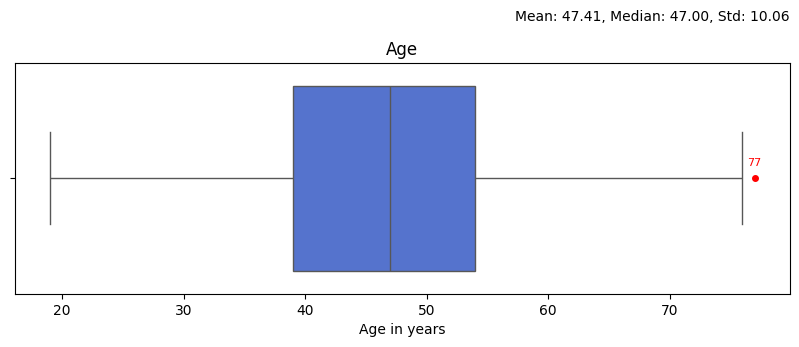

In [15]:
fig, ax = plt.subplots(figsize=(10, 3))
make_box_and_whiskers(ax, df["Age"], "Age", "Age in years", True)
plt.show()


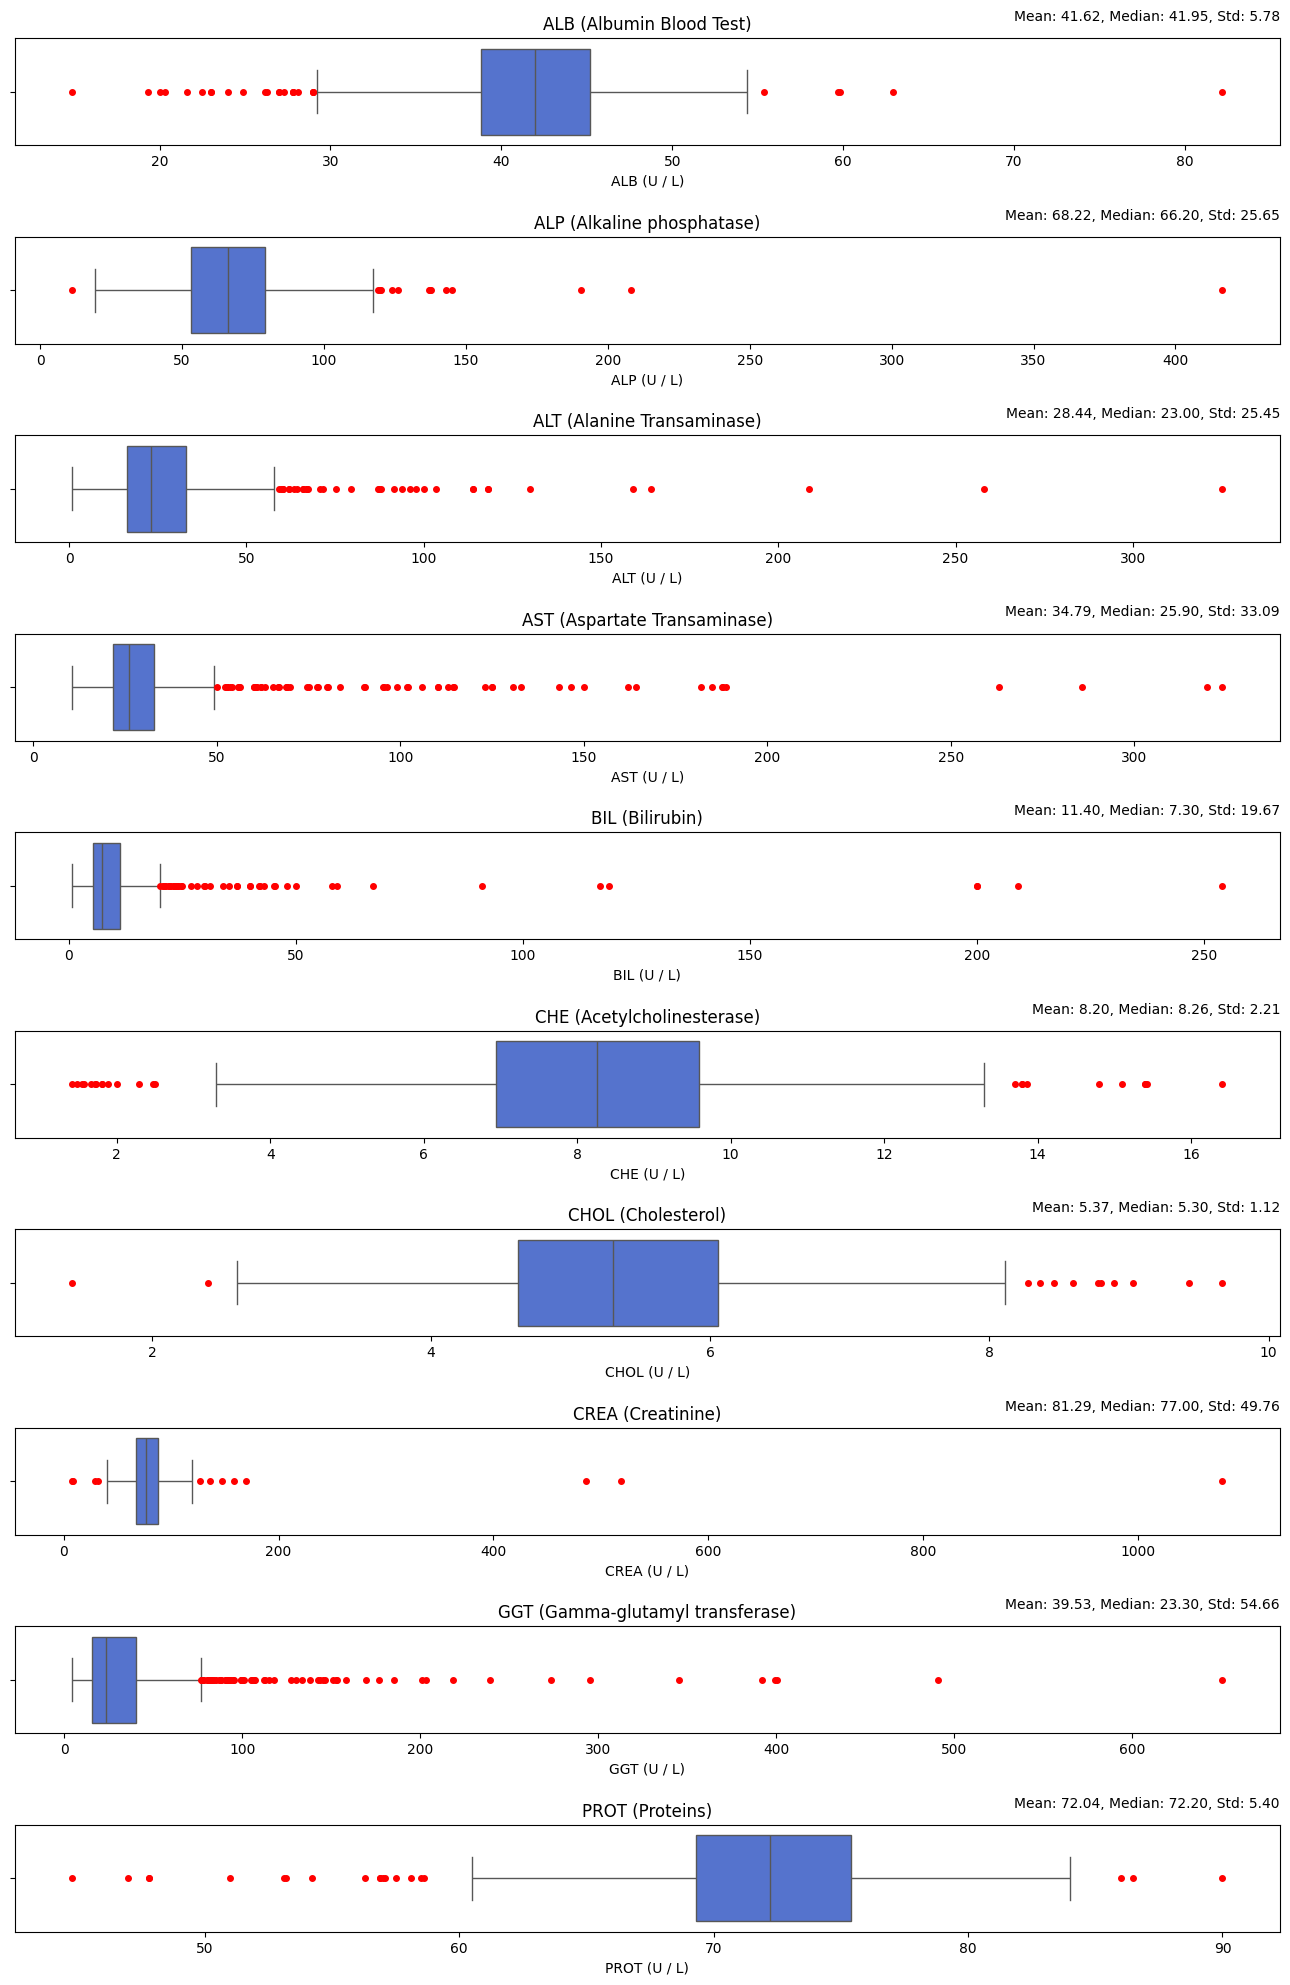

In [16]:
# Laboratory box-and-whisker plots using shared styling
lab_features = ["ALB", "ALP", "ALT", "AST", "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"]
lab_details = [
    "Albumin Blood Test",
    "Alkaline phosphatase",
    "Alanine Transaminase",
    "Aspartate Transaminase",
    "Bilirubin",
    "Acetylcholinesterase",
    "Cholesterol",
    "Creatinine",
    "Gamma-glutamyl transferase",
    "Proteins",
]

fig, axes = plt.subplots(len(lab_features), 1, figsize=(13, 2*len(lab_features)))

for i, (col, detail) in enumerate(zip(lab_features, lab_details)):
    make_box_and_whiskers(axes[i], df[col], f"{col} ({detail})", col + " (U / L)", False)

plt.tight_layout()
plt.show()


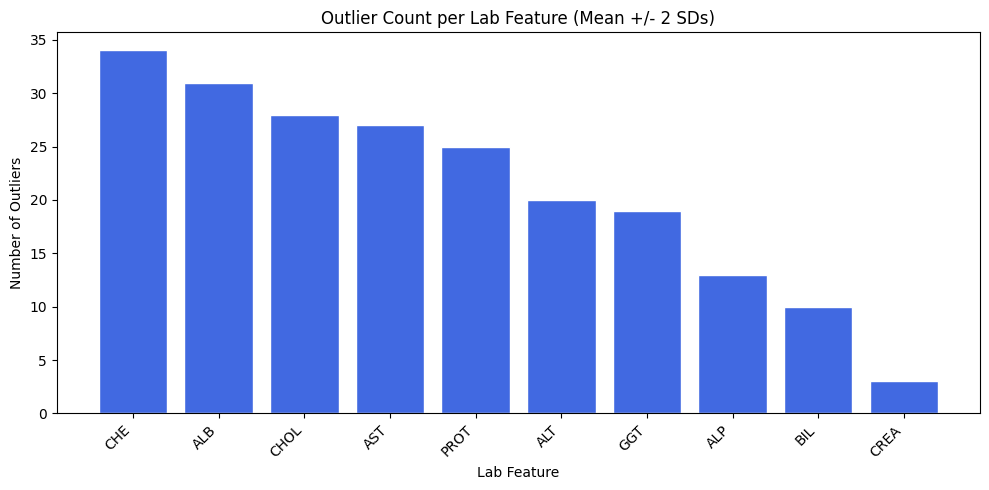

In [17]:
# Count outliers per lab column (mean +/- 2 SDs)
outliers_by_lab_col = {}
for col in lab_features:
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - 2 * std
    upper = mean + 2 * std
    outliers_by_lab_col[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]

outliers_df = (
    pd.DataFrame(outliers_by_lab_col.items(), columns=['Lab Feature', 'Outlier Count'])
    .sort_values('Outlier Count', ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(
    outliers_df['Lab Feature'],
    outliers_df['Outlier Count'],
    color="royalblue",
    edgecolor="white",
)
plt.xlabel('Lab Feature')
plt.ylabel('Number of Outliers')
plt.title('Outlier Count per Lab Feature (Mean +/- 2 SDs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Correlation matrix

We would like to determine what variables are correlated to guide our hypothesis testing and future analysis

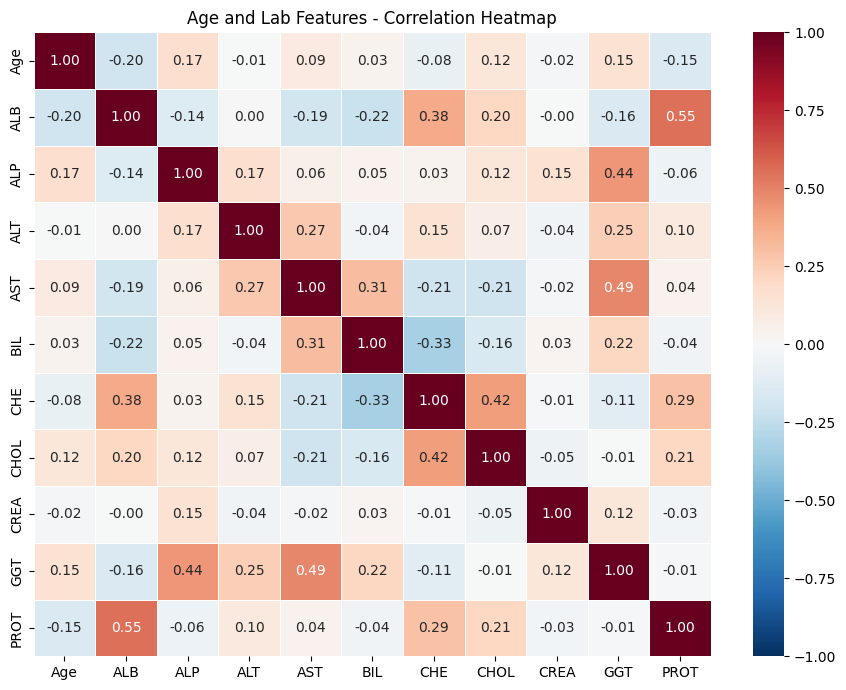

In [18]:
# Correlation matrix for age + all laboratory features
cols = ["Age"] + lab_features
corr_matrix = df[cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
)
plt.title('Age and Lab Features - Correlation Heatmap')
plt.tight_layout()
plt.show()

Correlation heat map notes
- The 2 most strongly positive correlated variables are:
    - ALB and PROT (0.55)
    - GGT and AST (0.49)
- The 2 most strongly negatively correlated variables are:
    - BIL and CHE (-0.33)
    - BIL and ALB (-0.22)
- Of note: CREA and age have weak to no correlation with other variables
    - CREA is creatinine, a metabolite commonly used to test kidney function, not liver function
    - Age is likely not a good predictor of liver disease, since it is not related to the laboratory features

### 4.2 Hypothesis Testing

Now, we will perform hypothesis tests: Chi-square, Binomial, ANOVA and Kruskal-Wallis, and Post-hoc Tukey HSD to determine statistically significant relationships and/or differences between variables.


**References:**
- [scipy.stats: chi2_contingency](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html)
- [scipy.stats: binomtest](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html)
- [scipy.stats: f_oneway (ANOVA)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html)
- [scipy.stats: kruskal](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html)
- [scipy.stats: tukey_hsd](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html)

In [19]:
# Next, we will set up hypothesis testing for a series of tests to come

category_labels = {0: "Blood Donor", 1: "Hepatitis", 2: "Fibrosis", 3: "Cirrhosis"}
sex_labels = {0: "Female", 1: "Male"}

df_test = df.copy()
df_test["CategoryName"] = df_test["Category"].map(category_labels)
df_test["SexName"] = df_test["Sex"].map(sex_labels)

lab_cols = lab_features[:]
feature_cols = ["Age"] + lab_cols
categories = sorted(df_test["Category"].dropna().unique())


### Chi-square test

- We performed a Chi-square test to determine if there is a statistically significant association between sex and category (of liver disease status)

  - Null Hypothesis (H0): Sex and category are independent: the distribution of categories does not differ between females and males.
  - Alternative Hypothesis (H1): Sex and category are not independent: the distribution of categories differs between females and males.
  - alpha = 0.05

In [20]:
# First, perform a Chi-square test
sex_cat_ct = pd.crosstab(df_test["SexName"], df_test["CategoryName"])
chi2, p_chi2, dof, expected = chi2_contingency(sex_cat_ct)

print(sex_cat_ct)
print(f"Chi2={chi2:.4f}, p={p_chi2:.4g}, dof={dof}")


CategoryName  Blood Donor  Cirrhosis  Fibrosis  Hepatitis
SexName                                                  
Female                216         10         8          4
Male                  324         20        13         20
Chi2=5.6635, p=0.1292, dof=3


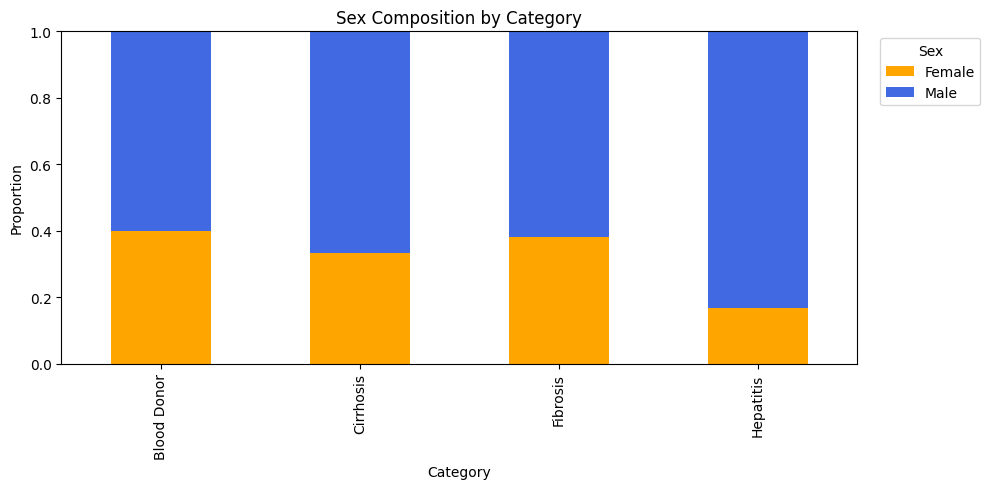

In [21]:
# 100% stacked bar: sex composition within each disease category
sex_cat_prop = sex_cat_ct.div(sex_cat_ct.sum(axis=0), axis=1).T

ax = sex_cat_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["orange", "royalblue"],
)
ax.set_title("Sex Composition by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
ax.legend(title="Sex", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Result of Chi-square test

- As p = 0.1292 > 0.05, we fail to reject H0
- There is insufficient evidence to conclude that sex and disease category are not independent

### Binomial test

- Next, we performed a binomial test in order to determine, for each category, whether the proportion of males in that category significantly differs from the overall proportion in the entire dataset (0.613)
  - Null Hypothesis (H0): The proportion of males in a given disease category equals the overall male rate in the dataset (p = 0.613).
  - Alternative Hypothesis (H1): The proportion of males in a given disease category differs from the overall male rate (p != 0.613).
  - alpha = 0.05
- Visualization was done using a stacked bar chart to show overall male/female composition in each category, including the entire dataset

In [22]:
# Perform binomial test

total_male_rate = (df_test["Sex"] == 1).sum() / len(df_test)
results = []
for c in categories:
    sub = df_test[df_test["Category"] == c]
    n = len(sub)
    num_males = (sub["Sex"] == 1).sum()
    num_females = (sub["Sex"] == 0).sum()

    p_binom = binomtest(num_males, n, p=total_male_rate, alternative="two-sided").pvalue
    results.append({
        "Category": category_labels[c],
        "N": n,
        "Male": num_males,
        "Female": num_females,
        "Male_rate": num_males / n,
        "Female_rate": num_females / n,
        "Total_male_rate": total_male_rate,
        "p_binom": p_binom
    })
results_df = pd.DataFrame(results)
display(results_df)


,Category,N,Male,Female,Male_rate,Female_rate,Total_male_rate,p_binom
0,Blood Donor,540,324,216,0.600000,0.400000,0.613008,0.536517
1,Hepatitis,24,20,4,0.833333,0.166667,0.613008,0.034018
2,Fibrosis,21,13,8,0.619048,0.380952,0.613008,1.000000
3,Cirrhosis,30,20,10,0.666667,0.333333,0.613008,0.580853


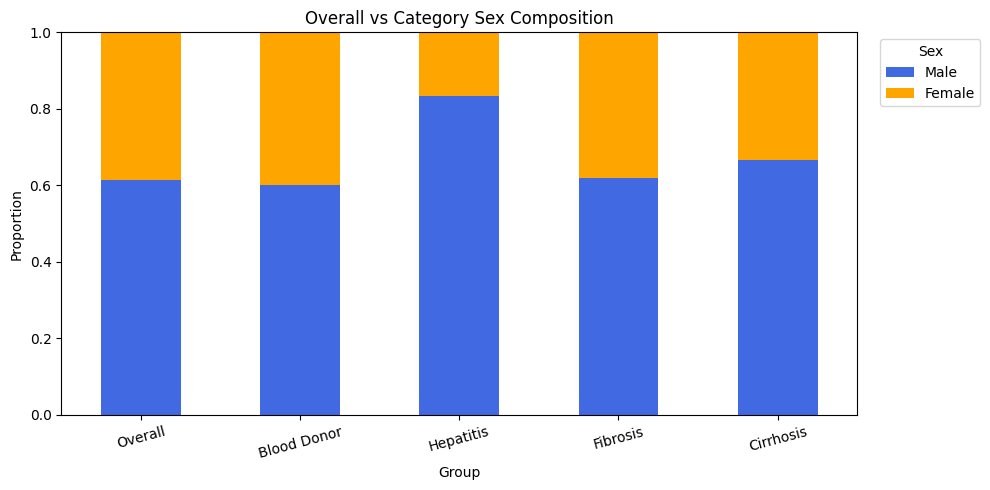

In [23]:
# Stacked bar: overall male/female composition vs each disease category
overall_comp = pd.DataFrame({
    "Group": ["Overall"],
    "Male": [total_male_rate],
    "Female": [1 - total_male_rate],
})
category_comp = results_df[["Category", "Male_rate", "Female_rate"]].rename(
    columns={"Category": "Group", "Male_rate": "Male", "Female_rate": "Female"}
)
comp_df = pd.concat([overall_comp, category_comp], ignore_index=True).set_index("Group")

ax = comp_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["royalblue", "orange"],
)
ax.set_title("Overall vs Category Sex Composition")
ax.set_xlabel("Group")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
ax.legend(title="Sex", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

#### Result of Binomial Test

- At the 0.05 significance level, Hepatitis is the only category where we can reject the null hypothesis
  - Males are significantly overrepresented in the Hepatitis group compared to the overall proportion of males in the dataset
- We fail to reject the null hypothesis in all other categories

### ANOVA and Kruskal-Wallis Tests
- For each numeric laboratory feature, we performed the ANOVA and Kruskal-Wallis tests to determine if that laboratory feature significantly differs across the 4 disease categories
- ANOVA:
  - Null hypothesis (H0): The mean value of the feature is equal across all categories.
  - Alternative hypothesis (H1): At least one category has a different mean value for the feature
- Kruskal-Wallis
  - Null hypothesis (H0): The distribution of the feature is the same across all categories (no difference in central tendency).
  - Alternative hypothesis (H1): At least one category has a different distribution for the feature.
- alpha = 0.05 for both ANOVA and Kruskal-Wallis
- The distribution of each laboratory feature divided by category was visualized using box plots

In [24]:
# Perform ANOVA and Kruskal-Wallis Tests
result_rows = []
for feat in feature_cols:
    groups = [df_test.loc[df_test["Category"] == cat, feat].dropna().values for cat in categories]
    if all(len(g) > 1 for g in groups):
        f_stat, p_anova = f_oneway(*groups) # decamp the 2d list into separate arguments
        h_stat, p_kruskal = kruskal(*groups)

        result_rows.append({
            "Feature": feat,
            "ANOVA_F": f_stat,
            "ANOVA_p": p_anova,
            "Kruskal_H": h_stat,
            "Kruskal_p": p_kruskal
        })
result_df = pd.DataFrame(result_rows)
display(result_df)


,Feature,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,Age,11.940157,1.318064e-07,29.098353,2.135352e-06
1,ALB,28.745777,2.134976e-17,55.998433,4.204172e-12
2,ALP,17.244577,9.254460e-11,46.196793,5.150542e-10
3,ALT,11.771256,1.663988e-07,22.066434,6.318748e-05
4,AST,141.436468,1.362926e-69,155.103774,2.087700e-33
5,BIL,91.165092,9.168611e-49,94.561523,2.293746e-20
6,CHE,53.699560,8.117300e-31,66.587764,2.294400e-14
7,CHOL,19.717587,3.273604e-12,51.589324,3.663758e-11
8,CREA,14.847303,2.427382e-09,9.487463,2.346511e-02
9,GGT,54.365113,3.705367e-31,103.102781,3.343824e-22


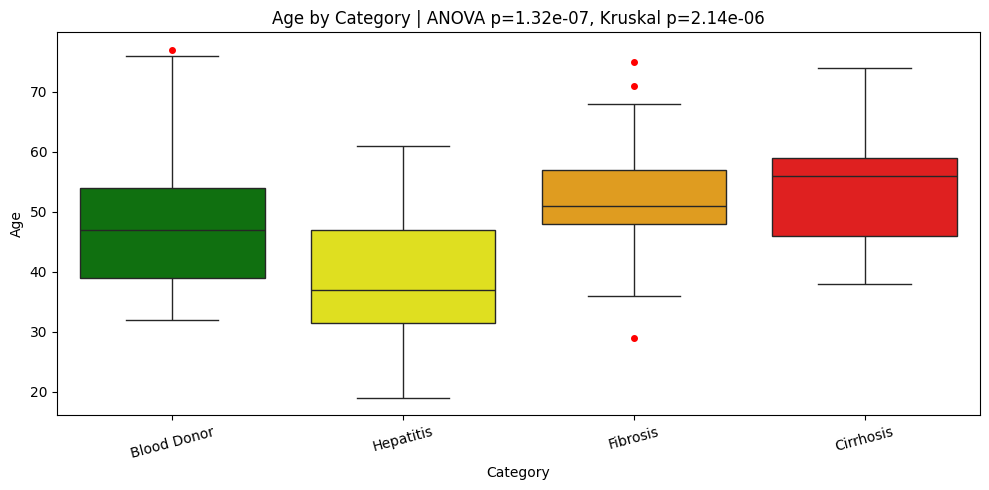

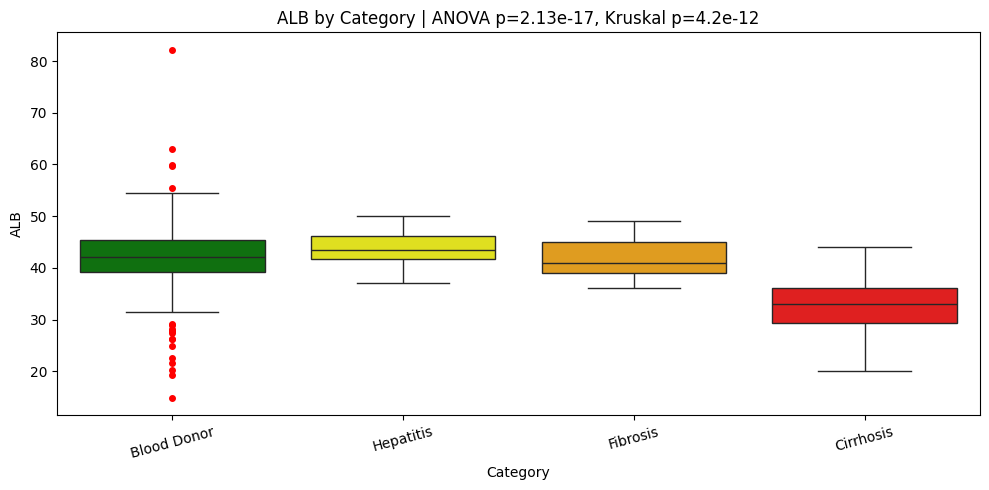

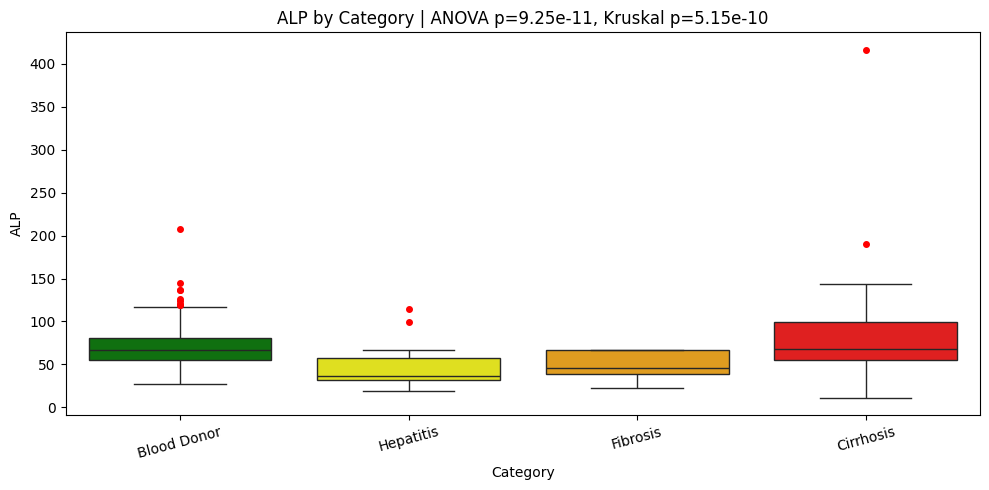

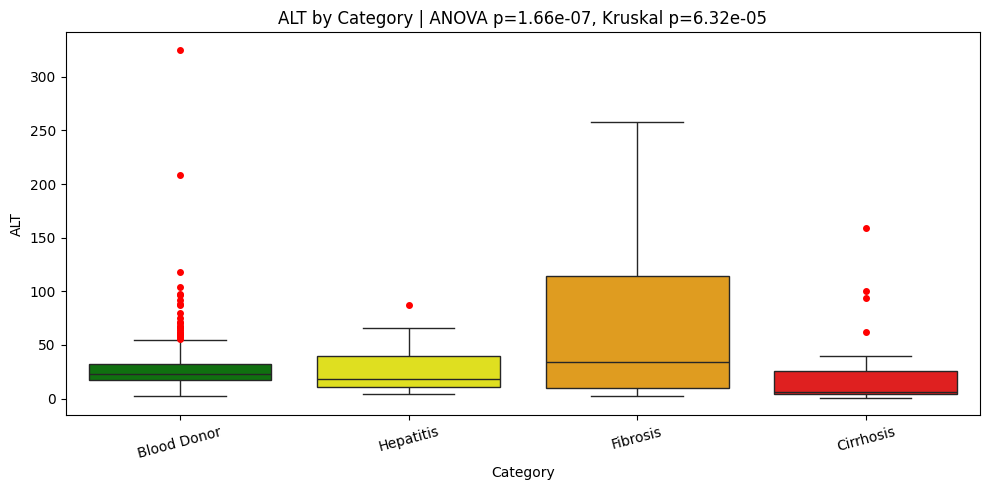

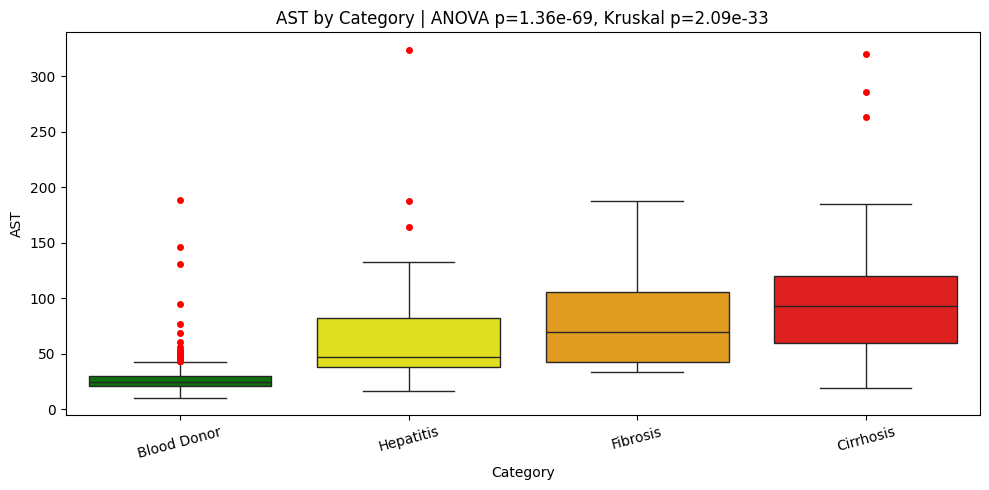

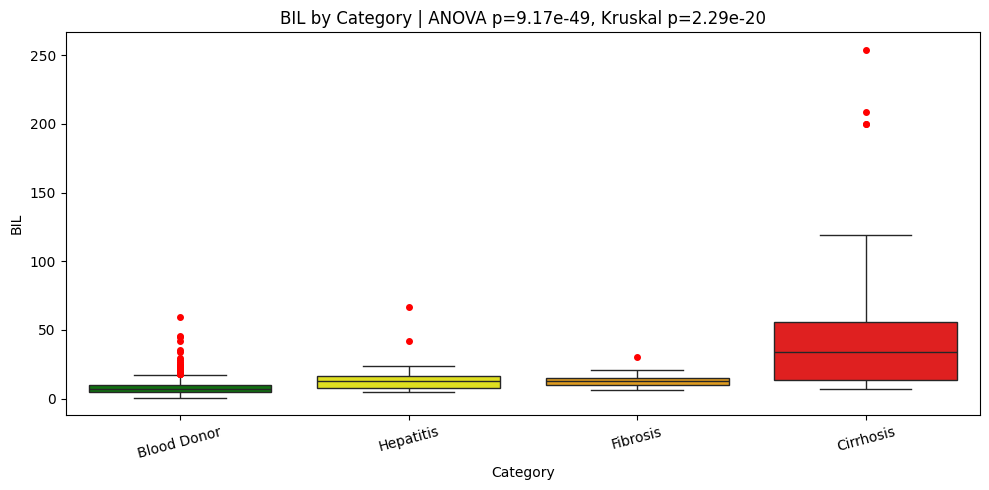

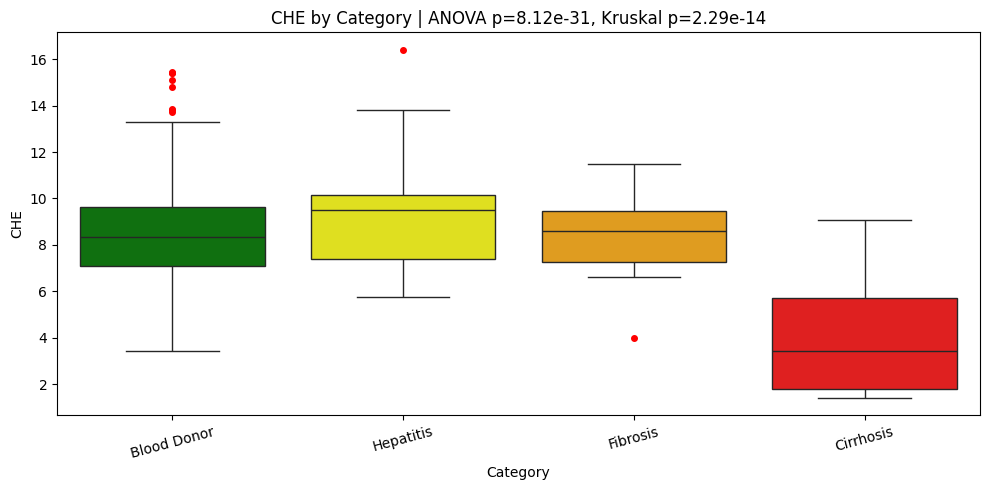

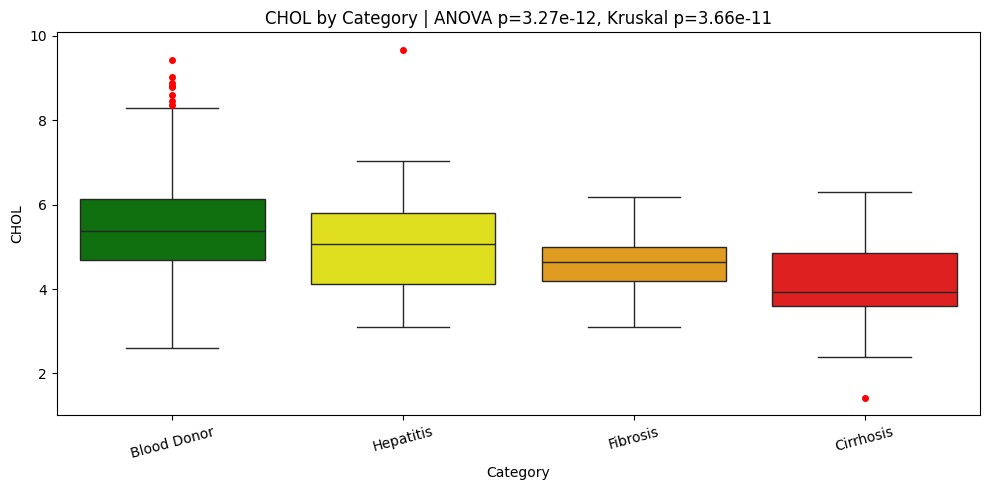

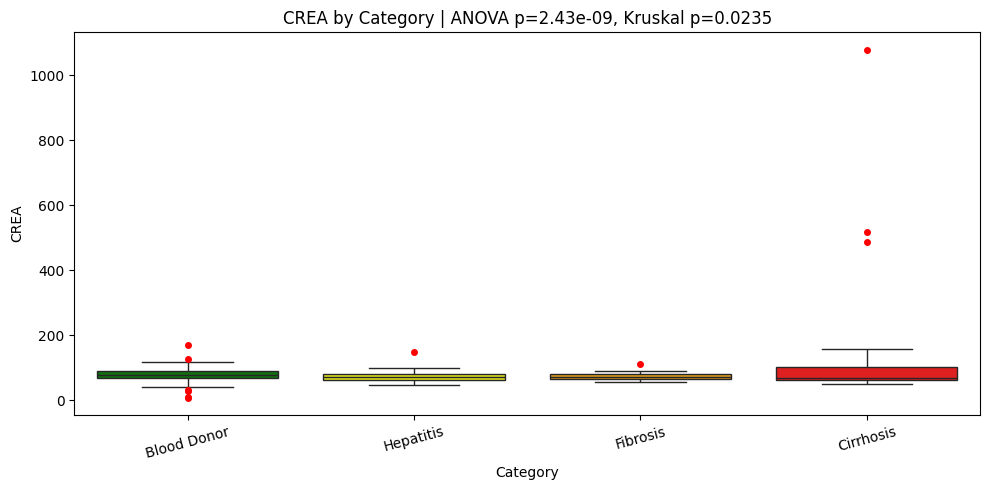

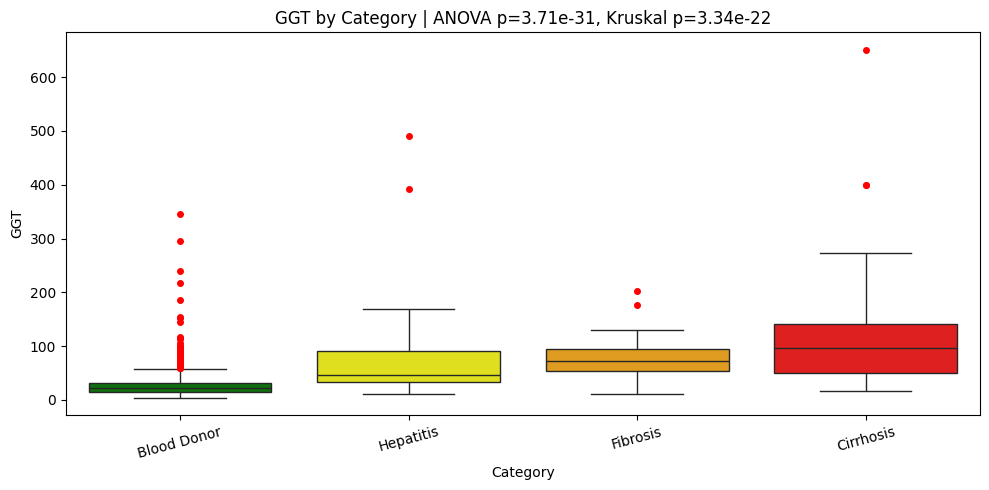

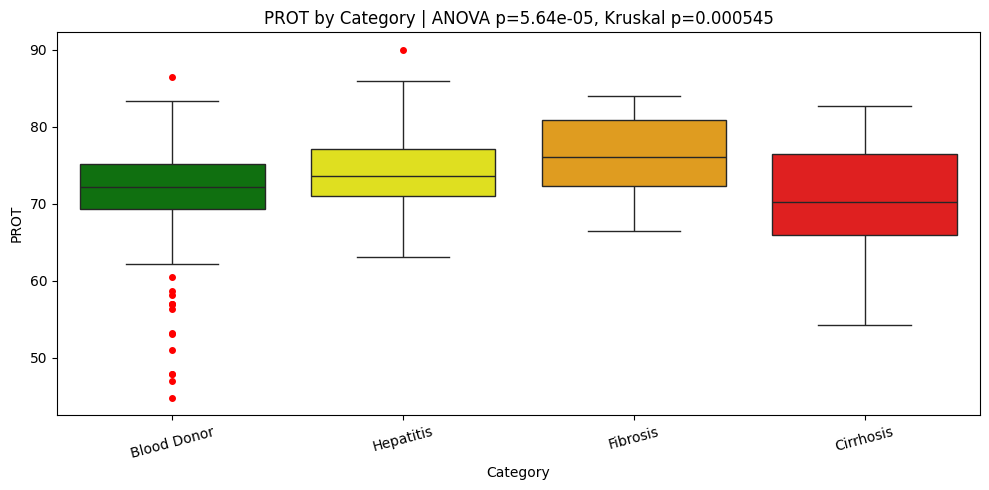

In [25]:
# Box plots per feature coloured by disease category
category_order = [category_labels[c] for c in categories]

# color palette for plots
CATEGORY_PALETTE = {
    "Blood Donor": "green",
    "Hepatitis": "yellow",
    "Fibrosis": "orange",
    "Cirrhosis": "red",
}

for feat in feature_cols:
    pvals = result_df.loc[result_df["Feature"] == feat, ["ANOVA_p", "Kruskal_p"]]
    if not pvals.empty:
        anova_p = pvals.iloc[0]["ANOVA_p"]
        kruskal_p = pvals.iloc[0]["Kruskal_p"]
        title = f"{feat} by Category | ANOVA p={anova_p:.3g}, Kruskal p={kruskal_p:.3g}"
    else:
        title = f"{feat} by Category"

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(
        data=df_test,
        x="CategoryName",
        y=feat,
        hue="CategoryName",
        order=category_order,
        hue_order=category_order,
        palette=CATEGORY_PALETTE,
        dodge=False,
        flierprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "red",
            "markersize": 4,
        },
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Category")
    ax.set_ylabel(feat)
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()

#### ANOVA and Kruskal-Wallis test results

- At a 0.05 significance level, there is a significant difference across categories for **all** laboratory features
  - At least one disease group differs from the others for each laboratory feature
- The strongest differences are in AST, BIL, GGT, and CHE, which each have very small p-values from both tests
  - This suggests that these are the most distinguishing lab feature between category

### Post-hoc Tukey HSD
- Given the results of the ANOVA and Kruskal-Wallis tests, we can perform a post-hoc Tukey HSD test to determine exactly which category differs for each laboratory feature
  - Null hypothesis (H0): The mean value of the feature is equal between the two groups being compared (Group 1 = Group 2).
  - Null hypothesis (H1): The mean value of the feature differs between the two groups being compared (Group 1 != Group 2).
  - alpha = 0.05
- For each significant Tukey comparison, we created a visualization with:
  - a histogram that overlays the distribution of laboratory feature in the differing categories
  - box and whisker plots of the laboratory features side by side

In [26]:
# Perform post hoc Tukey HSD tests

posthoc_rows = []
for feat in feature_cols:
    groups = []
    names = []
    for c in categories:
        vals = df_test.loc[df_test["Category"] == c, feat].dropna().values
        if len(vals) >= 2:
            groups.append(vals)
            names.append(category_labels[c])

    if len(groups) >= 2:
        res = tukey_hsd(*groups)
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                posthoc_rows.append({
                    "Feature": feat,
                    "Group1": names[i],
                    "Group2": names[j],
                    "Mean_diff": float(res.statistic[i, j]),
                    "p_tukey": float(res.pvalue[i, j])
                })

posthoc_df = pd.DataFrame(posthoc_rows)
display(posthoc_df.sort_values(["Feature", "p_tukey"]))

print("Significant post hoc differences (Tukey p < 0.05):")
display(posthoc_df[posthoc_df["p_tukey"] < 0.05].sort_values(["Feature", "p_tukey"]))


,Feature,Group1,Group2,Mean_diff,p_tukey
8,ALB,Blood Donor,Cirrhosis,9.208704,0.000000e+00
10,ALB,Hepatitis,Cirrhosis,11.035000,1.934897e-12
11,ALB,Fibrosis,Cirrhosis,8.963571,5.946091e-08
6,ALB,Blood Donor,Hepatitis,-1.826296,3.707664e-01
9,ALB,Hepatitis,Fibrosis,2.071429,5.766959e-01
...,...,...,...,...,...
61,PROT,Blood Donor,Fibrosis,-4.224630,2.138737e-03
64,PROT,Hepatitis,Cirrhosis,4.576667,9.410397e-03
60,PROT,Blood Donor,Hepatitis,-2.824630,5.379246e-02
62,PROT,Blood Donor,Cirrhosis,1.752037,2.949026e-01


Significant post hoc differences (Tukey p < 0.05):


,Feature,Group1,Group2,Mean_diff,p_tukey
8,ALB,Blood Donor,Cirrhosis,9.208704,0.000000e+00
10,ALB,Hepatitis,Cirrhosis,11.035000,1.934897e-12
11,ALB,Fibrosis,Cirrhosis,8.963571,5.946091e-08
16,ALP,Hepatitis,Cirrhosis,-42.691667,3.118669e-09
17,ALP,Fibrosis,Cirrhosis,-37.821429,6.186399e-07
12,ALP,Blood Donor,Hepatitis,23.744815,2.891485e-05
14,ALP,Blood Donor,Cirrhosis,-18.946852,2.828571e-04
13,ALP,Blood Donor,Fibrosis,18.874577,3.498362e-03
19,ALT,Blood Donor,Fibrosis,-31.990000,6.441512e-08
23,ALT,Fibrosis,Cirrhosis,36.630000,1.710272e-06


Significant comparisons to plot: 40


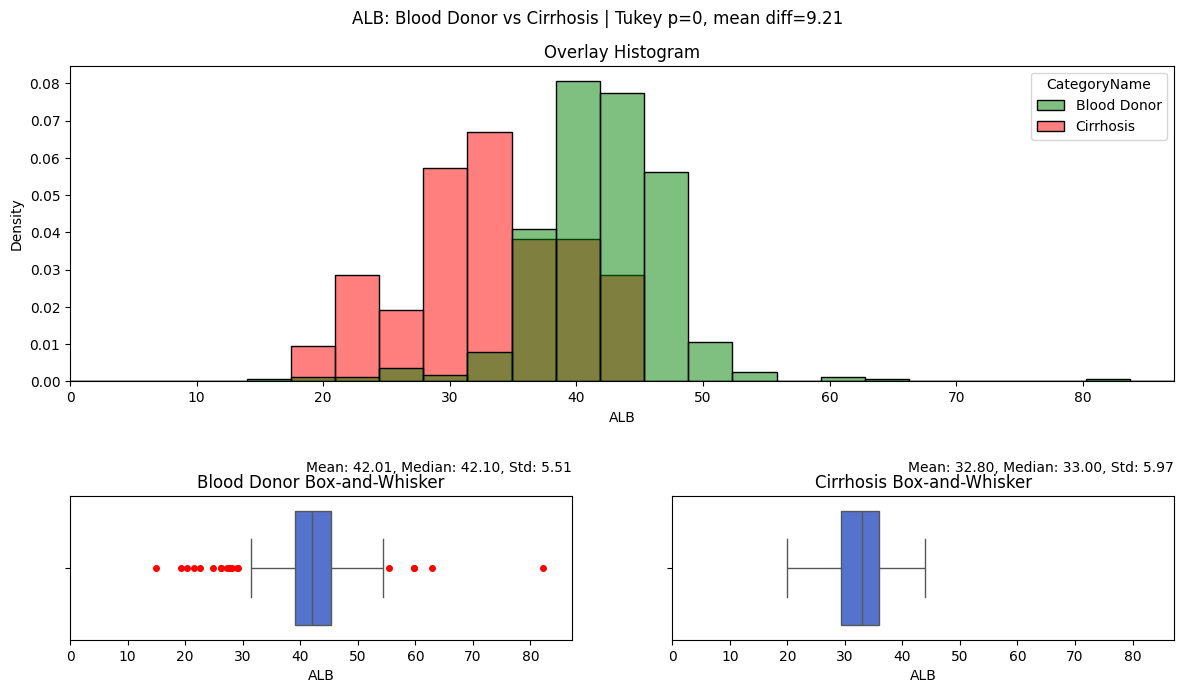

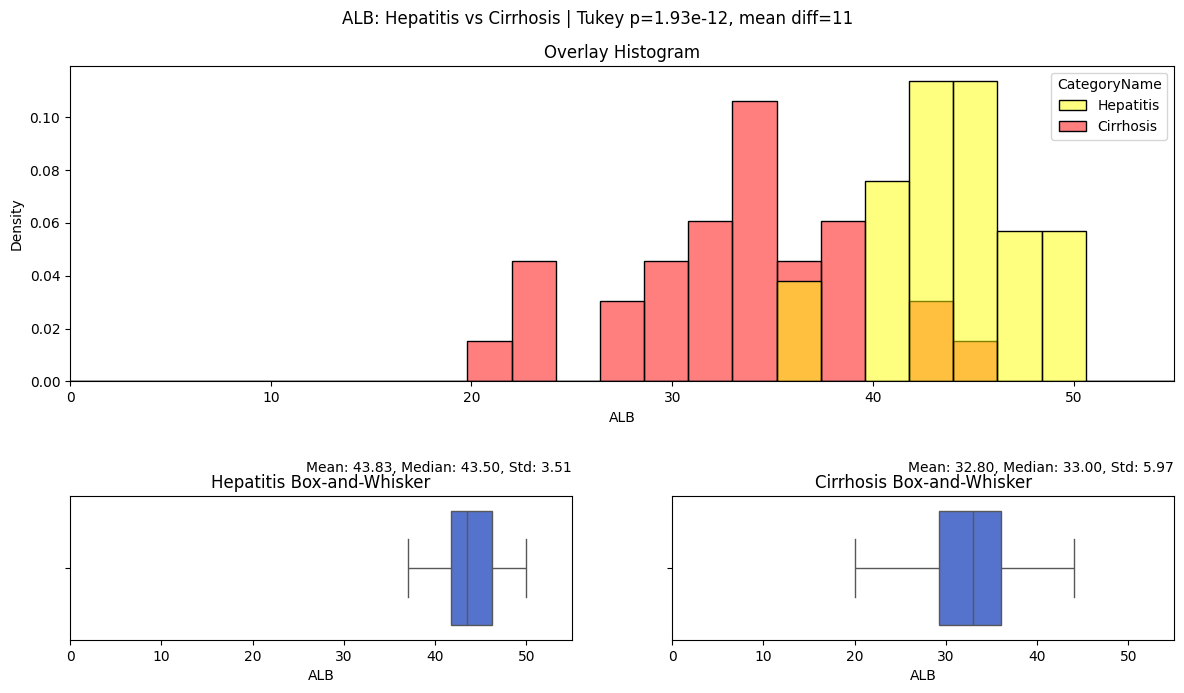

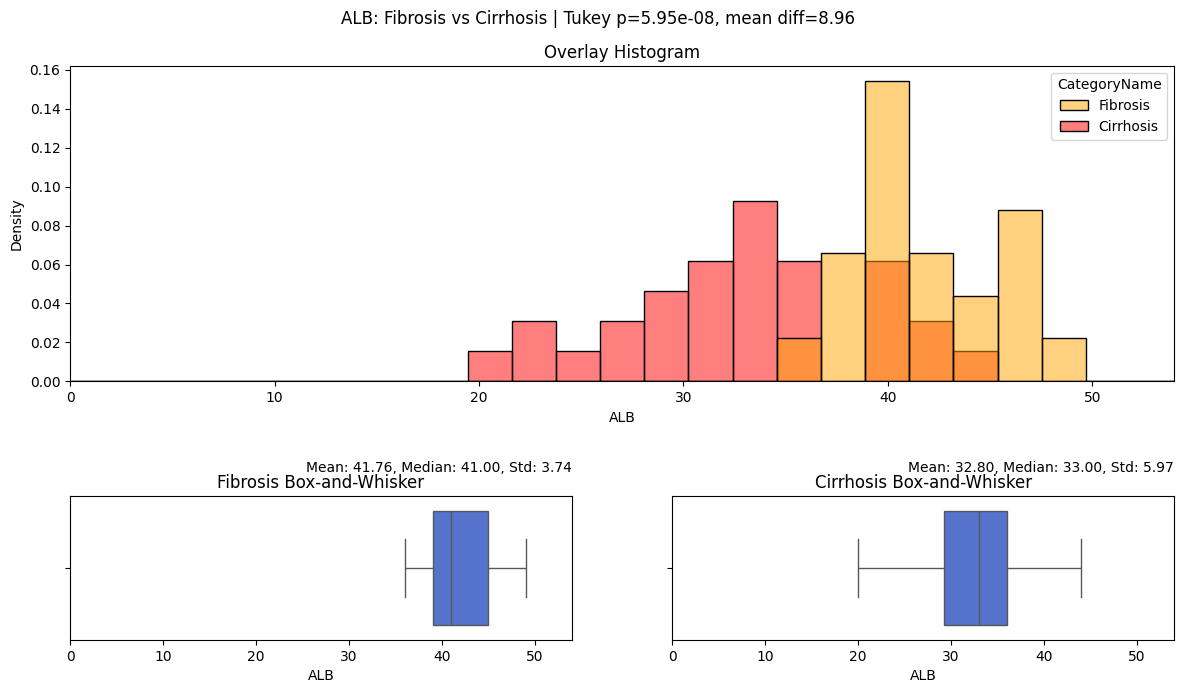

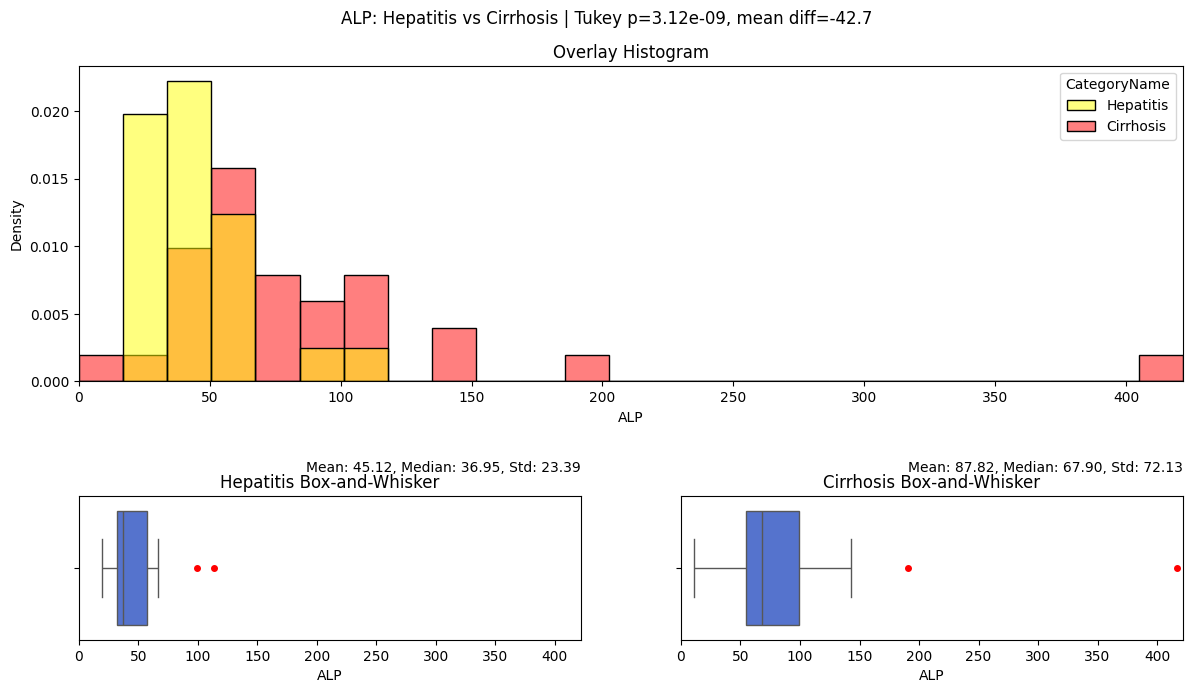

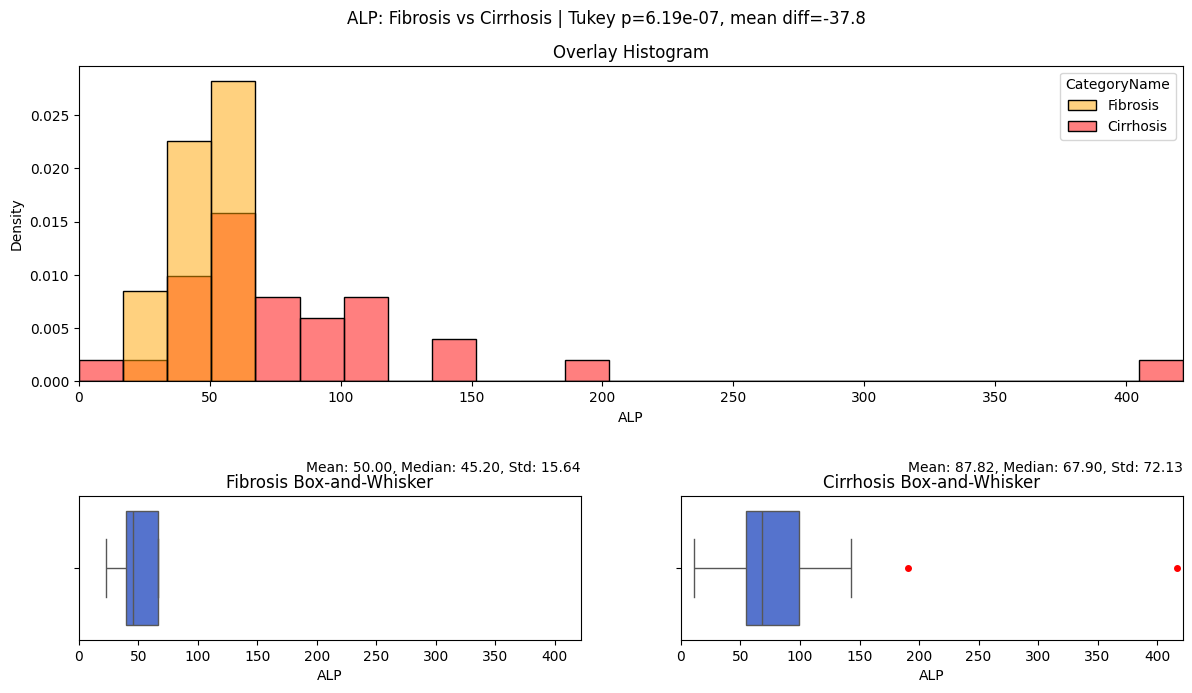

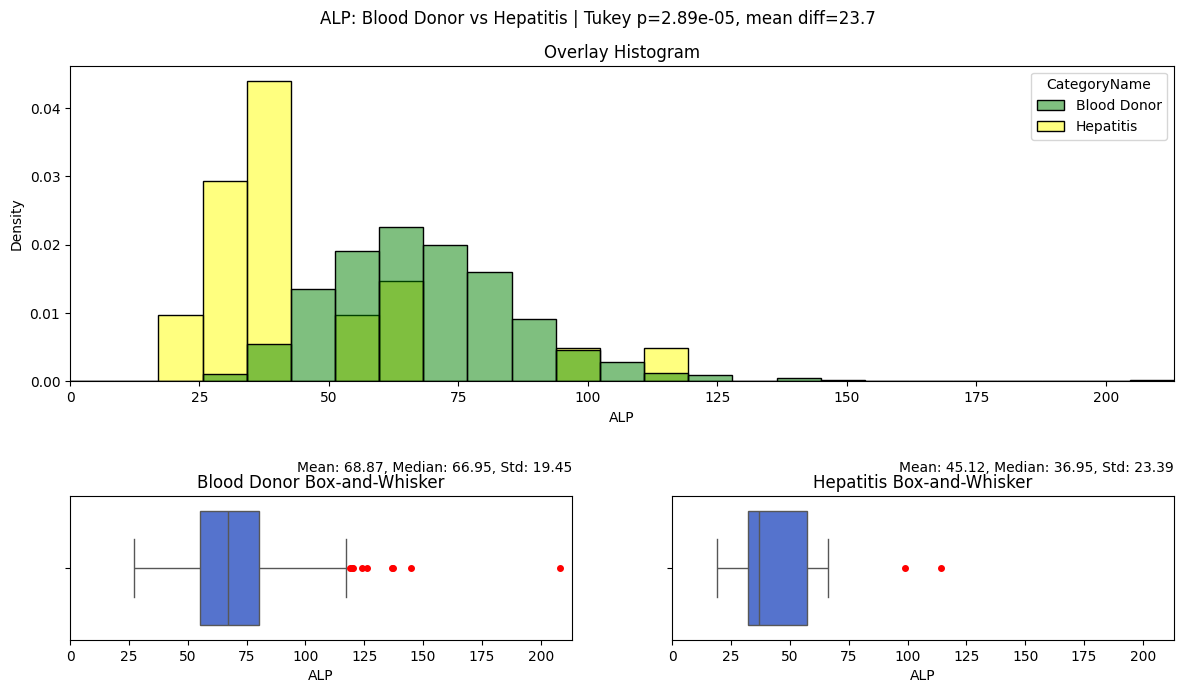

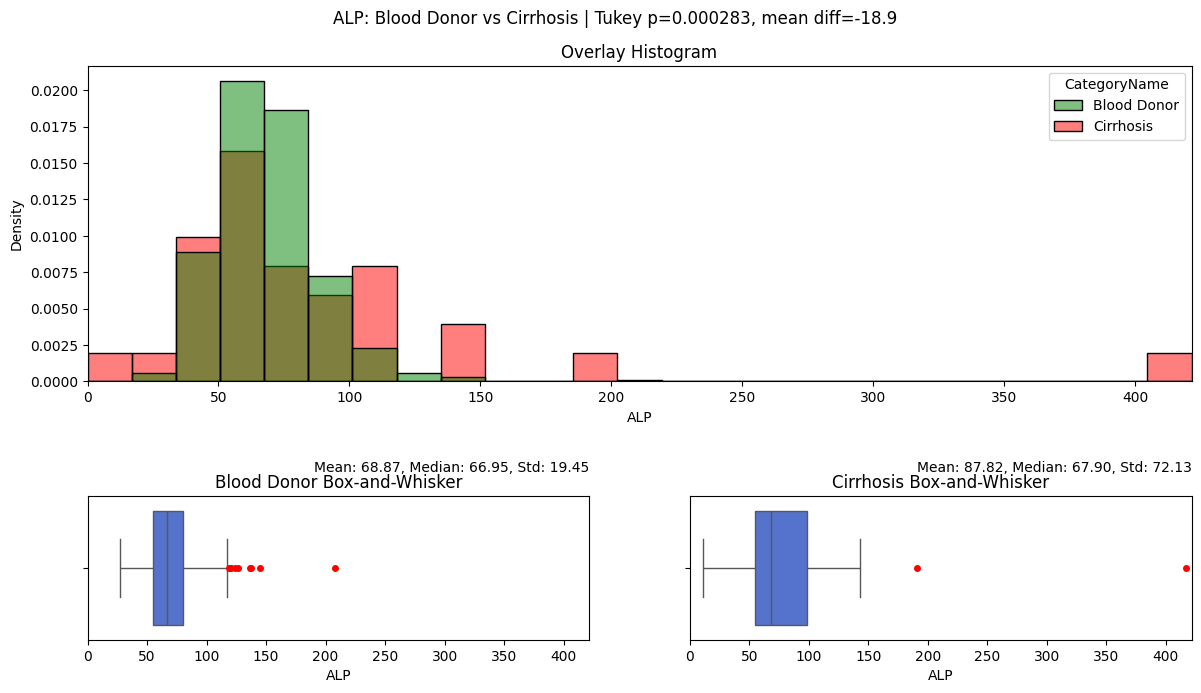

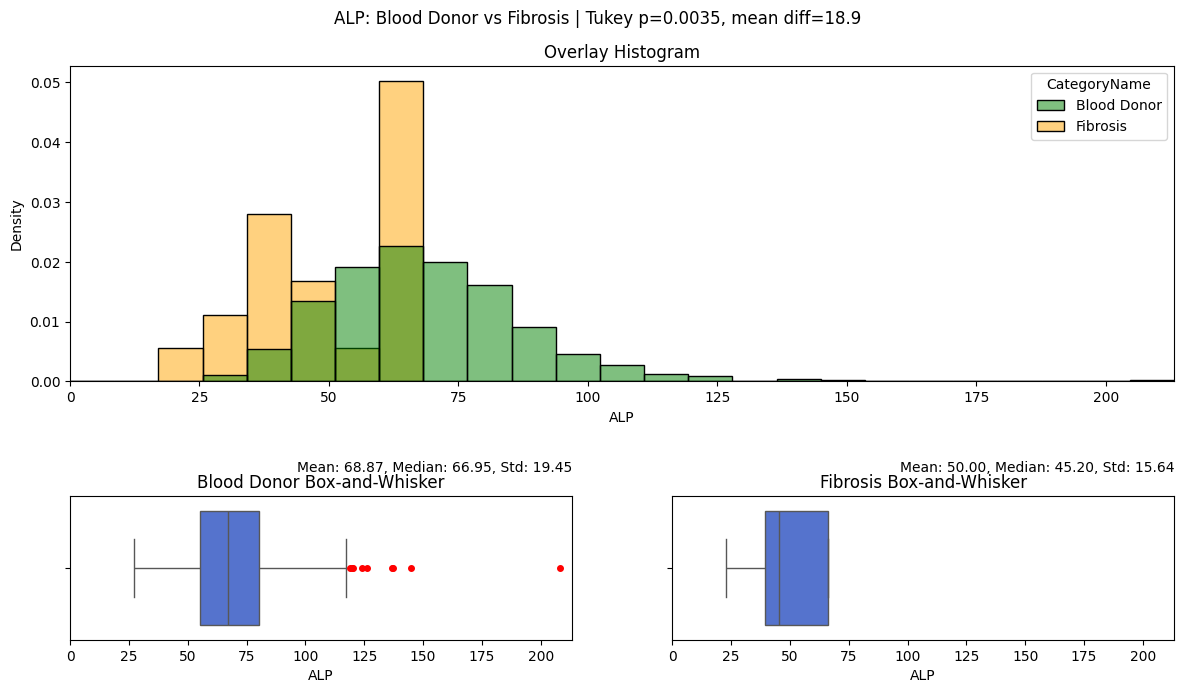

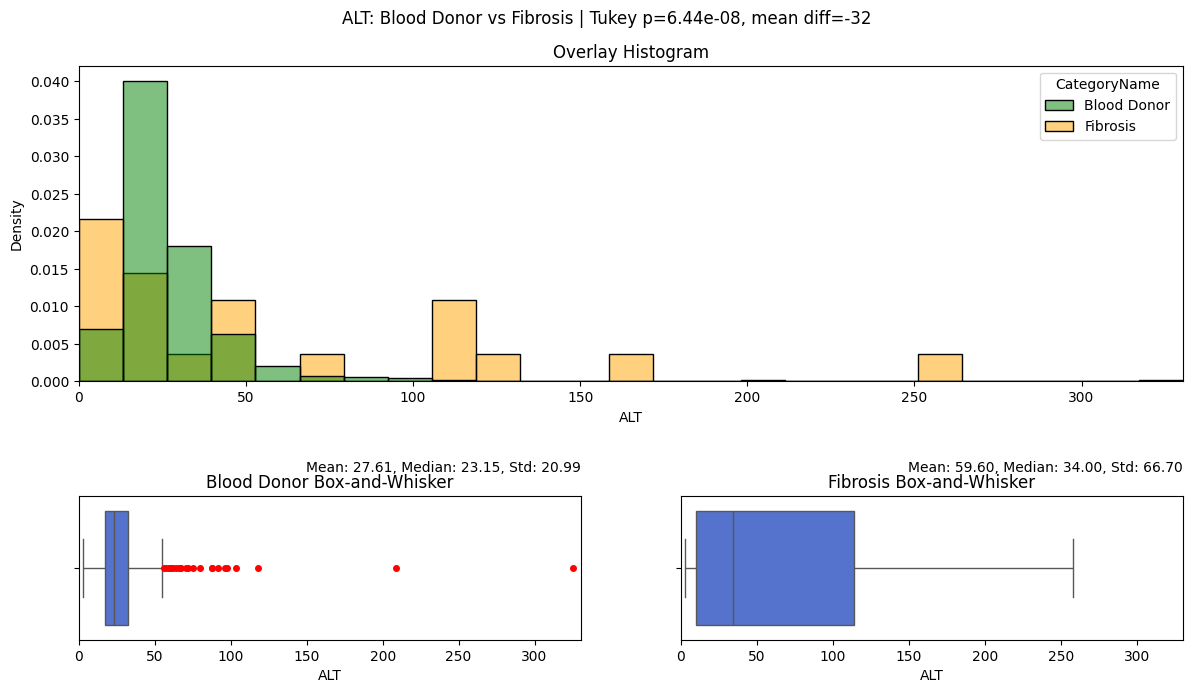

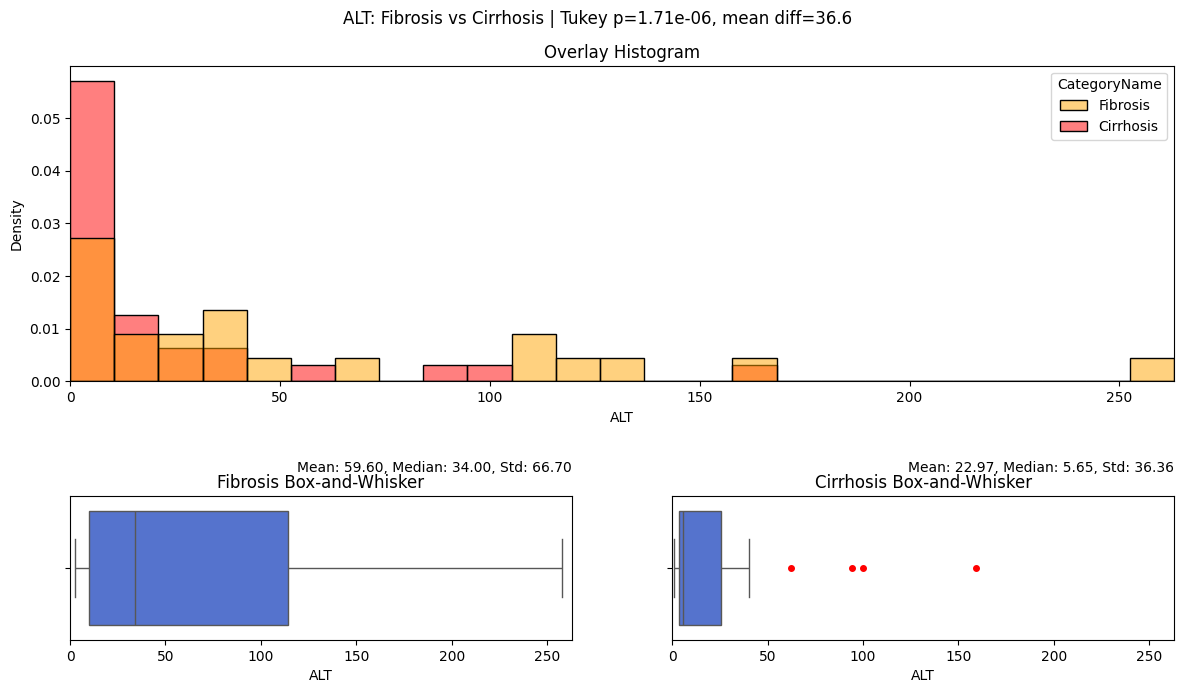

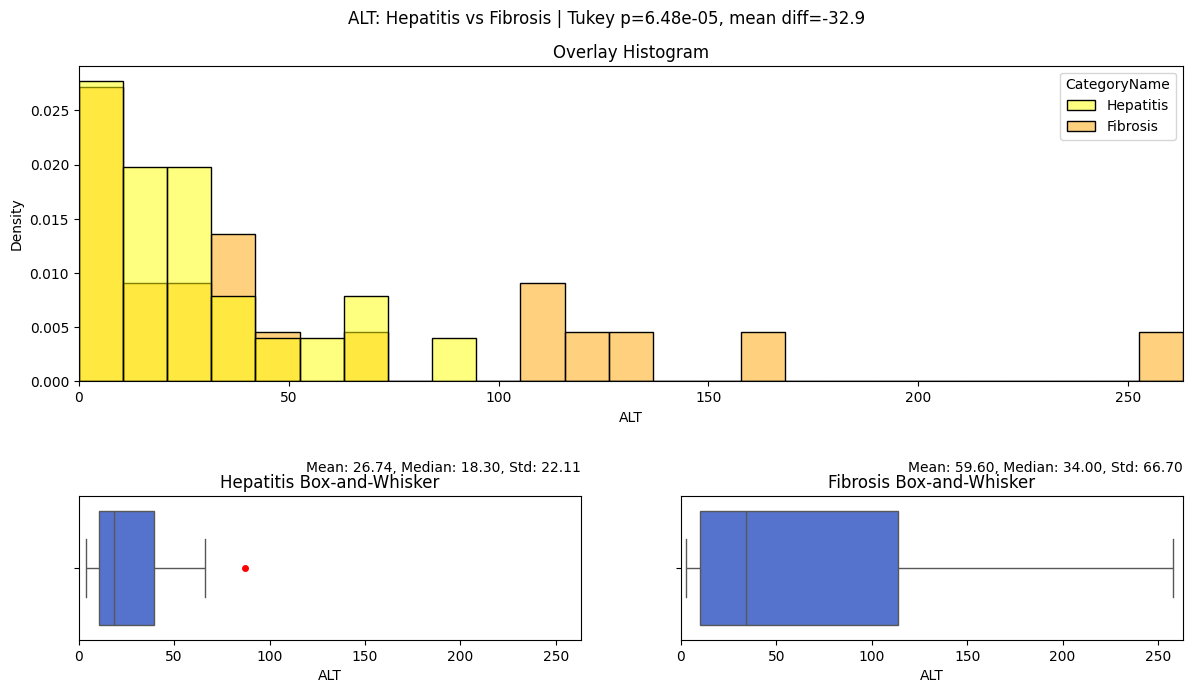

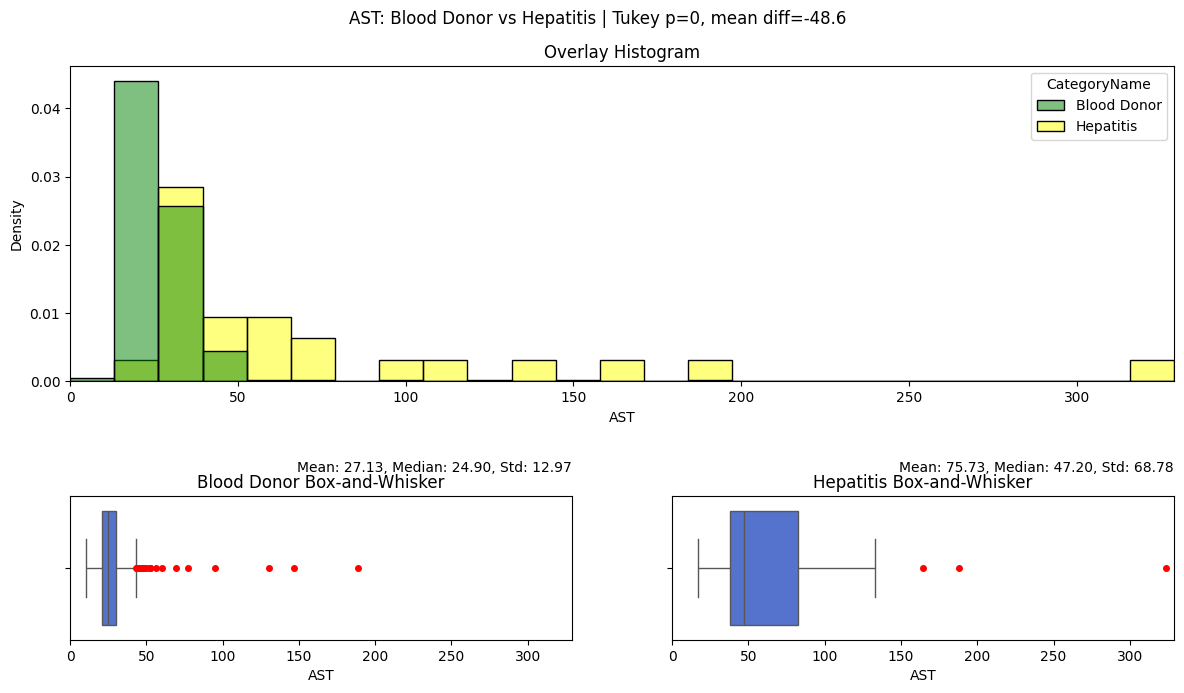

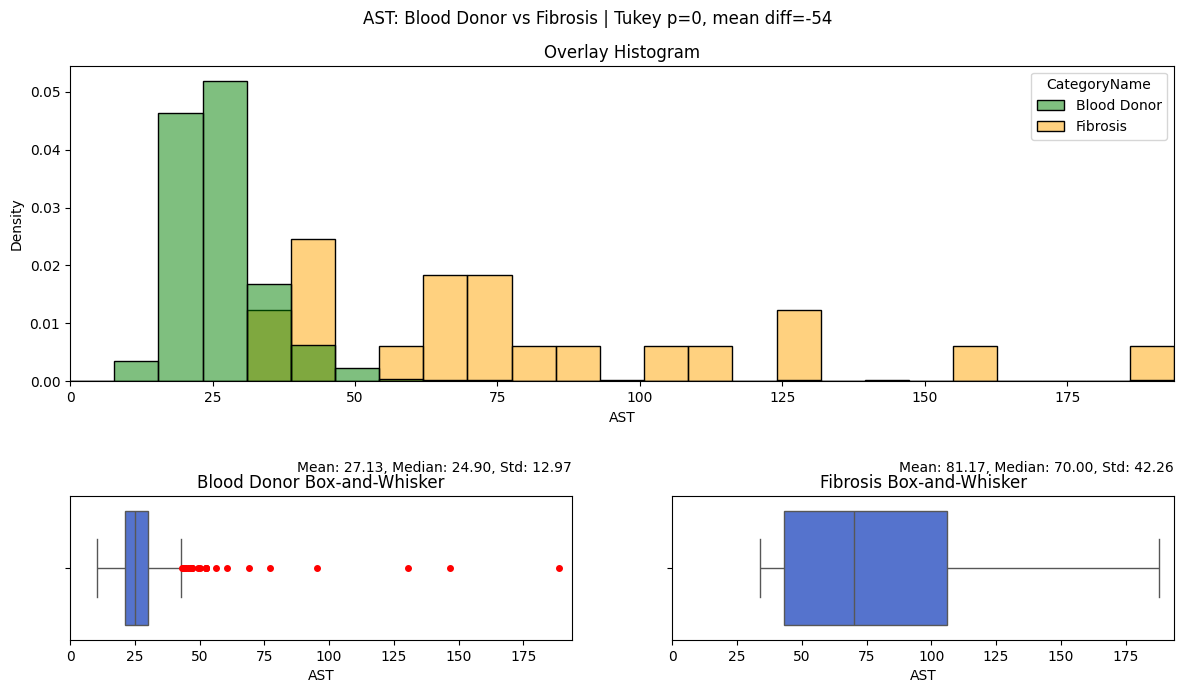

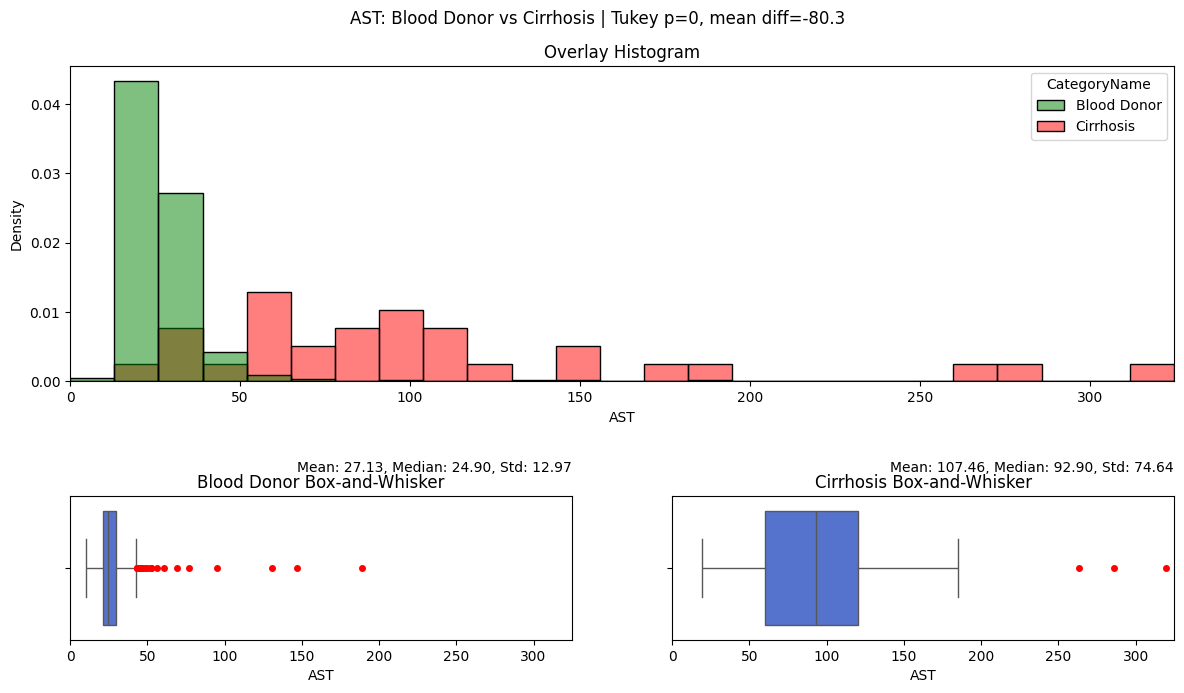

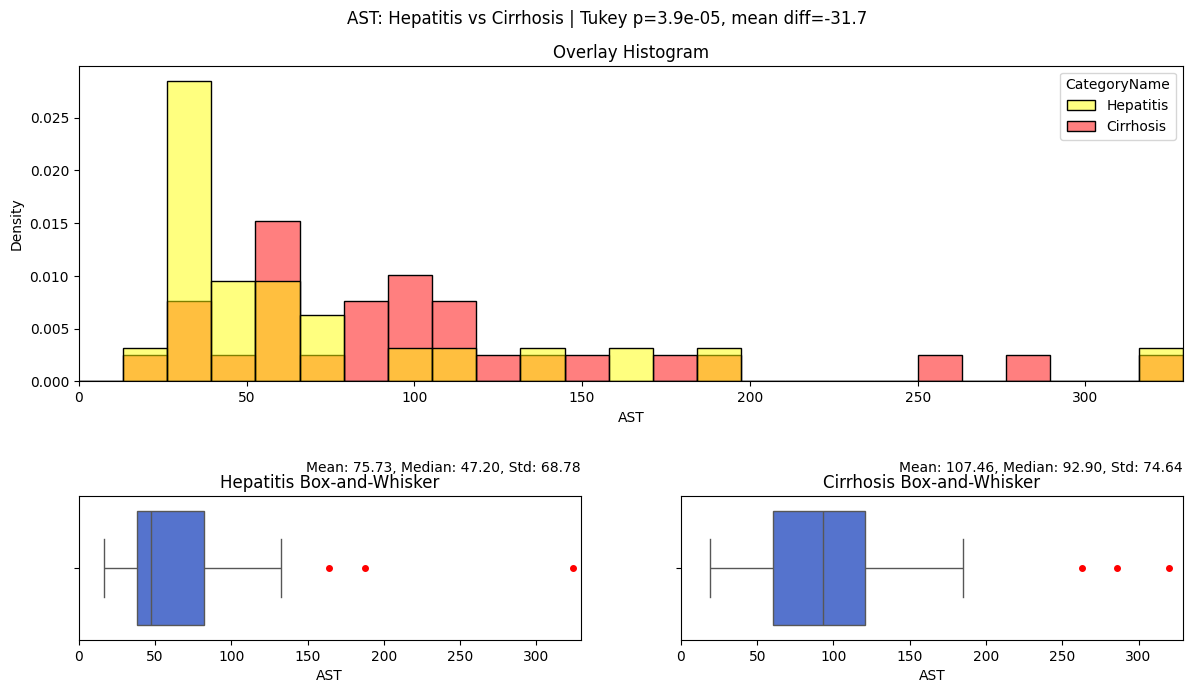

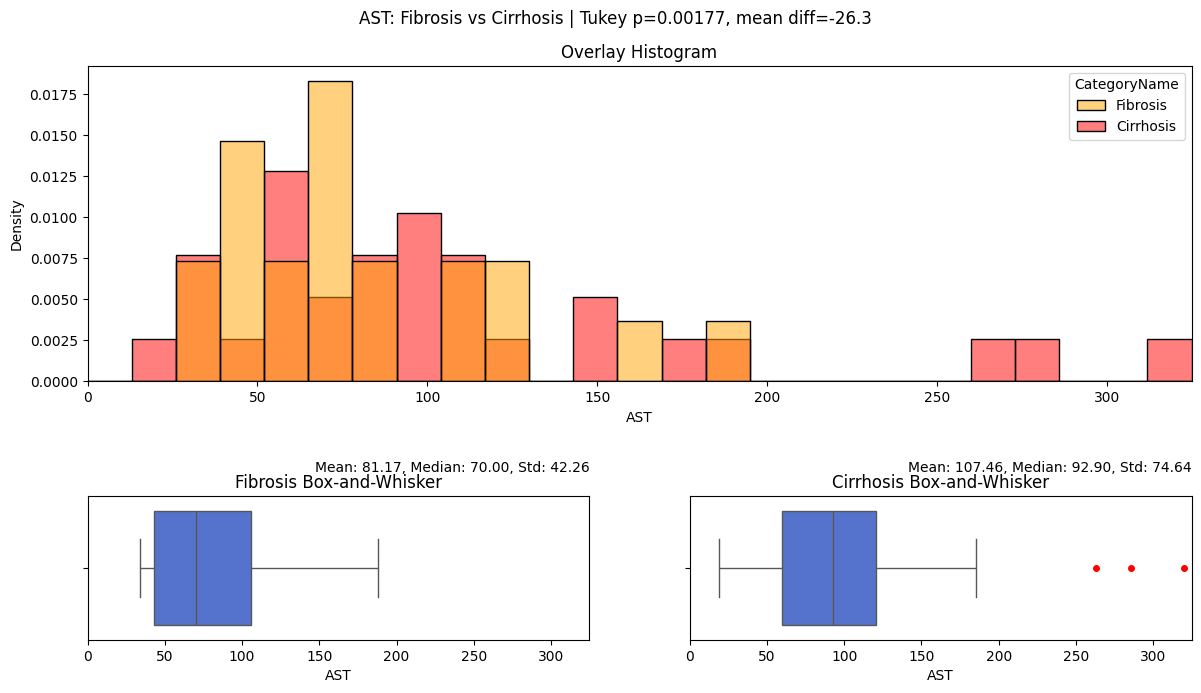

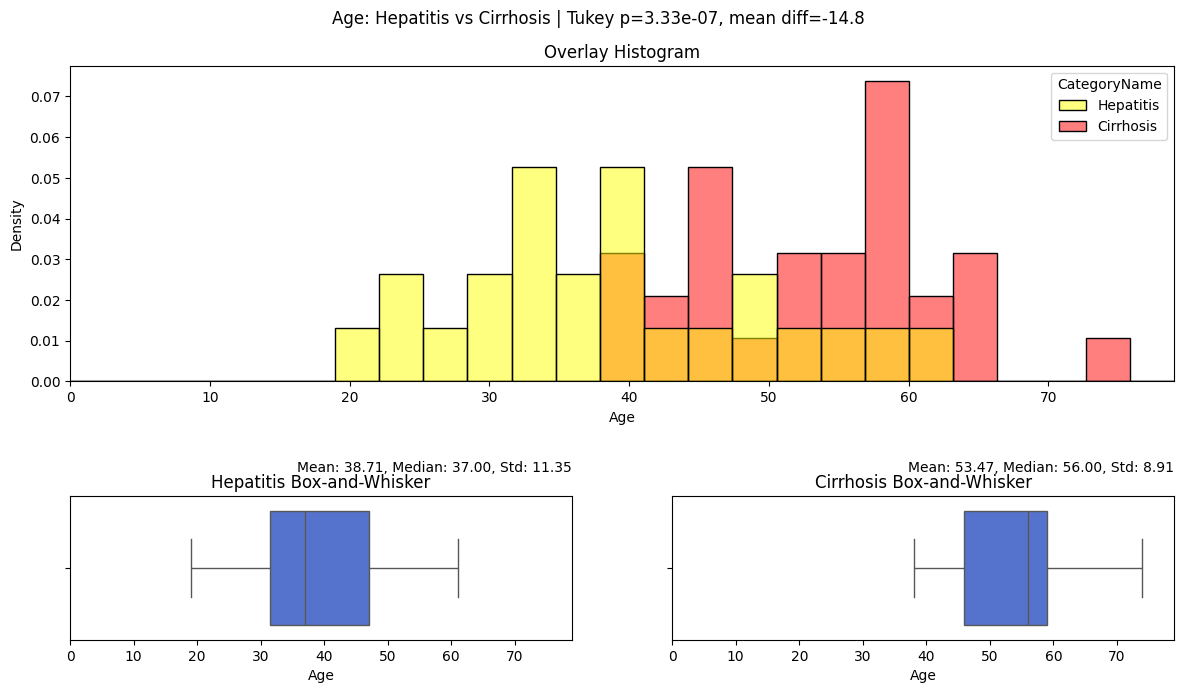

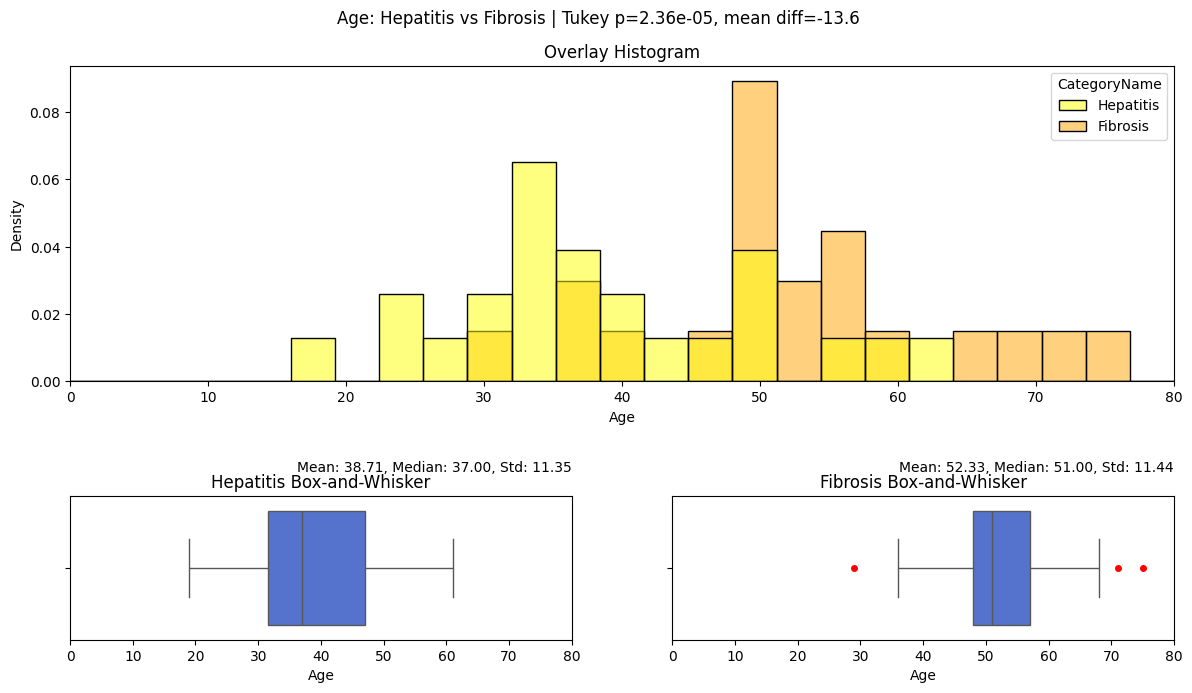

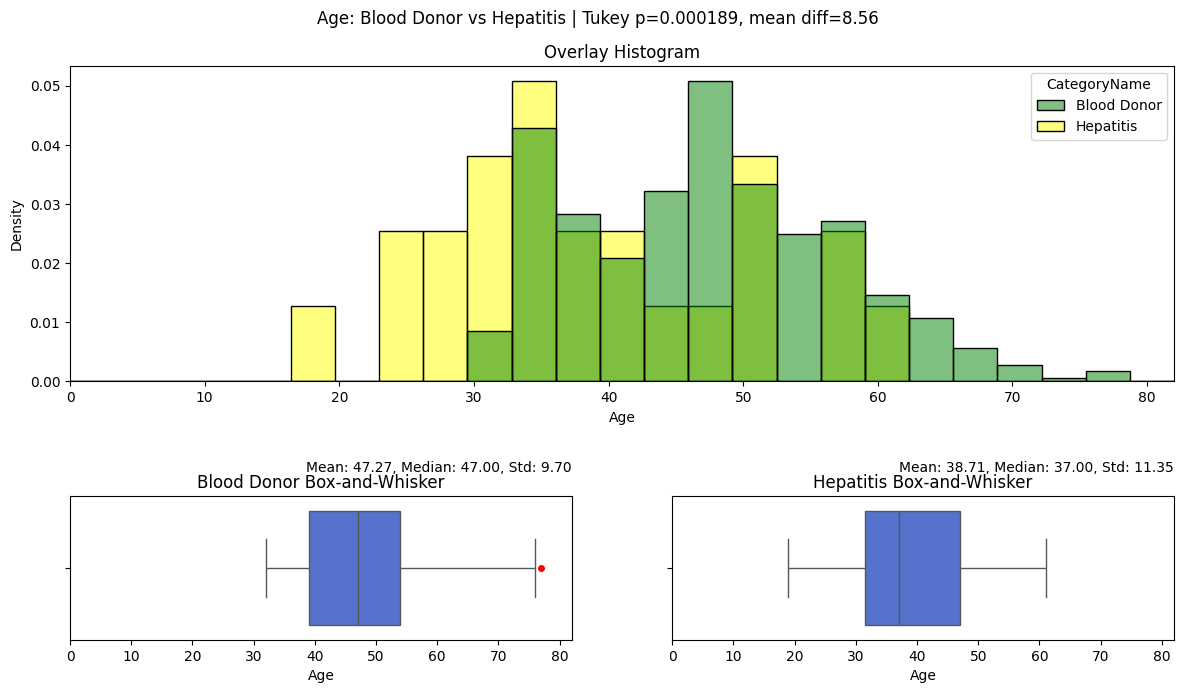

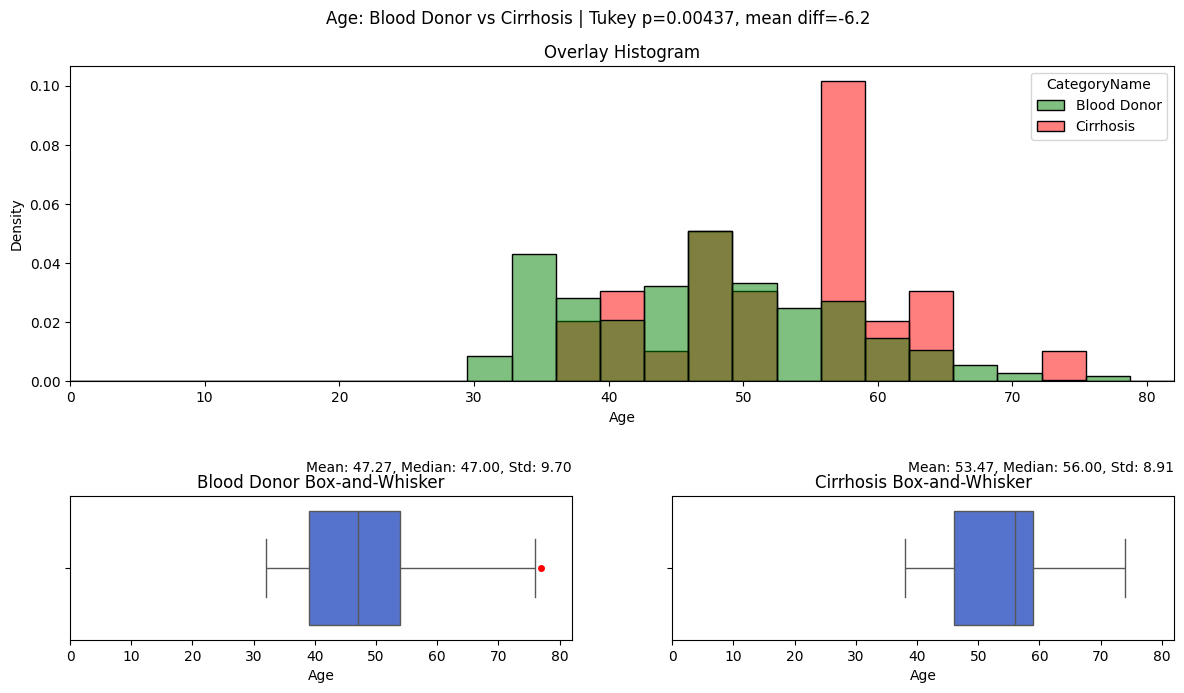

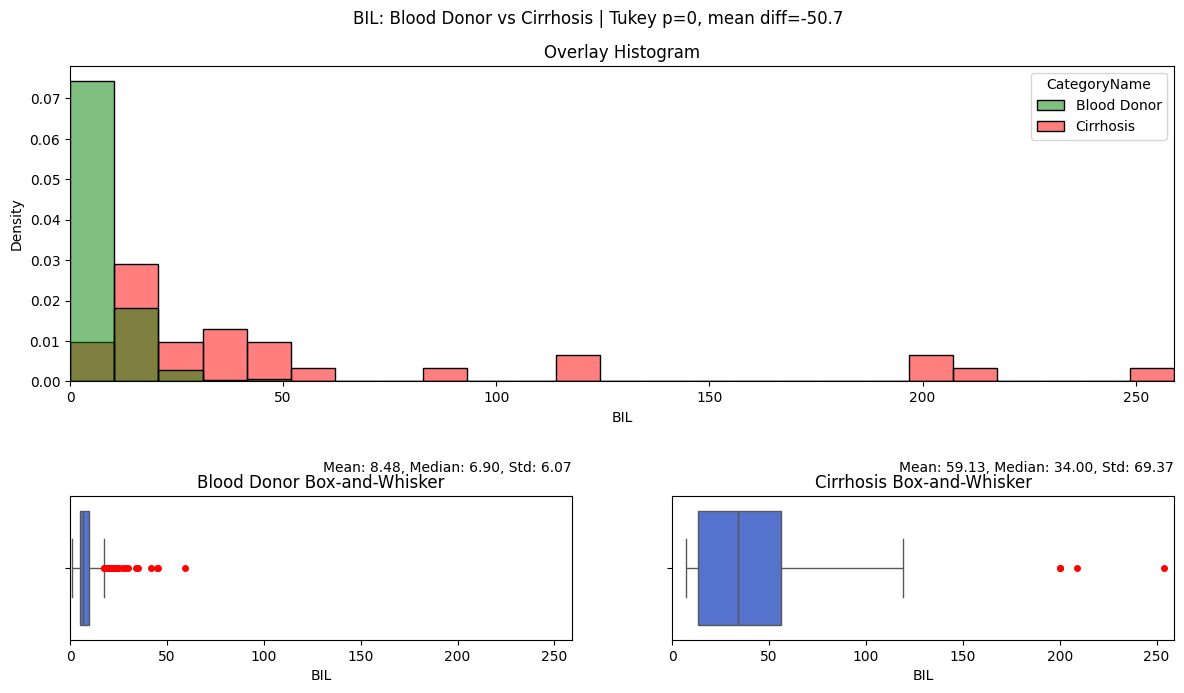

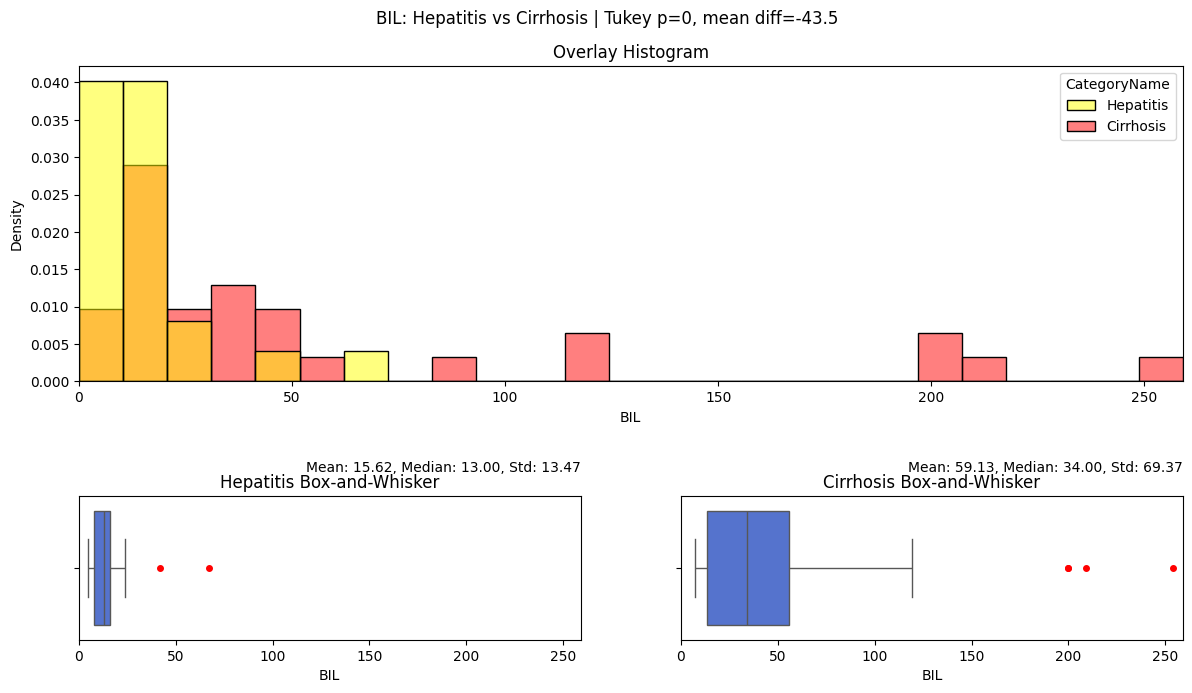

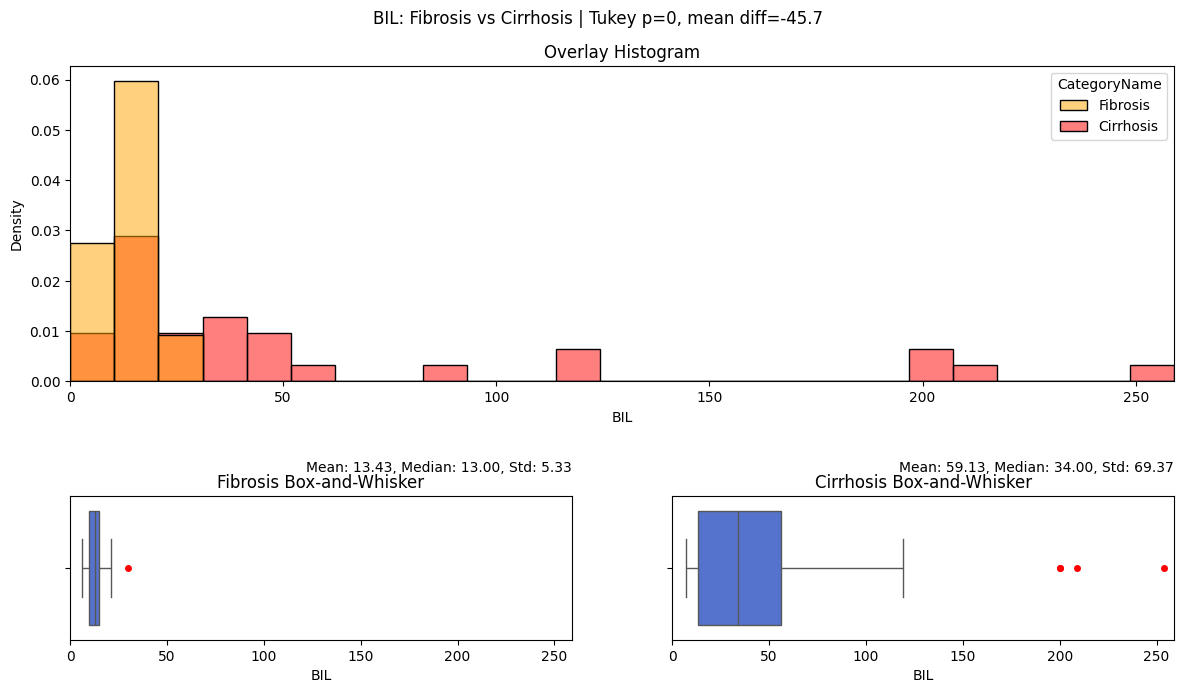

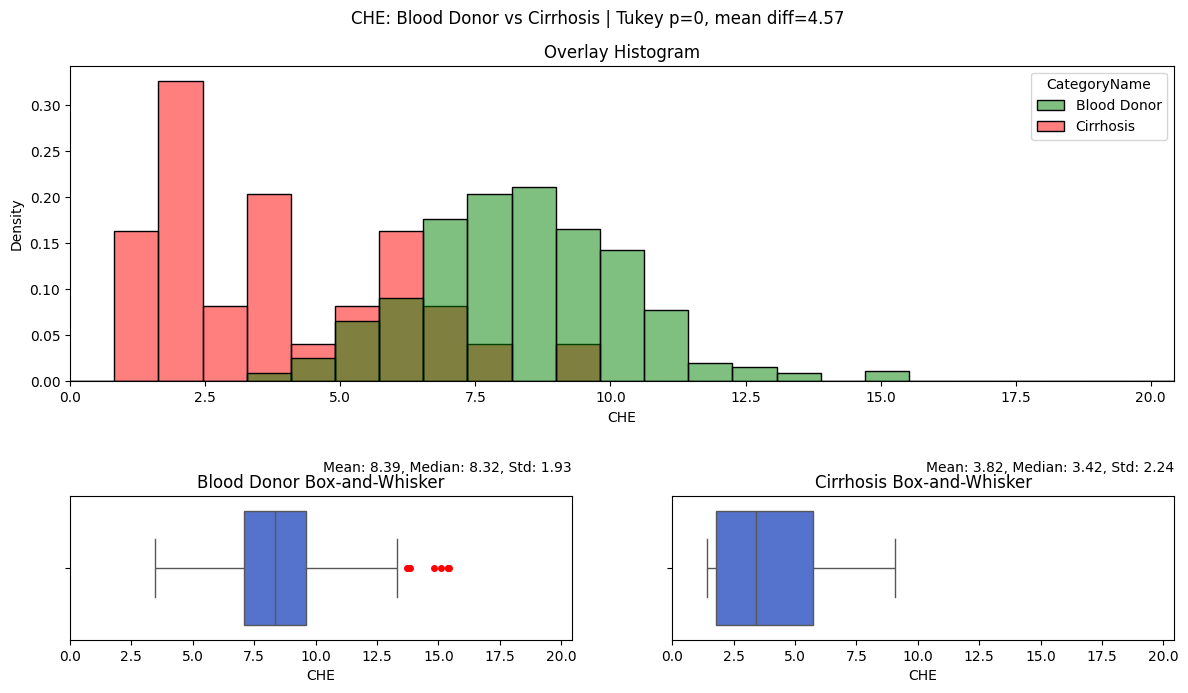

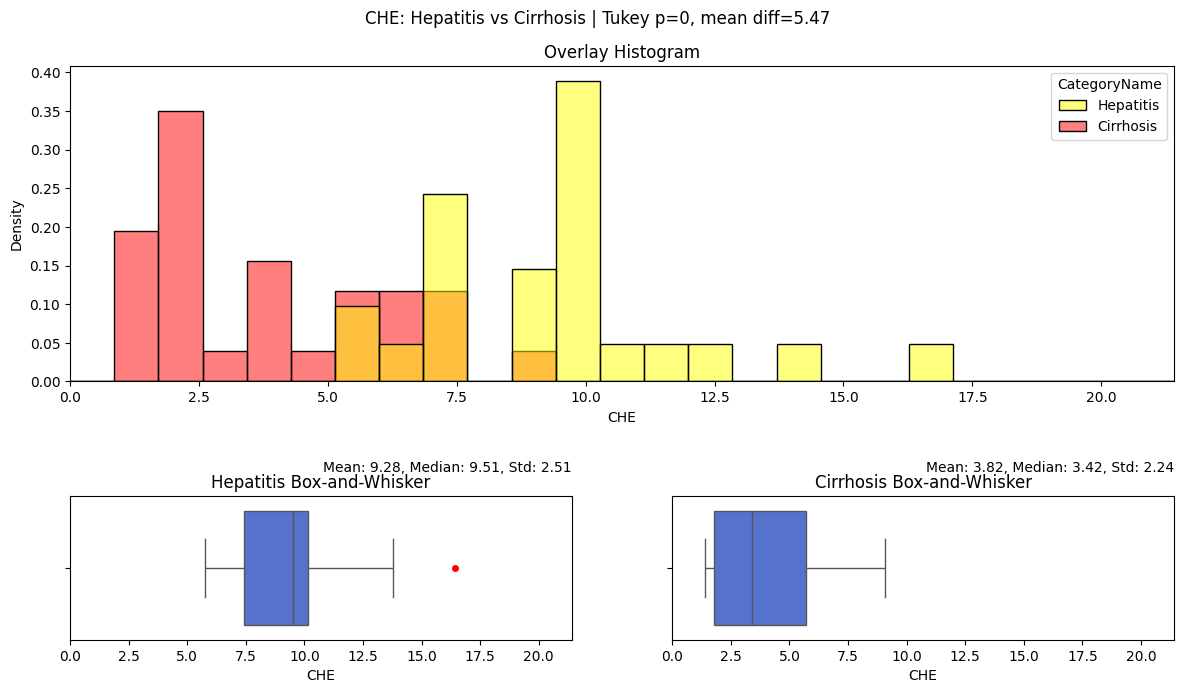

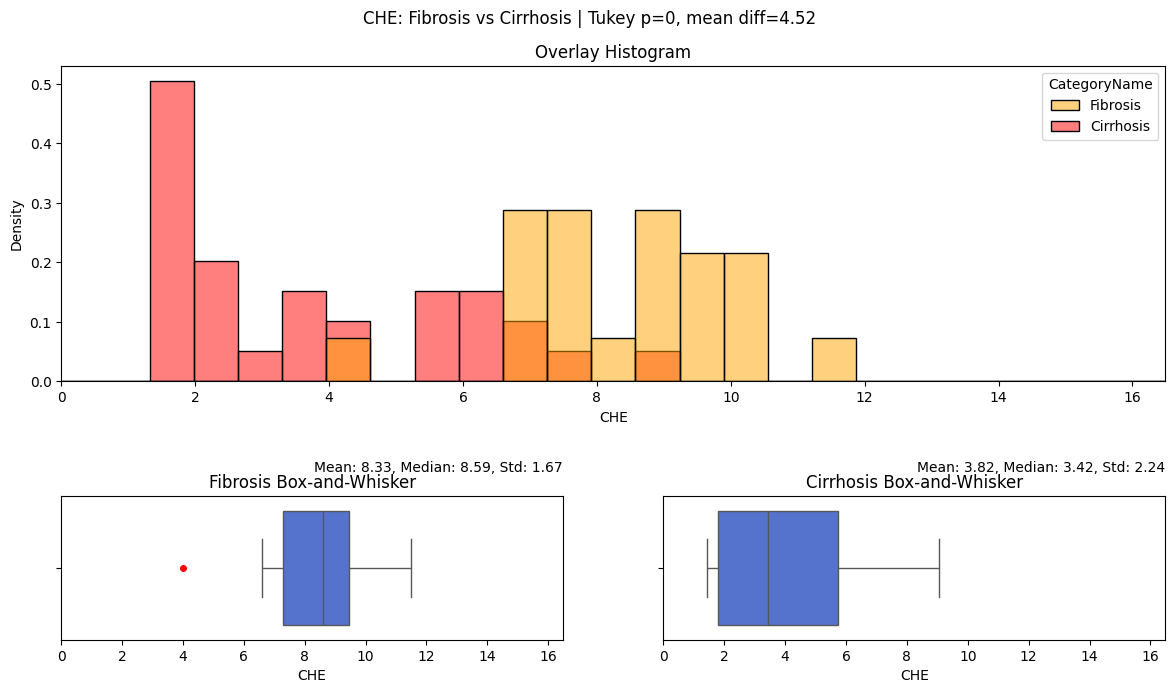

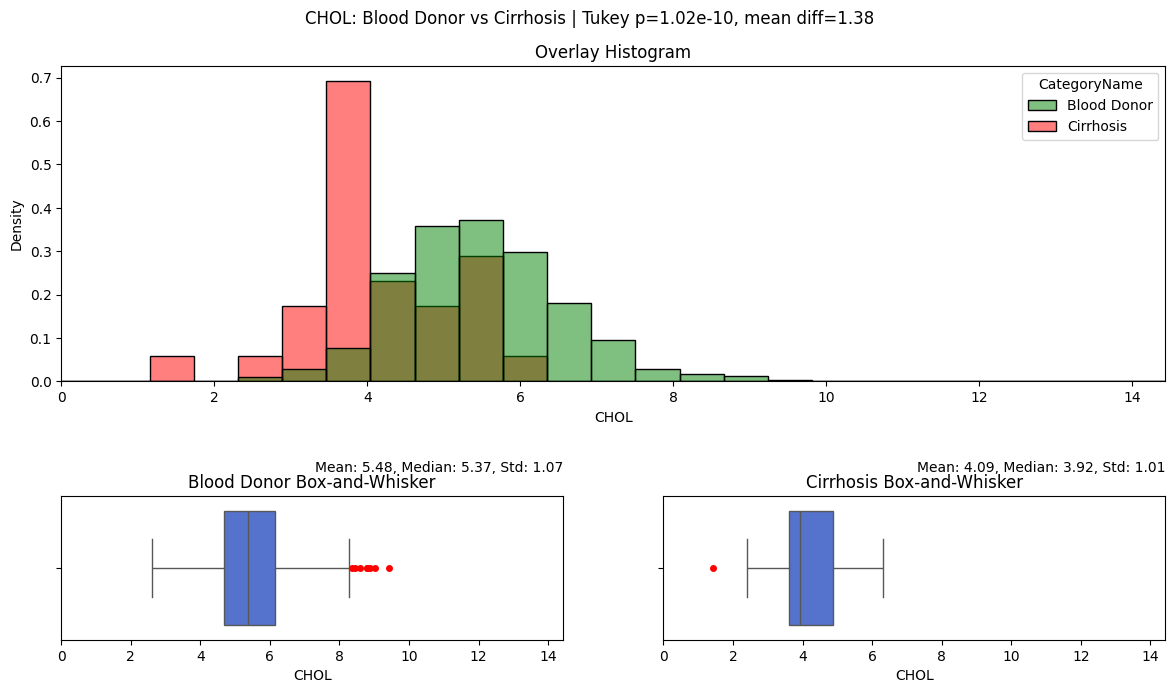

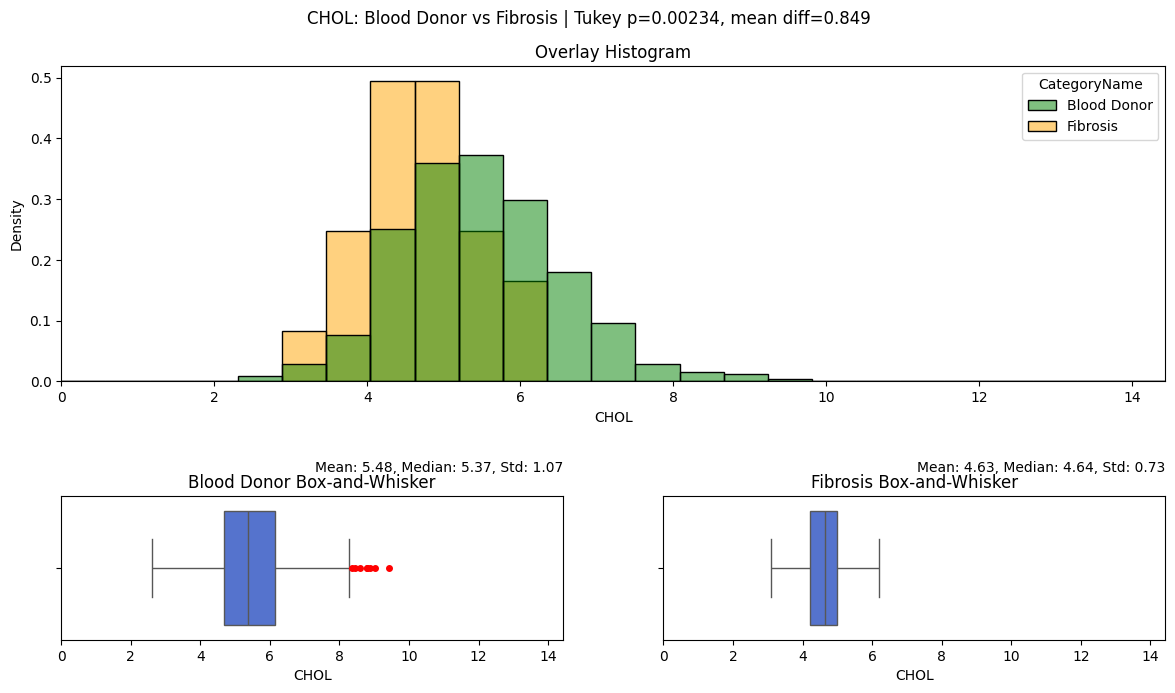

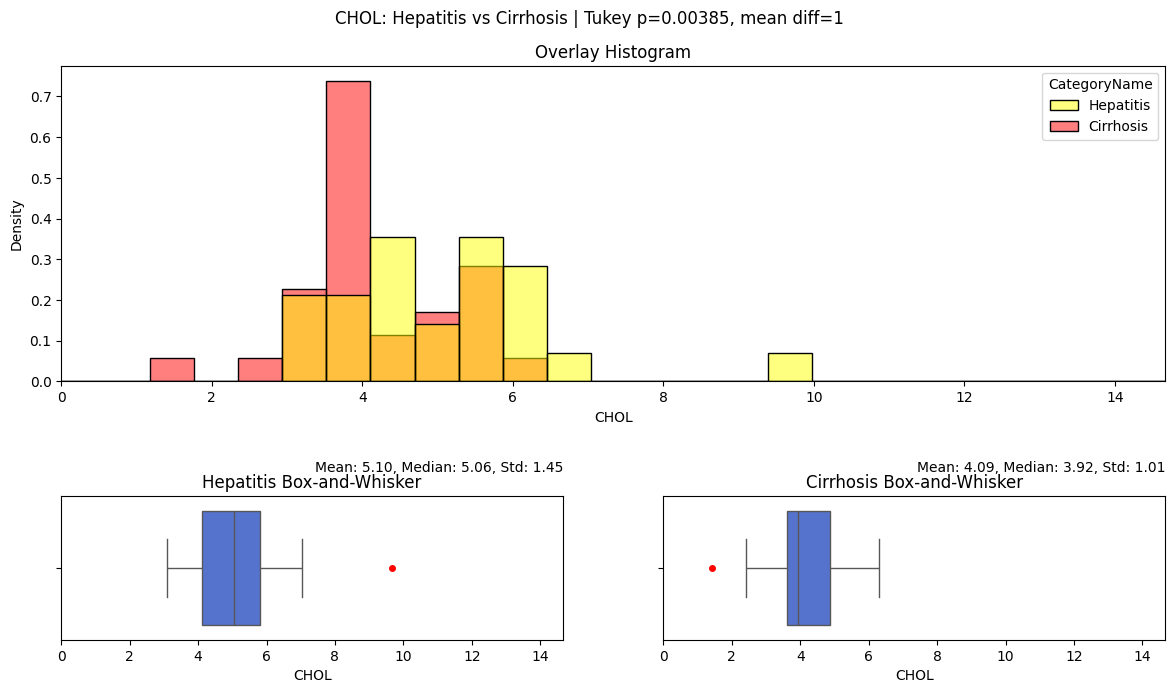

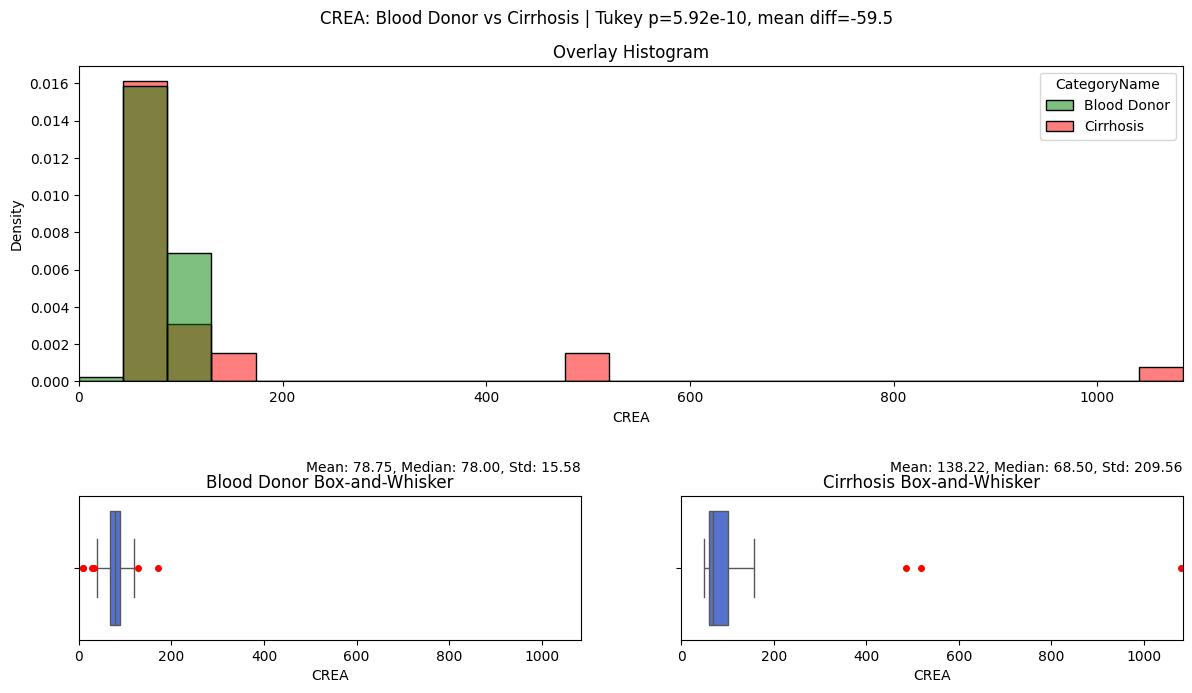

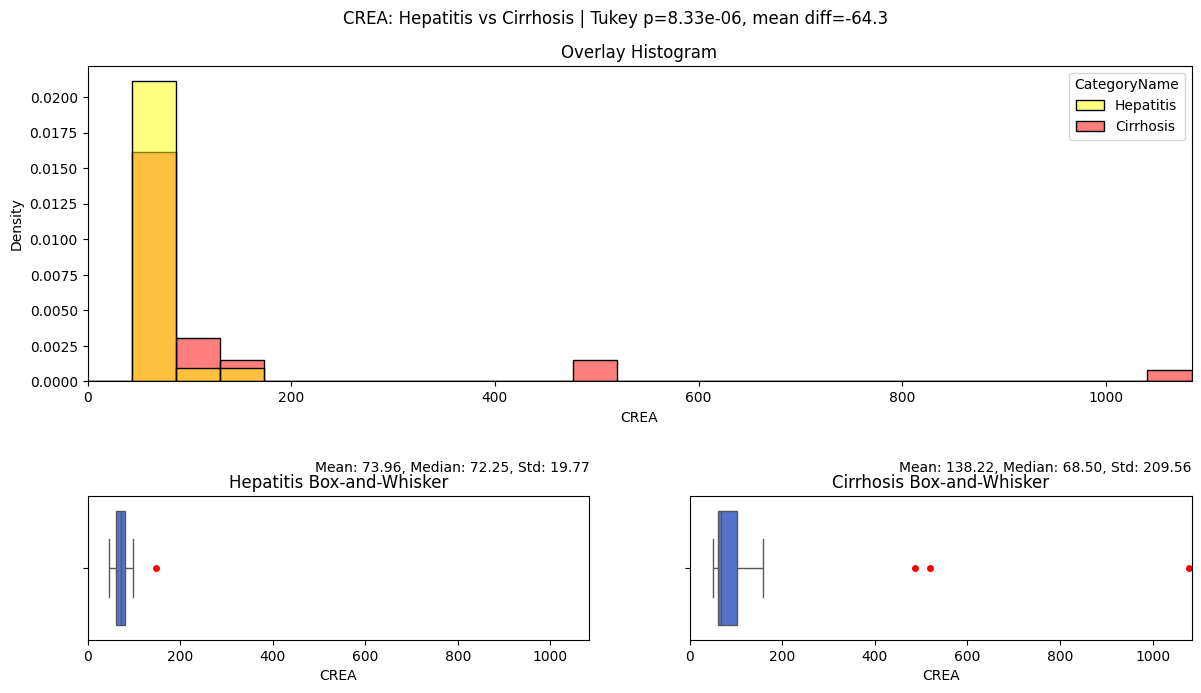

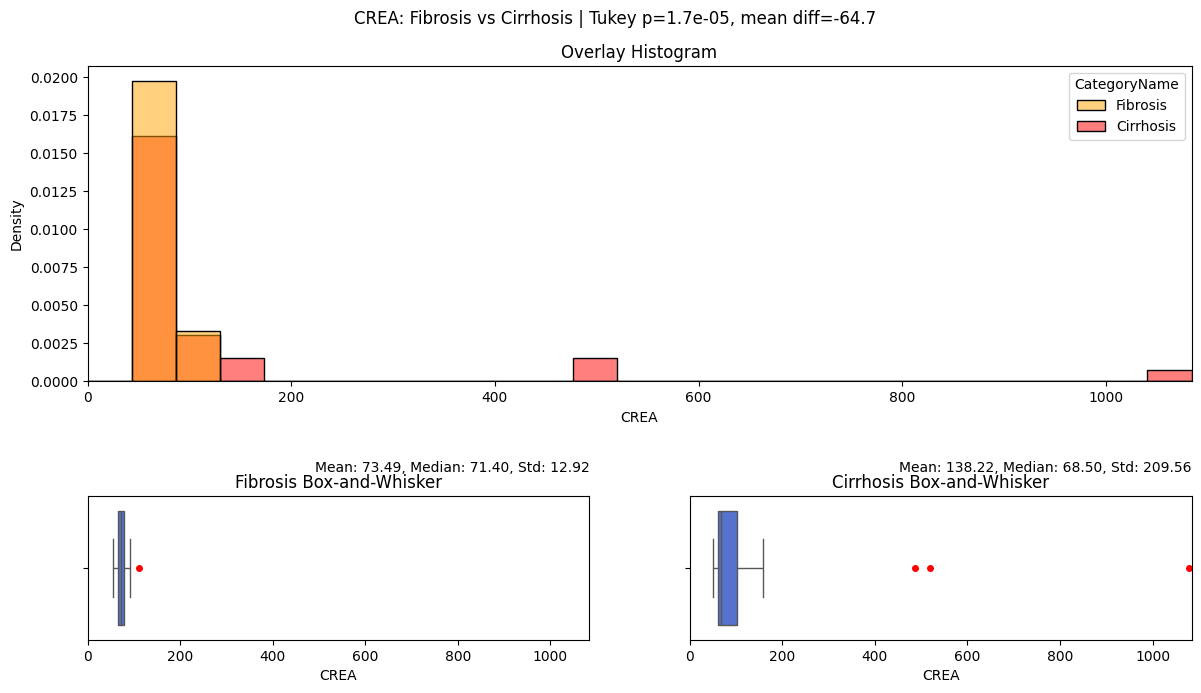

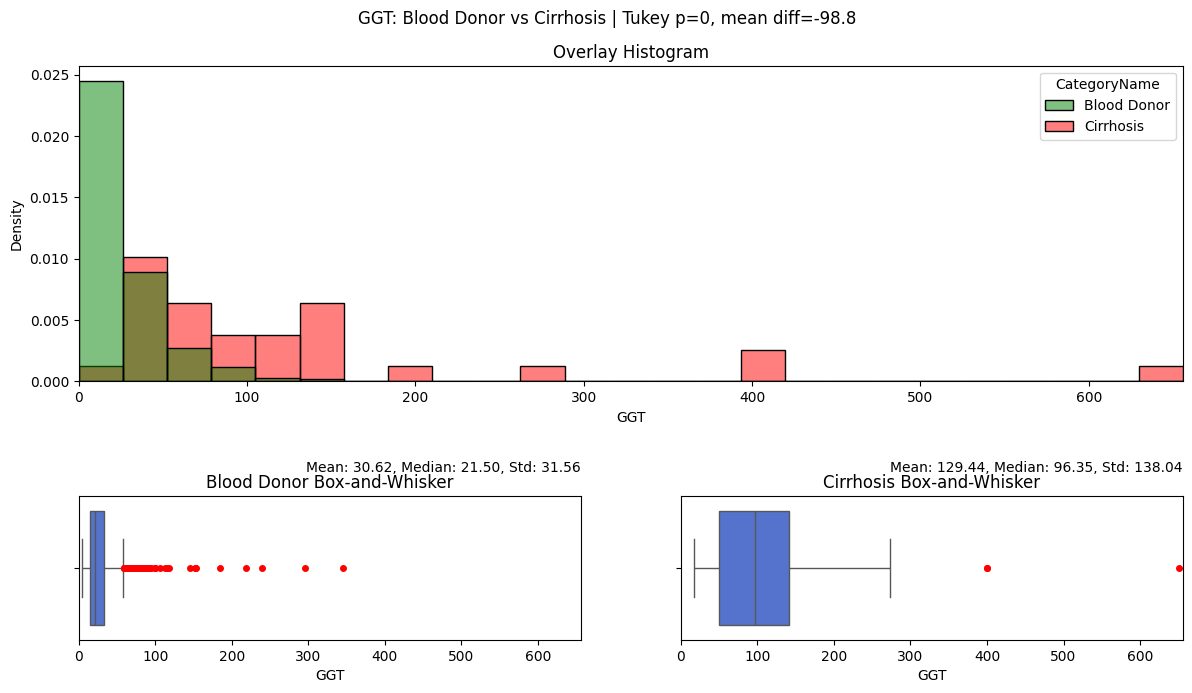

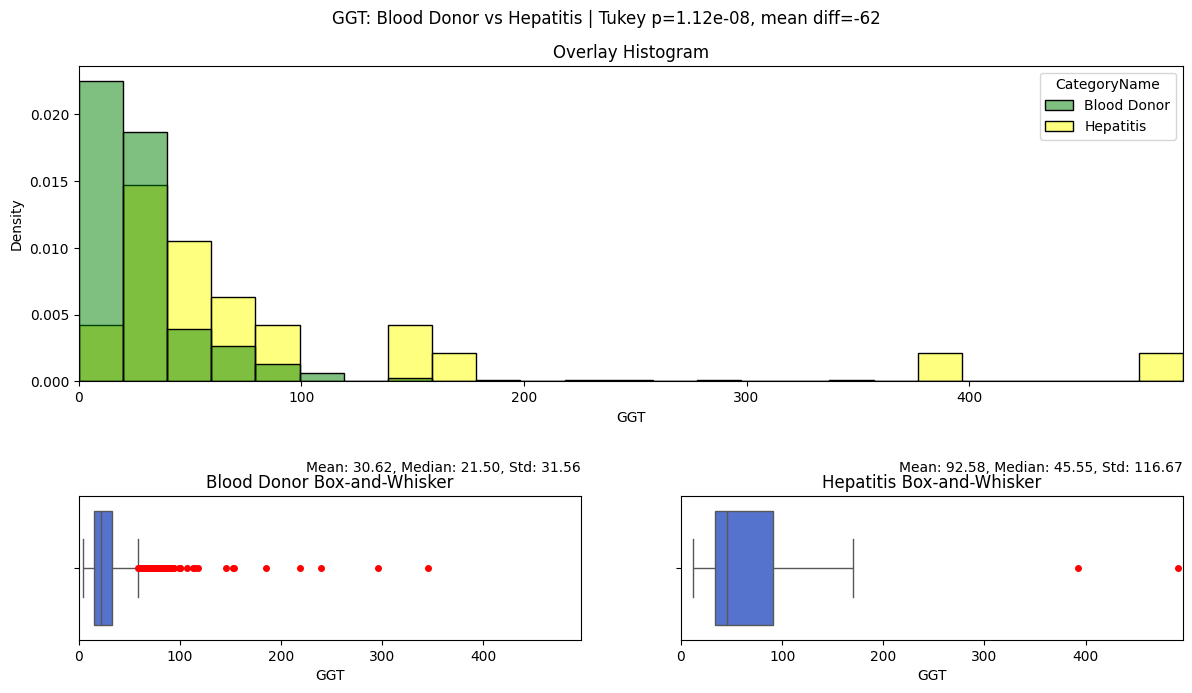

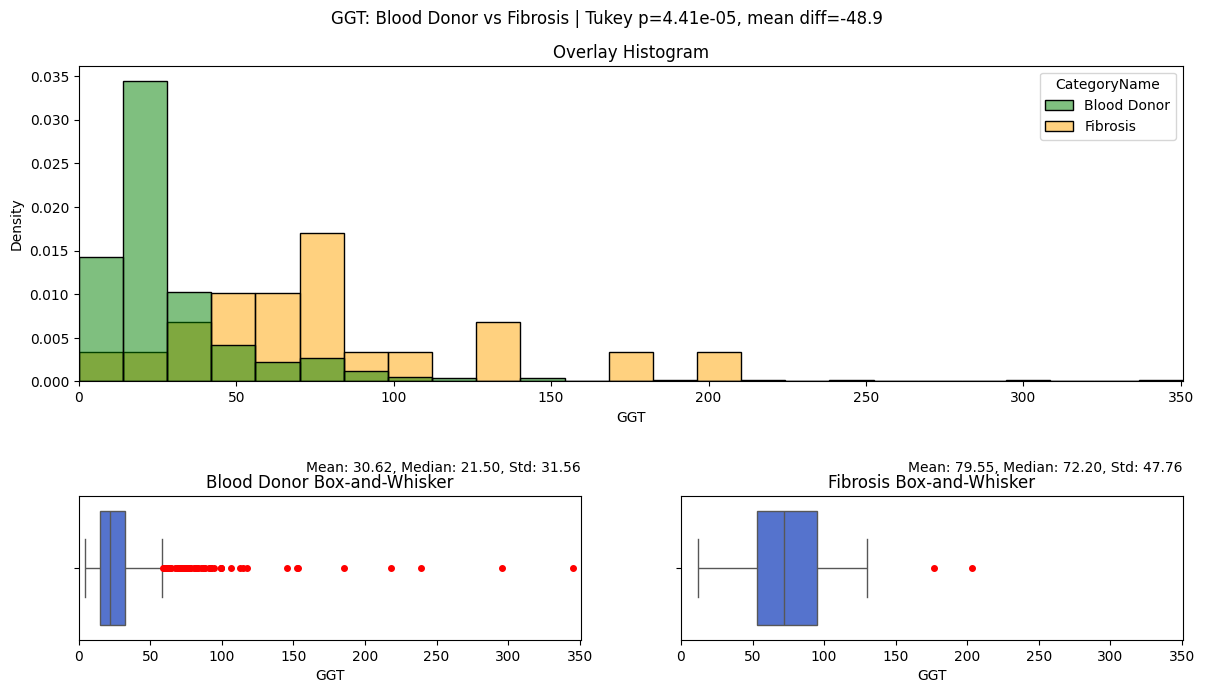

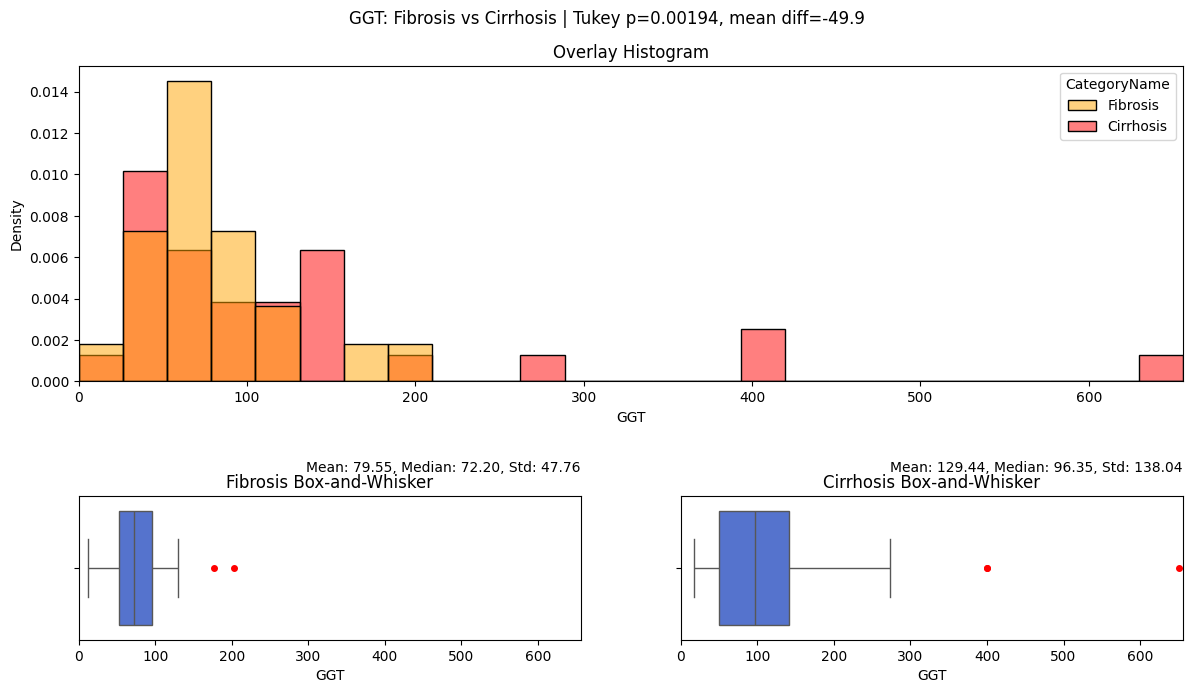

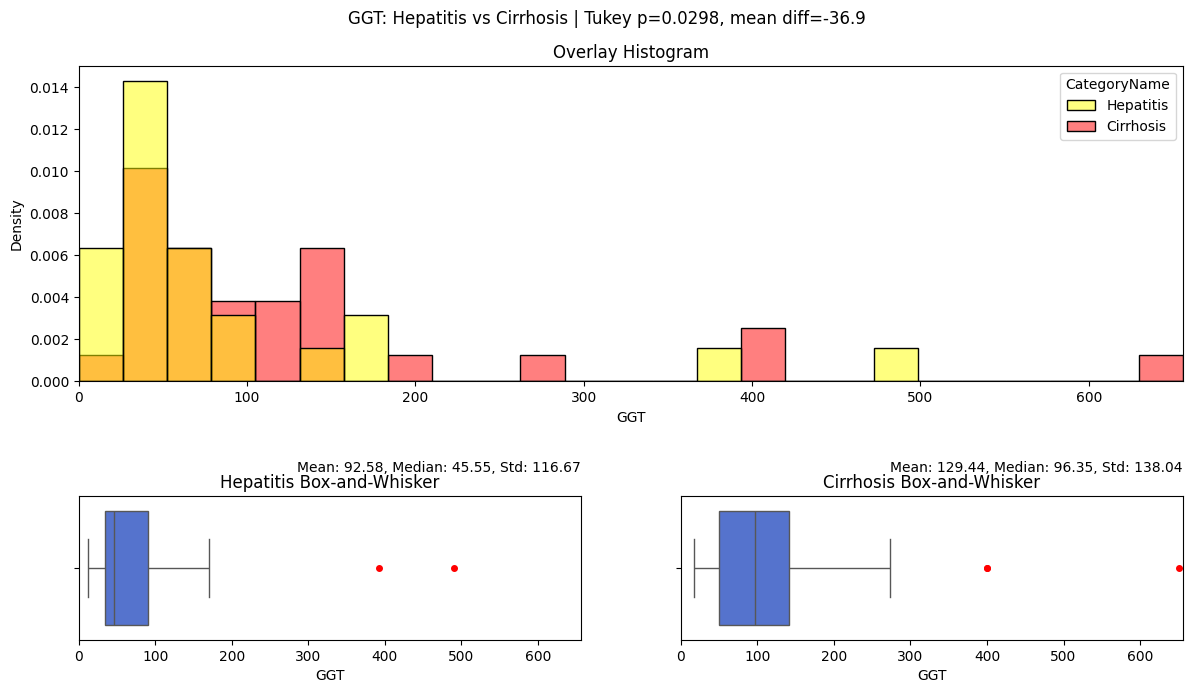

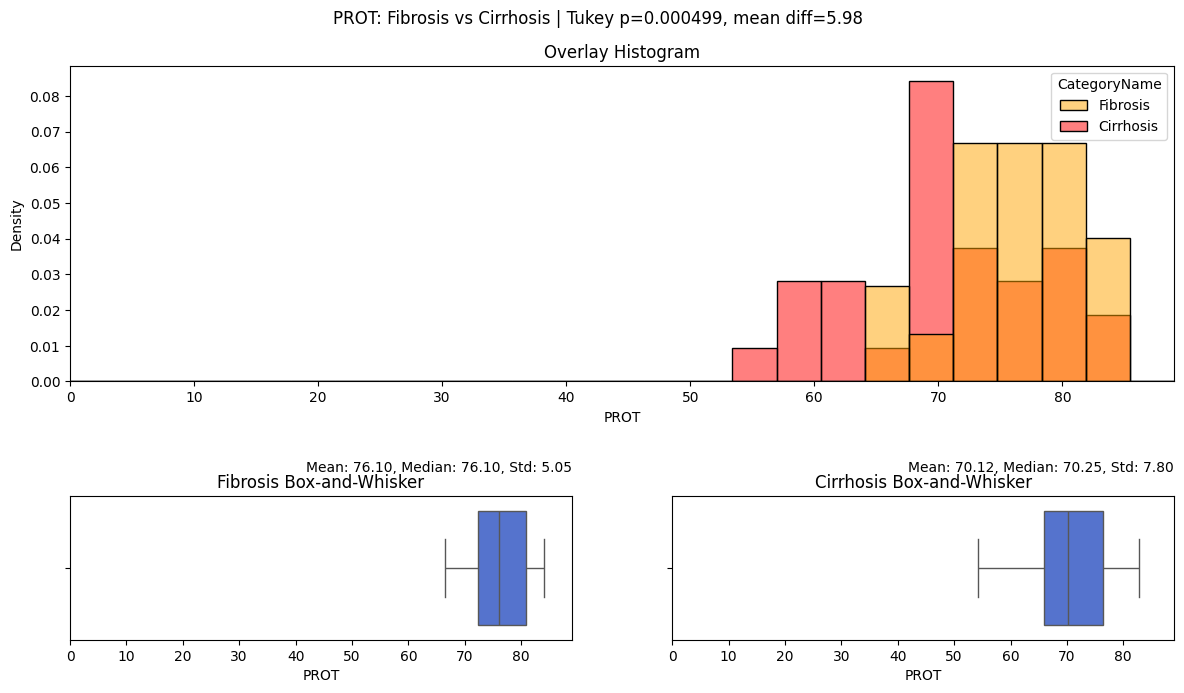

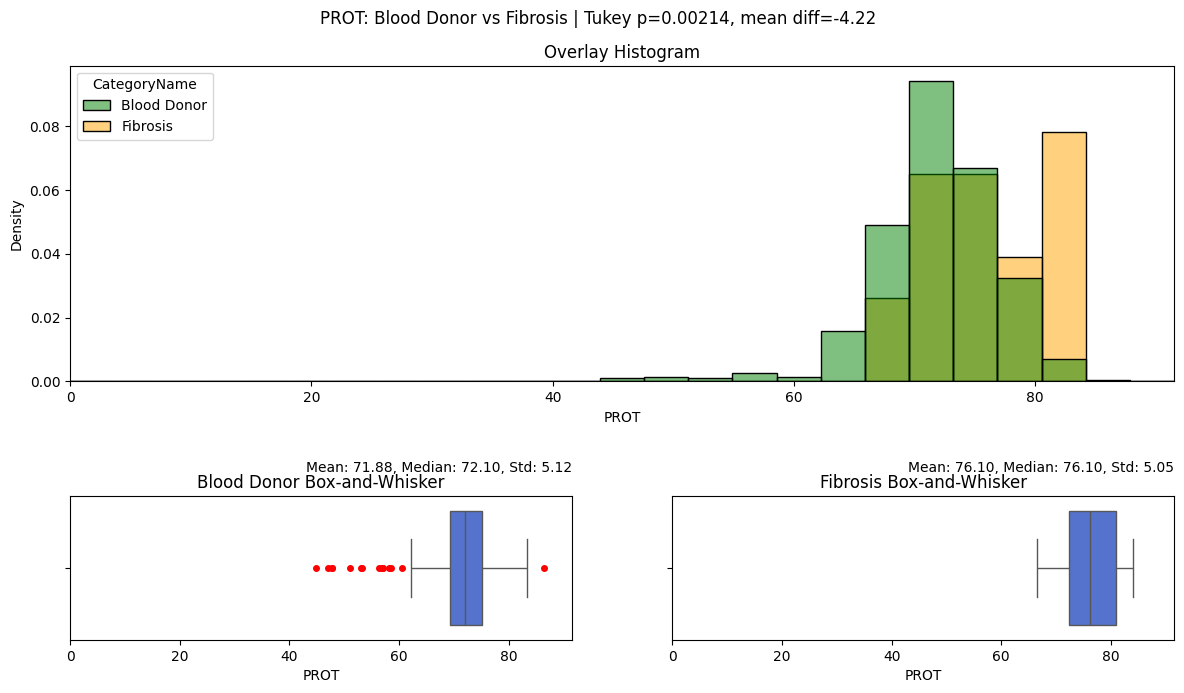

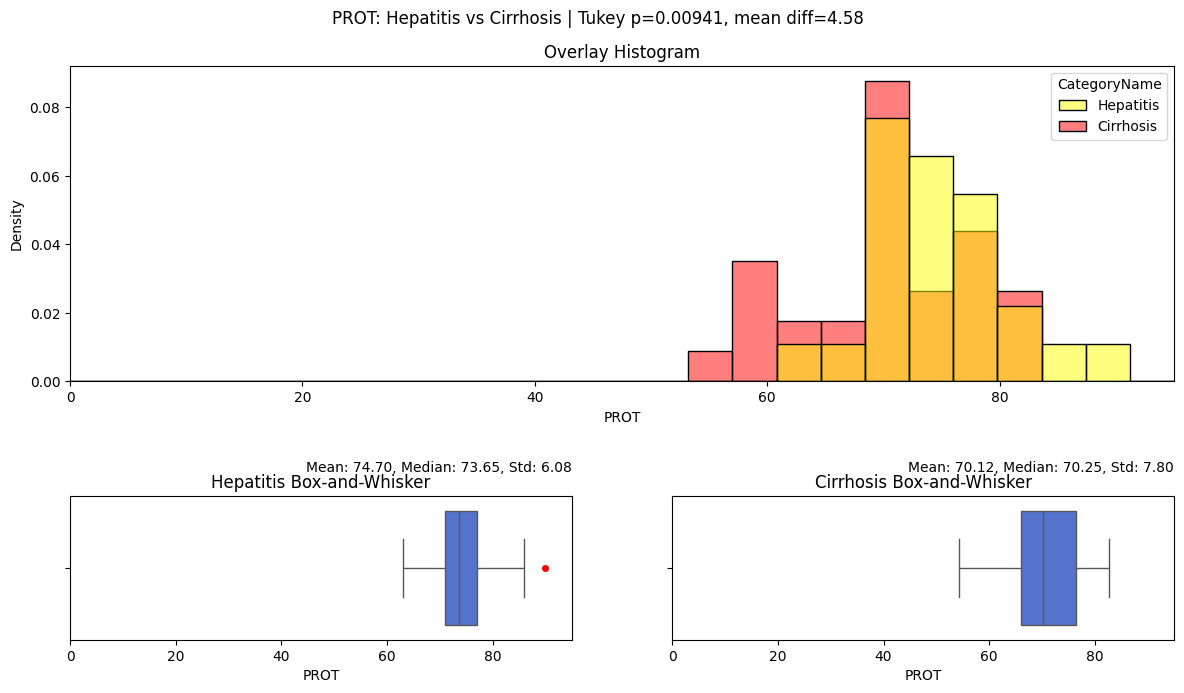

In [27]:
# Now we create plots for all (40) significant Tukey post hoc comparisons

sig_posthoc = posthoc_df[posthoc_df["p_tukey"] < 0.05].copy()
sig_posthoc = sig_posthoc.sort_values(["Feature", "p_tukey"])

print(f"Significant comparisons to plot: {len(sig_posthoc)}")

for _, row in sig_posthoc.iterrows():
    feat = row["Feature"]
    g1 = row["Group1"]
    g2 = row["Group2"]
    pval = row["p_tukey"]
    mdiff = row["Mean_diff"]

    sub = df_test[df_test["CategoryName"].isin([g1, g2])][["CategoryName", feat]].dropna().copy()
    g1_vals = sub.loc[sub["CategoryName"] == g1, feat]
    g2_vals = sub.loc[sub["CategoryName"] == g2, feat]

    data_min = min(g1_vals.min(), g2_vals.min())
    data_max = max(g1_vals.max(), g2_vals.max())

    x_lower = min(data_min, 0)
    x_upper = data_max + 5

    # Use fixed bin edges so the histogram spans the same full range as the box plots.
    hist_bins = np.linspace(x_lower, x_upper, 26)

    fig = plt.figure(figsize=(12, 7))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1], hspace=0.5, wspace=0.2)

    ax_hist = fig.add_subplot(gs[0, :])
    ax_box_1 = fig.add_subplot(gs[1, 0])
    ax_box_2 = fig.add_subplot(gs[1, 1])

    fig.suptitle(f"{feat}: {g1} vs {g2} | Tukey p={pval:.3g}, mean diff={mdiff:.3g}", y=0.98)

    # Histogram on top
    sns.histplot(
        data=sub,
        x=feat,
        hue="CategoryName",
        bins=hist_bins,
        stat="density",
        common_norm=False,
        alpha=0.50,
        palette=CATEGORY_PALETTE,
        ax=ax_hist,
    )
    ax_hist.set_title("Overlay Histogram")

    # Box-and-whisker plots below using shared helper
    make_box_and_whiskers(ax_box_1, g1_vals, f"{g1} Box-and-Whisker", feat, False)
    make_box_and_whiskers(ax_box_2, g2_vals, f"{g2} Box-and-Whisker", feat, False)

    for ax in (ax_hist, ax_box_1, ax_box_2):
        ax.set_xlim(x_lower, x_upper)
        ax.margins(x=0)
    fig.subplots_adjust(left=0.06, right=0.98, top=0.9, bottom=0.08)
    plt.show()



#### Post hoc Tukey HSD results
- Cirrhosis is the most consistently different group: it differs significantly from the other groups in almost every lab feature
- BIL, CHE, GGT, and CREA show the most group pairs that reject the null with very small p-values
- Blood Donors and Cirrhosis are the most frequently different pair
  - This makes sense, as cirrhosis is biologically the most advanced stage of liver disease

Now that our Data Curation, Processing, and EDA is complete, we can move onto our primary analysis.

## 5. Primary Analysis

We chose classification (binary classification and multi-class classification) for our machine learning technique in order to compare between healthy vs diseased and analyze multi-class stage prediction comparisons. In our confusion matrices, ROC summaries, and feature-importance diagnostics, we are able to extract insights to answer the two research questions stated in the Introduction.


### Primary modeling workflow

We used a repeatable workflow: define tasks, train models, report metrics, and visualize error patterns. For each task, we first focused on class-sensitive metrics (Macro F1, recall behavior, confusion matrices) and then used ROC-AUC as secondary discrimination context. 


### 5.1 Binary Classification - Healthy vs. Diseased

We first explored the binary problem: can blood lab values distinguish a healthy patient (Blood Donor, category 0) from a patient with any liver disease (Hepatitis, Fibrosis, or Cirrhosis - categories 1, 2, 3)? In a real clinical setting, a high-accuracy binary classifier could flag at-risk patients for further diagnostic workup without requiring a biopsy.

We trained and compared four models:
- Logistic Regression: linear, interpretable baseline
- Random Forest: ensemble of decision trees; robust to outliers
- Support Vector Machine (SVM): effective on small-to-medium datasets with an RBF kernel
- Gradient Boosting: sequential ensemble that corrects residual errors

All models use `class_weight='balanced'` (or equivalent sample weighting) to handle the ~7:1 class imbalance.


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_auc_score, 
    roc_curve, 
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize


In this section, in order to avoid data leakage between the testing group and the training group, we take the raw data frame from before and then create a train-test split for both binary and multi-classification. We then impose the median imputation that we performed in an earlier part in order to avoid data leakage between test and train data. See these two links more information about this topic. 
- https://scikit-learn.org/stable/common_pitfalls.html#data-leakage-during-pre-processing

In [29]:
from sklearn.impute import SimpleImputer

features = ["Age", "ALB", "ALP", "ALT", "AST", "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"]

# convert category to binary for binary classification
df['IsDiseased'] = (df['Category'] > 0).astype(int)

X = df_raw[features]
y_binary = df['IsDiseased']
y_multi = df['Category']

# stratified 80/20 split
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

# impute missing values after making training-set split to prevent test-set leakage
imputer_b = SimpleImputer(strategy="median")
X_train_binary = imputer_b.fit_transform(X_train_binary)
X_test_binary = imputer_b.transform(X_test_binary)

imputer_m = SimpleImputer(strategy="median")
X_train_multi = imputer_m.fit_transform(X_train_multi)
X_test_multi = imputer_m.transform(X_test_multi)

# Scale features by fitting only on training data
scaler_b = StandardScaler()
X_train_b_sc = scaler_b.fit_transform(X_train_binary)
X_test_b_sc = scaler_b.transform(X_test_binary)

scaler_m = StandardScaler()
X_train_m_sc = scaler_m.fit_transform(X_train_multi)
X_test_m_sc = scaler_m.transform(X_test_multi)

print("Binary Classification - Class distribution in train/test split:")
print("\tTraining Distribution:")
for key, value in y_train_binary.value_counts().items():
    print(f"\t\t- {key}: {value}")
print("\tTest Distribution:")
for key, value in y_test_binary.value_counts().items():
    print(f"\t\t- {key}: {value}")

print()

print("Multi-class Classification - Class distribution in train/test:")
print("\tTraining Distribution:")
for key, value in y_train_multi.value_counts().items():
    print(f"\t\t- {key}: {value}")
print("\tTest Distribution:")
for key, value in y_test_multi.value_counts().items():
    print(f"\t\t- {key}: {value}")


Binary Classification - Class distribution in train/test split:
	Training Distribution:
		- 0: 432
		- 1: 60
	Test Distribution:
		- 0: 108
		- 1: 15

Multi-class Classification - Class distribution in train/test:
	Training Distribution:
		- 0: 432
		- 3: 24
		- 1: 19
		- 2: 17
	Test Distribution:
		- 0: 108
		- 3: 6
		- 1: 5
		- 2: 4


In [30]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    ),
    "SVM": SVC(
        kernel="rbf", class_weight="balanced", probability=True, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, random_state=42
    ),
}

In [31]:
binary_results = {}

for model_name, model in models.items():
    if model_name == "Gradient Boosting":
        sw = compute_sample_weight("balanced", y_train_binary)
        model.fit(X_train_b_sc, y_train_binary, sample_weight=sw)
    else:
        model.fit(X_train_b_sc, y_train_binary)

    y_pred = model.predict(X_test_b_sc)
    y_proba = model.predict_proba(X_test_b_sc)[:, 1]

    report = classification_report(y_test_binary, y_pred, target_names=["Healthy", "Diseased"], output_dict=True)
    roc_auc = roc_auc_score(y_test_binary, y_proba)
    confusion_matrix_ = confusion_matrix(y_test_binary, y_pred)

    binary_results[model_name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "report": report,
        "roc_auc": roc_auc,
        "cm": confusion_matrix_,
    }
    macro_f1 = report["macro avg"]["f1-score"]
    print(f"{model_name}")
    print("-"*30)

    print(f"\tMacro F1: {macro_f1:.4f}")
    print(f"\tROC-AUC: {roc_auc:.4f}")


Logistic Regression
------------------------------
	Macro F1: 0.8481
	ROC-AUC: 0.9401
Random Forest
------------------------------
	Macro F1: 0.8887
	ROC-AUC: 0.9981
SVM
------------------------------
	Macro F1: 0.9077
	ROC-AUC: 0.9704
Gradient Boosting
------------------------------
	Macro F1: 0.9194
	ROC-AUC: 0.9951


Observe from these results that the best models that we saw for macro f1 and ROC AUC are random forest and gradient boosting. This seems to coincide with intuition that more complex models are able to find patterns that more simple models like logistic regression and support vector machines are not able to find. 

### 5.2 Binary Classification Visualization

We created the following plots to summarize the results of binary classification. They are able to address how well each model can separate healthy patients from diseased ones, distinguish the exact disease stage, and present which features drive the classification.


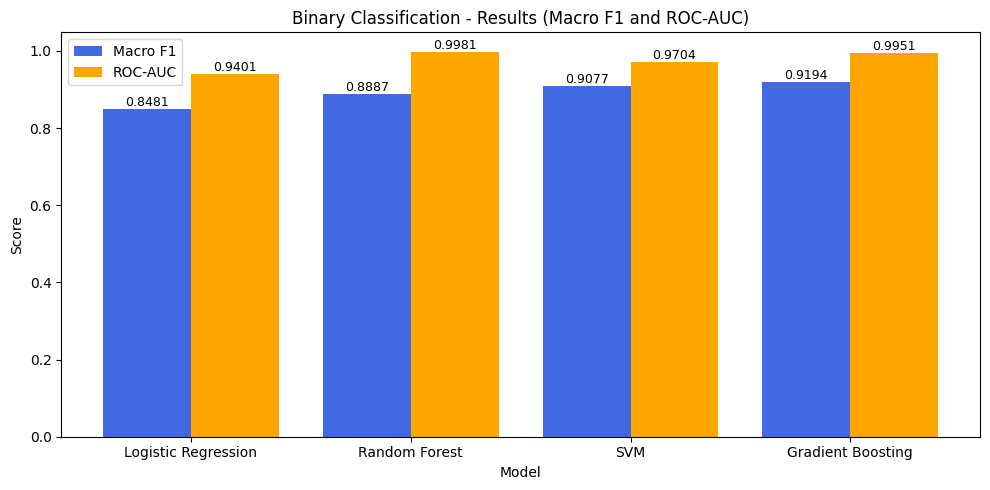

In [32]:
model_names = list(binary_results.keys())

f1s = []
roc_aucs = []
for name in model_names:
    f1s.append(binary_results[name]["report"]["macro avg"]["f1-score"])
    roc_aucs.append(binary_results[name]["roc_auc"])

fig, ax = plt.subplots(figsize=(10, 5))

x = np.array([i for i in range(len(model_names))])
SECTION_WIDTH = 0.4
bars1 = ax.bar(x - SECTION_WIDTH/2, f1s, SECTION_WIDTH, label="Macro F1", color="royalblue")
bars2 = ax.bar(x + SECTION_WIDTH/2, roc_aucs,  SECTION_WIDTH, label="ROC-AUC",  color="orange")

ax.set_title("Binary Classification - Results (Macro F1 and ROC-AUC)")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.bar_label(bars1, fmt="%.4f", fontsize=9)
ax.bar_label(bars2, fmt="%.4f", fontsize=9)
plt.tight_layout()
plt.show()

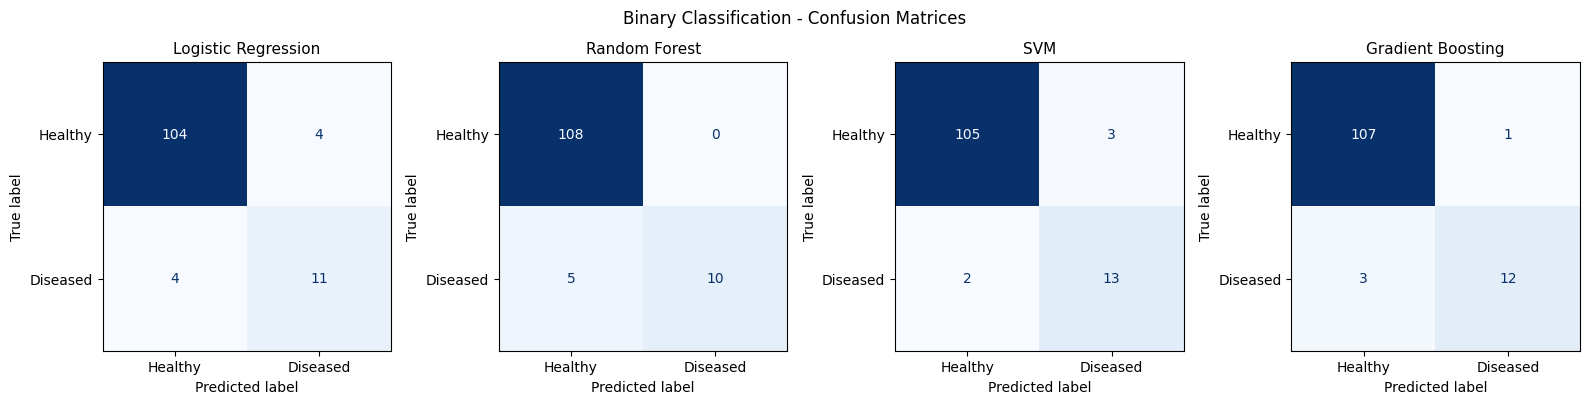

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Binary Classification - Confusion Matrices")

for ax, model_name in zip(axes, model_names):
    confusion_matrix = binary_results[model_name]["cm"]

    disp = ConfusionMatrixDisplay(
        confusion_matrix,
        display_labels=["Healthy", "Diseased"]
    )

    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(model_name, fontsize=11)

plt.tight_layout()
plt.show()

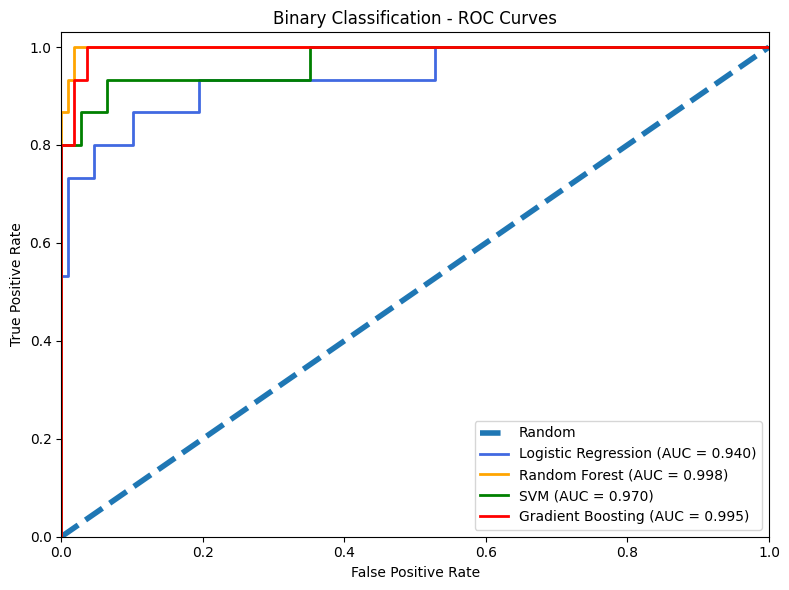

In [34]:
# ROC curves
fig, ax = plt.subplots(figsize=(8,  6))

ax.plot([0, 1], [0, 1], "--", lw=4, label="Random")

for (model_name, res), color in zip(binary_results.items(), ["royalblue", "orange", "green", "red"]):
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test_binary, res["y_proba"])
    ax.plot(false_positive_rate, true_positive_rate, label=f"{model_name} (AUC = {res['roc_auc']:.3f})", color=color, lw=2)

ax.set_title("Binary Classification - ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.03])
plt.tight_layout()
plt.show()

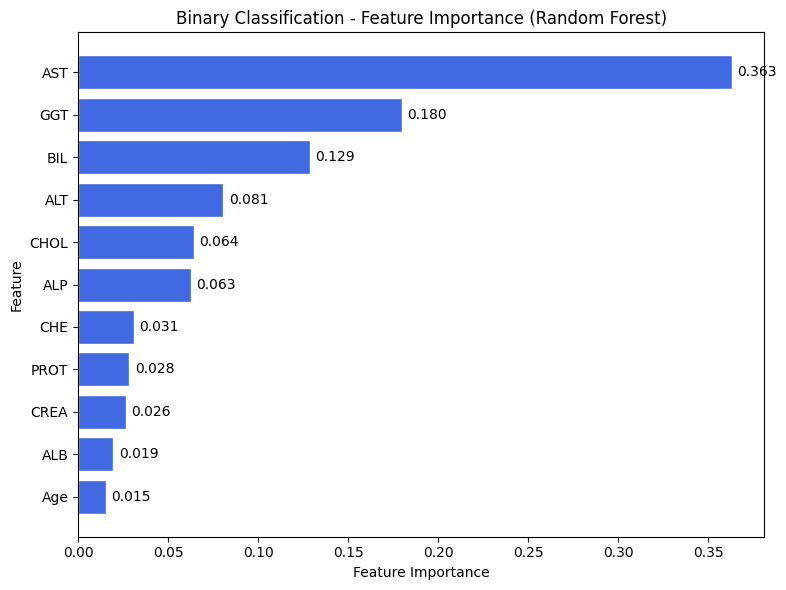

In [35]:
forest_model = binary_results["Random Forest"]["model"]

feature_importance = (
    pd.DataFrame({"Feature": features, "Importance": forest_model.feature_importances_})
    .sort_values("Importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="royalblue",
    edgecolor="white"
)

ax.bar_label(bars, fmt="%.3f", padding=4)

ax.set_title("Binary Classification - Feature Importance (Random Forest)")
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

It appears that, from our investigation into random forests' feature importance, AST GGT and BIL are the top three features. This is really important to note because any future research that is done on similar lab data should prefer to capture these three features in ways that maybe the other features in this dataset do not have as much explanatory value over the ultimate result of having liver disease. 

#### Binary Classification Results

The model comparison chart and ROC curves above show how each model performs at distinguishing healthy patients from those with liver disease.

We found that all four models achieve strong ROC-AUC scores, indicating that blood lab values carry substantial signal for detecting the presence of liver disease. The Random Forest and Gradient Boosting models perform the best as they handle the non-linear relationships between lab features well. We are able to see from the confusion matrices that models are better at identifying healthy patients (Blood Donors are the majority class) than diseased patients. Misclassifying a diseased patient as healthy is the more serious clinical error, so the most important metric is recall on the "Diseased" class. Additionally, feature importance from the Random Forest directly aligns with our findings from the ANOVA test, where AST, BIL, GGT, and CHE are the most important features. This strengthens the contention that these biomarkers are the key liver disease indicators.


### 5.3 Multi-class Classification - Predicting Disease Stage

After testing the simpler binary task, we now move on to the (notably more difficult) problem of predicting the exact disease stage. Instead of classifying each patient as diseased or healthy, the model now has to choose between 4 categories:

| Class | Count |
|---|---|
| Blood Donor (0) | 540 |
| Hepatitis (1)   | 24  |
| Fibrosis (2)    | 21  |
| Cirrhosis (3)   | 30  |

As you can see, the dataset is highly imbalanced. The blood donor class has far more examples than the disease class. The minority disease classes are ~18-25x smaller than the Blood Donor class. For instance, there are only 21 Fibrosis cases compared to 540 blood donor cases. This makes multi-class classification significantly harder than the binary case.

To help with this issue, we again use "class_weight='balanced'" when training the models. For evaluation, we focus on metrics that are better suited for class imbalance situations, such as Macro F1. Macro F1 treats each class equally, so poor performance on minority classes will be more clearly reflected.

For ROC-AUC, we use the one-vs-rest (OvR) strategy. This means the model evaluates each class separately against all the other classes. For example, it checks how well the model separates Cirrohsis from non-Cirrhosis, and so on. We then use a macro-average AUC to summarize performance of all classes. The goal of this is to determine how good the model is at distinguishing each disease stage, not just the majority class of Blood Donor.

In [36]:

from sklearn.metrics import confusion_matrix
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    ),
    "SVM": SVC(
        kernel="rbf", class_weight="balanced", probability=True, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, random_state=42
    ),
}

multiclass_results = {}
class_order = [0, 1, 2, 3]
class_labels = ["Blood Donor", "Hepatitis", "Fibrosis", "Cirrhosis"]

# This is necesasry for for one-vs-rest ROC-AUC
y_test_multiclass_binary = label_binarize(y_test_multi, classes=class_order)

for model_name, model in models.items():
    if model_name == "Gradient Boosting":
        training_weights = compute_sample_weight("balanced", y_train_multi)
        model.fit(X_train_m_sc, y_train_multi, sample_weight=training_weights)
    else:
        model.fit(X_train_m_sc, y_train_multi)

    y_pred = model.predict(X_test_m_sc)
    y_proba = model.predict_proba(X_test_m_sc)

    report = classification_report(
        y_test_multi, y_pred,
        labels=class_order,
        target_names=class_labels,
        output_dict=True,
        zero_division=0
    )
    roc_auc_macro = roc_auc_score(y_test_multiclass_binary, y_proba, multi_class="ovr", average="macro")

    multiclass_results[model_name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "report": report,
        "roc_auc_macro": roc_auc_macro,
        "cm": confusion_matrix(y_test_multi, y_pred, labels=class_order),
    }
    macro_f1 = report["macro avg"]["f1-score"]
    weighted_f1 = report["weighted avg"]["f1-score"]
    print(f"{model_name:25s} | Macro F1: {macro_f1:.3f} | Weighted F1: {weighted_f1:.3f} | one-vs-rest AUC: {roc_auc_macro:.3f}")


Logistic Regression       | Macro F1: 0.708 | Weighted F1: 0.927 | one-vs-rest AUC: 0.987
Random Forest             | Macro F1: 0.712 | Weighted F1: 0.937 | one-vs-rest AUC: 0.984
SVM                       | Macro F1: 0.699 | Weighted F1: 0.937 | one-vs-rest AUC: 0.961
Gradient Boosting         | Macro F1: 0.683 | Weighted F1: 0.939 | one-vs-rest AUC: 0.977


### 5.4 Multi-class Visualization

We created the following plots to summarize the results of multi-classification. 

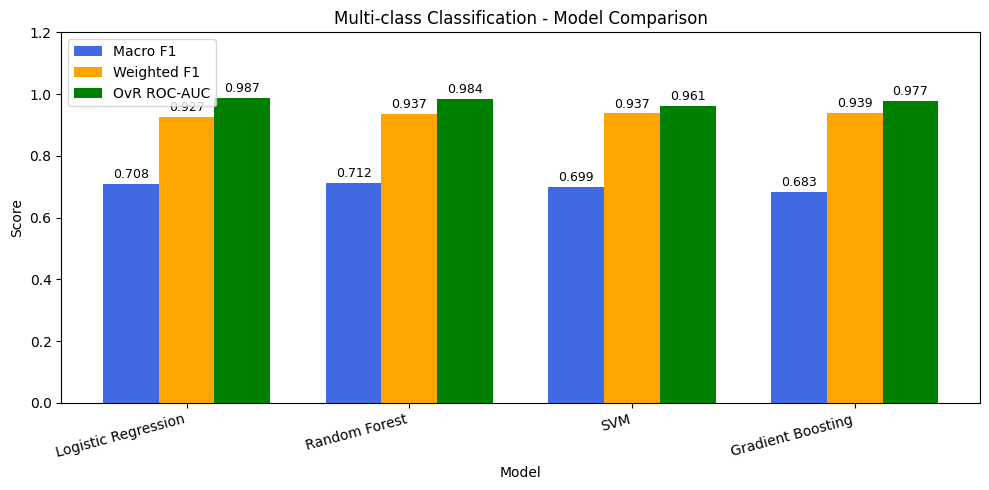

In [37]:
# Model comparison: Macro F1, Weighted F1, and OvR ROC-AUC
multi_model_names = list(multiclass_results.keys())
m_macro_f1s = [multiclass_results[n]["report"]["macro avg"]["f1-score"]    for n in multi_model_names]
m_weighted_f1s = [multiclass_results[n]["report"]["weighted avg"]["f1-score"] for n in multi_model_names]
m_roc_aucs = [multiclass_results[n]["roc_auc_macro"]                      for n in multi_model_names]

model_positions = np.arange(len(multi_model_names))
SECTION_WIDTH = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(model_positions - SECTION_WIDTH,  m_macro_f1s, SECTION_WIDTH, label="Macro F1", color="royalblue")
b2 = ax.bar(model_positions, m_weighted_f1s, SECTION_WIDTH, label="Weighted F1", color="orange")
b3 = ax.bar(model_positions + SECTION_WIDTH,  m_roc_aucs, SECTION_WIDTH, label="OvR ROC-AUC", color="green")

ax.set_title("Multi-class Classification - Model Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticks(model_positions)
ax.set_xticklabels(multi_model_names, rotation=15, ha="right")
ax.set_ylim(0, 1.2)
ax.legend()
for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=9)
plt.tight_layout()
plt.show()

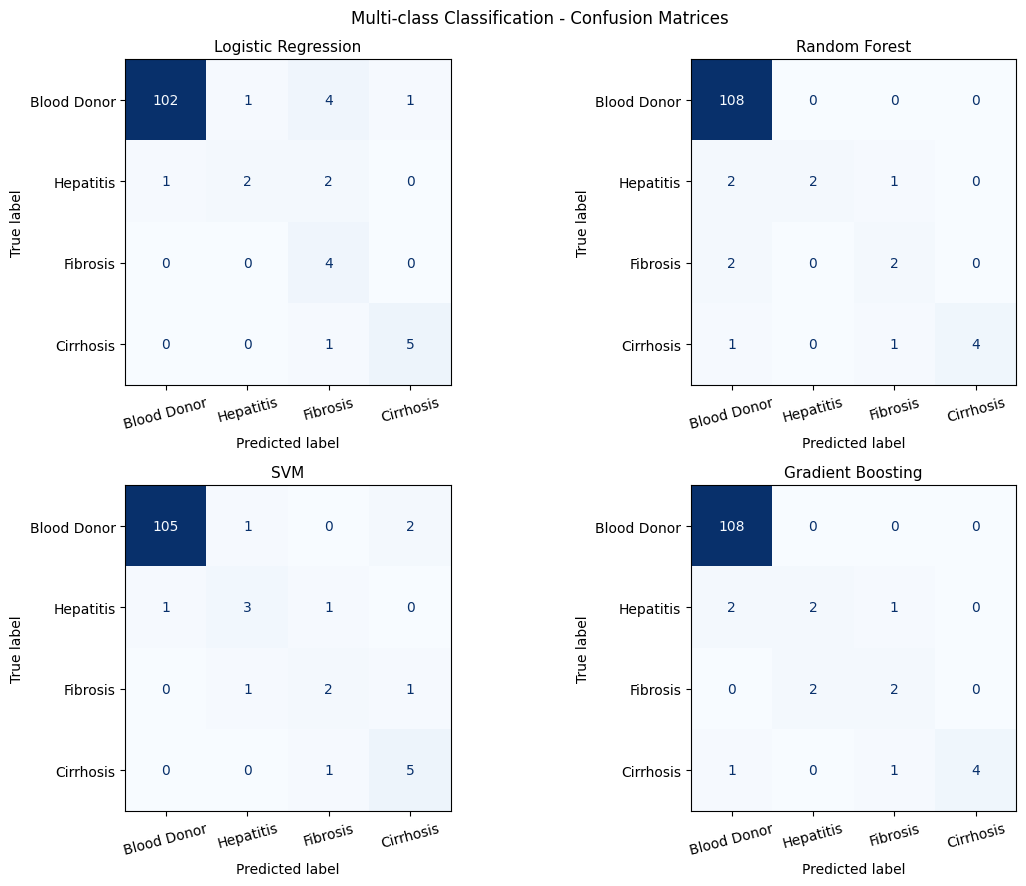

In [38]:
# 2x2 confusion matrix grid labeled with category names
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Multi-class Classification - Confusion Matrices")

for ax, model_name in zip(axes.flat, multi_model_names):
    confusion_matrix = multiclass_results[model_name]["cm"]
    disp = ConfusionMatrixDisplay(confusion_matrix, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=15)
    ax.set_title(model_name, fontsize=11)

plt.tight_layout()
plt.show()

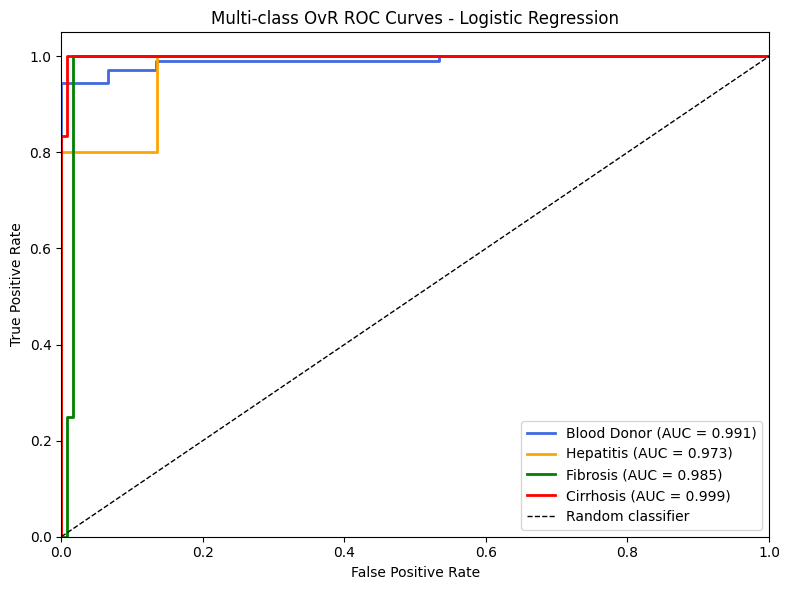

In [39]:
# One-vs-Rest ROC curves for the best-performing model
best_name = max(multiclass_results, key=lambda n: multiclass_results[n]["roc_auc_macro"])
best_proba = multiclass_results[best_name]["y_proba"]

fig, ax = plt.subplots(figsize=(8,  6))

for i, (label, color) in enumerate(zip(class_labels, ["royalblue", "orange", "green", "red"])):
    false_pos_rate, true_pos_rate, _ = roc_curve(y_test_multiclass_binary[:, i], best_proba[:, i])
    roc_auc_i = auc(false_pos_rate, true_pos_rate)
    ax.plot(false_pos_rate, true_pos_rate, label=f"{label} (AUC = {roc_auc_i:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_title(f"Multi-class OvR ROC Curves - {best_name}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

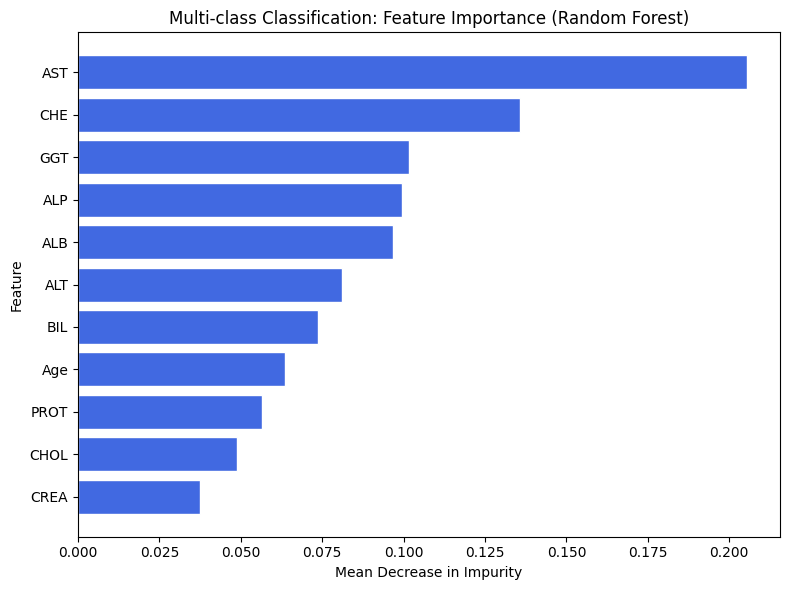

In [40]:
# Feature importance: Random Forest multi-class classifier
rf_multi = multiclass_results["Random Forest"]["model"]
feat_importance_df = (
    pd.DataFrame({"Feature": features, "Importance": rf_multi.feature_importances_})
    .sort_values("Importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(8,  6))
ax.barh(
    feat_importance_df["Feature"],
    feat_importance_df["Importance"],
    color="royalblue",
    edgecolor="white",
)
ax.set_title("Multi-class Classification: Feature Importance (Random Forest)")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

#### Multi-class Classification Results

We found that the models perform much better on the Blood Donor class than on disease classes. This is the direct consequence of class imbalance; even with `class_weight='balanced'`, there is just less data for the model to learn disease-stage boundaries. Hence, Macro F1 is the most important metric for this section, as it treats each class equally regardless of support. On the other hand, Weighted F1 can be inflated by high accuracy on the Blood Donor class. Ensemble models (Random Forest, Gradient Boosting) again outperform the linear Logistic Regression and SVM on this non-linear, imbalanced problem.

Looking at the confusion matrices, we find that the most common misclassification is Hepatitis and Fibrosis being confused with each other or with Blood Donors. These two stages have the smallest sample sizes and the most biological overlap in lab values. We also see that Cirrhosis is the easiest disease stage to identify correctly since its lab values (especially very high BIL, very low CHE and ALB) deviate most from the Blood Donor baseline, as shown by the Tukey HSD results in the EDA section.

From the one-vs-rest ROC curves, we also find that Blood Donor and Cirrhosis classes achieve the highest per-class AUC scores. This is consistent with their distinct lab profiles. On the other hand, Hepatitis and Fibrosis have lower AUC, reflecting their intermediate and overlapping lab values.

Finally, we find that the feature ranking is nearly identical to the binary case, where AST, BIL, GGT, CHE, and ALB are the same biomarkers that distinguish healthy from diseased patients and are also the ones that differentiate disease stages from each other.


---


## 6. Primary Analysis Insights and Conclusions

In this project, we wanted to answer the question: can routine blood laboratory tests predict liver disease and its stage?

From exploratory analysis, our statistical tests (ANOVA, Kruskal-Wallis, post-hoc Tukey HSD) established that blood biomarkers carry statistically significant signal across disease stages. The most discriminating features were:
- AST (Aspartate Transaminase): liver cell damage enzyme; rises sharply in all liver disease
- BIL (Bilirubin): liver waste product; extremely elevated in Cirrhosis
- GGT (Gamma-glutamyl transferase): liver/bile duct stress marker; strongest in Cirrhosis
- CHE (Acetylcholinesterase): synthesized by liver; drops as liver function declines
- ALB (Albumin): liver-produced protein; markedly low in Cirrhosis

We extracted several key insights from ML. Determining healthy vs. diseased patients is achievable with high confidence with binary classification. All four models achieved strong ROC-AUC scores, with ensemble methods (Random Forest, Gradient Boosting) leading. This means that blood tests can reliably flag patients with liver disease for further evaluation. Multi-class classification (exact stage prediction) is harder but still informative. The models were able to correctly identify Cirrhosis with high reliability because its lab values are dramatically distinct. However, Hepatitis and Fibrosis were harder to separate, reflecting their biological similarity in the early disease stages. In both binary and multi-class tasks, the Random Forest assigned highest importance to AST, BIL, GGT, CHE, and ALB, which happens to be the exact features that ANOVA and Tukey HSD identified as most different across groups. This cross-validation between classical statistics and ML strengthens our confidence in these biomarkers.

### Final Answer to Our Research Questions

Question 1: Can routine blood lab tests reliably distinguish healthy patients from those with liver disease?
Answer: Yes. All four ML models achieved high ROC-AUC (>0.90) on binary classification, confirming that the lab panel carries strong signal.

Question 2: Can lab values predict the specific stage of liver disease?
Answer: Partially. Cirrhosis is reliably identified. Early-stage disease (Hepatitis, Fibrosis) is harder to classify from lab values alone due to biological overlap and limited data. Nonetheless, the models still outperform random guessing on all classes.

These findings support the potential of ML-assisted blood test interpretation as a non-invasive screening tool, while making clear that larger and more balanced datasets are the key bottleneck for improvement.

---

## 7. Advanced Analysis: Improving the Modeling Pipeline

In our Primary Analysis (just above), we trained our classification models using a single 80/20 train-test split, the original dataset features, and `class_weight='balanced'` to account for class imbalance. While this gave us a useful baseline, in this section we revisit the same classification tasks with three targeted improvements:

Firstly, we will perform feature engineering, which will help us model certain relationships more explicitly from our raw data in aims of improving the accuracy and performance of our ML models. We will expand on exact feature engineering practices shortly.

Secondly, we apply SMOTE, which stands for Synthetic Minority Oversampling Technique. We discovered this technique through our research, as it is a technique applicable to imbalanced classification, which is a core problem identified with our dataset. SMOTE creates synthetic examples of minority classes, giving our ML models more of these cases to learn from. Intuitively, this is helpful when certain classes appears much less often than others, which is the case here.
Reference Link: https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/

Finally, we replace the single train-test split with Stratified 5-fold Cross Validation. Given the size of our dataset being only 615 rows, a single split can be sensitive to which rows happen to end up in either the testing or training set. Stratified CV gives a more reliable estimate, as it trains and evaluates the model five different times (5-Fold CV) while preserving the original class balance in each fold.

This section is kept separate from the main report. Depending on the results, these findings may be used to supplement or replace the original Primary Analysis.


### 7.1 Feature Engineering: Turning raw lab values into more useful features

In this section, we improve the dataset by creating new features from the lab values already included in our dataset. Instead of giving our models only the original features, we add features that represent common relationships (based on clinical studies/research) used when evaluating liver health.

For example, some features compare related liver enzymes, such as AST and ALT, instead of looking at each value separately. A key relationship we found in our research is the De Ritis ratio (Link: https://pmc.ncbi.nlm.nih.gov/articles/PMC3866949/), which is = AST/ALT.

Through our independent research, we also devised other features that combine bilirubin, albumin, cholinesterase, GGT, and total protein to help capture certain patterns. We also apply log transformations so reduce the impact of outliers.

The engineered features include:
- AST/ALT ratio features, which compare two important liver enzymes (Link: https://pmc.ncbi.nlm.nih.gov/articles/PMC3866949/)
- R-value features, which help describe the type of liver injury pattern (Link: https://www.aasld.org/liver-fellow-network/core-series/back-basics/how-approach-elevated-liver-enzymes)
- Protein balance features, which use albumin and total protein to estimate protein-related liver function (Link: https://medlineplus.gov/lab-tests/total-protein-and-albumin-globulin-a-g-ratio/)
- Log-transformed lab values, which reduce the effect of extreme lab results.
- Age interaction features, which allow the model to consider how lab values may mean different things for older versus younger patients.

The main idea is that these features give the model more meaningful inputs. Rather than forcing the model to learn all these already-known medical relationships from raw data, we provide it with features that already reflect known liver-disease patters. This may help improve performance.


Research feature summary by category (key engineered features):
             AST_ALT_ratio                                            \
                     count       mean        std       min       25%   
CategoryName                                                           
Blood Donor          540.0   1.157125   0.775681  0.417443  0.849841   
Cirrhosis             30.0  16.844175  17.037207  0.638298  6.541667   
Fibrosis              21.0   4.728592   7.358996  0.410853  0.809524   
Hepatitis             24.0   3.693453   2.299685  0.681818  2.739116   

                                              R_value            ...  \
                    50%        75%        max   count      mean  ...   
CategoryName                                                     ...   
Blood Donor    1.082615   1.320037  15.840000   540.0  1.236026  ...   
Cirrhosis     14.927027  20.582749  89.222222    30.0  1.077070  ...   
Fibrosis       3.580311   5.411255  34.791667    21.0  3.079140  ...   

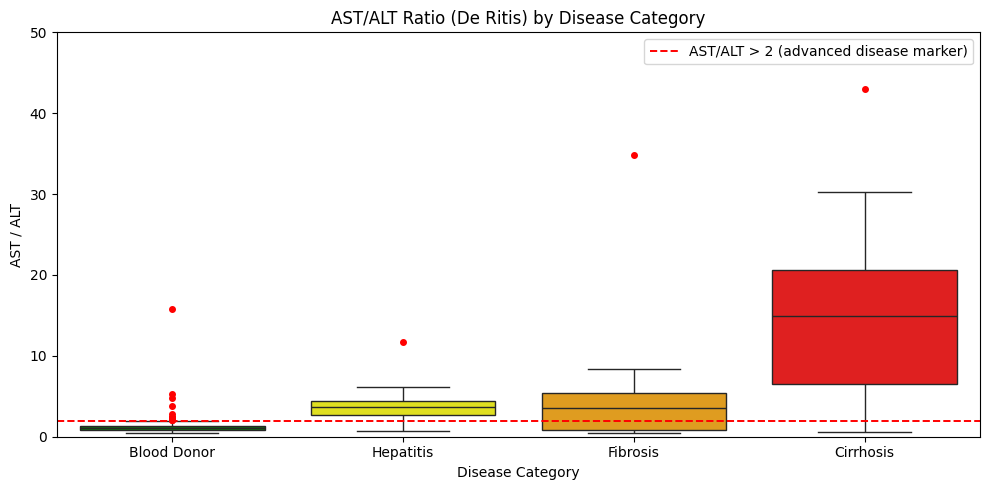


Advanced feature set (30 features):
['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT', 'AST_ALT_ratio', 'ALT_AST_ratio', 'R_value', 'injury_pattern_hepatocellular', 'injury_pattern_mixed', 'injury_pattern_cholestatic', 'globulin_est', 'ALB_PROT_ratio', 'AG_ratio_est', 'log_ALT', 'log_AST', 'log_ALP', 'log_BIL', 'log_GGT', 'log_CREA', 'log_CHE', 'Age_x_AST_ALT_ratio', 'Age_x_BIL', 'Age_x_CHE']


In [41]:
EPS = 1e-9
ALT_ULN = 40
ALP_ULN = 120
feature_cols_ml = ["Age", "ALB", "ALP", "ALT", "AST", "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"]
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    ),
    "SVM": SVC(
        kernel="rbf", class_weight="balanced", probability=True, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, random_state=42
    ),
}

def add_research_engineered_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    dataframe = dataframe.copy()

    # AST/ALT ratio features
    dataframe["AST_ALT_ratio"] = dataframe["AST"] / (dataframe["ALT"] + EPS)
    dataframe["ALT_AST_ratio"] = dataframe["ALT"] / (dataframe["AST"] + EPS)
    dataframe["DeRitis"] = dataframe["AST_ALT_ratio"]

    # R-value features and liver injury pattern classification
    dataframe["R_value"] = (dataframe["ALT"] / ALT_ULN) / ((dataframe["ALP"] / ALP_ULN) + EPS)
    r_notna = dataframe["R_value"].notna()
    dataframe["injury_pattern_hepatocellular"] = np.where(r_notna, (dataframe["R_value"] >= 5).astype(float), np.nan)
    dataframe["injury_pattern_mixed"] = np.where(r_notna, ((dataframe["R_value"] > 2) & (dataframe["R_value"] < 5)).astype(float), np.nan)
    dataframe["injury_pattern_cholestatic"] = np.where(r_notna, (dataframe["R_value"] <= 2).astype(float), np.nan)

    # Protein balance features
    dataframe["globulin_est"] = dataframe["PROT"] - dataframe["ALB"]
    dataframe["ALB_PROT_ratio"] = dataframe["ALB"] / (dataframe["PROT"] + EPS)
    dataframe["AG_ratio_est"] = dataframe["ALB"] / (dataframe["globulin_est"] + EPS)

    # Log transforms
    for col in ["ALT", "AST", "ALP", "BIL", "GGT", "CREA", "CHE"]:
        dataframe[f"log_{col}"] = np.log1p(np.clip(dataframe[col], a_min=0, a_max=None))

    # Age interaction features
    dataframe["Age_x_AST_ALT_ratio"] = dataframe["Age"] * dataframe["AST_ALT_ratio"]
    dataframe["Age_x_BIL"] = dataframe["Age"] * dataframe["BIL"]
    dataframe["Age_x_CHE"] = dataframe["Age"] * dataframe["CHE"]

    return dataframe


# Apply to DataFrames
df = add_research_engineered_features(df)
df_raw = add_research_engineered_features(df_raw)
df_test = add_research_engineered_features(df_test)

key_engineered = ["AST_ALT_ratio", "R_value", "ALB_PROT_ratio"]
print("Research feature summary by category (key engineered features):")
print(df_test.groupby('CategoryName')[key_engineered].describe())

# Boxplot of De Ritis ratio by disease category
fig, ax = plt.subplots(figsize=(10, 5))
category_order = ["Blood Donor", "Hepatitis", "Fibrosis", "Cirrhosis"]
sns.boxplot(
    data=df_test,
    x='CategoryName',
    y='AST_ALT_ratio',
    order=category_order,
    palette=CATEGORY_PALETTE,
    hue='CategoryName',
    hue_order=category_order,
    dodge=False,
    flierprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": 4},
    ax=ax,
)
ax.axhline(y=2, color="red", linestyle='--', linewidth=1.4, label='AST/ALT > 2 (advanced disease marker)')
ax.set_title("AST/ALT Ratio (De Ritis) by Disease Category")
ax.set_xlabel("Disease Category")
ax.set_ylabel("AST / ALT")
ax.legend(loc='upper right')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()

engineered_feature_cols = [
    "AST_ALT_ratio", "ALT_AST_ratio", "R_value",
    "injury_pattern_hepatocellular", "injury_pattern_mixed", "injury_pattern_cholestatic",
    "globulin_est", "ALB_PROT_ratio", "AG_ratio_est",
    "log_ALT", "log_AST", "log_ALP", "log_BIL", "log_GGT", "log_CREA", "log_CHE",
    "Age_x_AST_ALT_ratio", "Age_x_BIL", "Age_x_CHE",
]
feature_cols_adv = feature_cols_ml + engineered_feature_cols
print(f"\nAdvanced feature set ({len(feature_cols_adv)} features):")
print(feature_cols_adv)

### 7.2 SMOTE: Creating more examples for the minority classes

Now that we have performed feature engineering, in this section, we proceed to apply SMOTE (Synthetic Minority Over-sampling Technique). This technique is useful when a dataset is imbalanced, meaning some classes have many more examples than others. This is relevant to our current dataset as discussed prior -- the healthy class dominates proportionally in our dataset. This can cause models to focus too much on the majority class and perform poorly when classifying the minority classes, which is what we care more about in this case.

SMOTE assists us by creating new synthetic examples for the minority class(es). It is integral to note that these are NOT exact copies of existing rows. Rather, SMOTE observes similar minority-class samples and creates new points between them. The end effect of this is that the model has more examples to learn from without simply duplicating the same patients over and over.

The process is as follows:
1. Pick a sample from the minority class
2. Find its nearest neighbors from the same class
3. Choose one of those neighbors at random
4. Create a new synthetic sample somewhere between those two points
5. Repeat until the minority class has enough training examples

This is notably different from using class_weight='balanced'. Class weighting only tells the model to treat minority-class mistakes as more important: it does not give the model any new examples. By creating new training points, SMOTE can help the models learn better decision boundaries.

A critical rule is that SMOTE must only be applied to the training data. To ensure this, we apply SMOTE inside an ImbPipeline during cross validation, guaranteeing that it only runs on training data.

Reference link: https://www.jair.org/index.php/jair/article/view/10302/24590

In [42]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline as SkPipeline

X_advanced_features = df_raw[feature_cols_adv]
X_baseline_features = df_raw[feature_cols_ml]
y_binary_labels = df['IsDiseased']
y_multiclass_labels  = df['Category']

five_fold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_advanced_pipeline(model):
    """ SimpleImputer --> StandardScaler --> SMOTE --> model."""
    return ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", model),
    ])

def make_baseline_pipeline(model):
    """ SimpleImputer --> StandardScaler --> model."""
    return SkPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

print("Advanced pipeline created.")
print(f"Feature set: {feature_cols_adv}")

Advanced pipeline created.
Feature set: ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT', 'AST_ALT_ratio', 'ALT_AST_ratio', 'R_value', 'injury_pattern_hepatocellular', 'injury_pattern_mixed', 'injury_pattern_cholestatic', 'globulin_est', 'ALB_PROT_ratio', 'AG_ratio_est', 'log_ALT', 'log_AST', 'log_ALP', 'log_BIL', 'log_GGT', 'log_CREA', 'log_CHE', 'Age_x_AST_ALT_ratio', 'Age_x_BIL', 'Age_x_CHE']


In [43]:
# Binary classification with feature engineering, SMOTE, and Stratified 5-Fold CV
advanced_binary_results = {}

for model_name, model in models.items():
    # Create pipeline, run, and store results
    advanced_pipeline = make_advanced_pipeline(model)
    cv_model_results = cross_validate(
        advanced_pipeline, X_advanced_features, y_binary_labels,
        cv=five_fold_cv,
        scoring={"f1_macro": "f1_macro", "roc_auc": "roc_auc"},
        n_jobs=-1,
    )
    advanced_binary_results[model_name] = {
        "f1_macro_mean": cv_model_results["test_f1_macro"].mean(),
        "f1_macro_std": cv_model_results["test_f1_macro"].std(),
        "roc_auc_mean": cv_model_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_model_results["test_roc_auc"].std(),
    }

    # Print results for this model
    print(f"{model_name}")
    print(f"Macro F1: {advanced_binary_results[model_name]["f1_macro_mean"]:.3f} +- {advanced_binary_results[model_name]["f1_macro_std"]:.3f}."
          f" | ROC-AUC: {advanced_binary_results[model_name]["roc_auc_mean"]:.3f} +- {advanced_binary_results[model_name]["roc_auc_std"]:.3f}")
    print()

Logistic Regression
Macro F1: 0.931 +- 0.022. | ROC-AUC: 0.967 +- 0.035

Random Forest
Macro F1: 0.955 +- 0.018. | ROC-AUC: 0.990 +- 0.006

SVM
Macro F1: 0.944 +- 0.020. | ROC-AUC: 0.991 +- 0.007

Gradient Boosting
Macro F1: 0.952 +- 0.026. | ROC-AUC: 0.984 +- 0.017



In [44]:
# Now, we construct a baseline using only 5-Fold CV using raw features only
# and also without SMOTE. This will allow us to isolate the effect of SMOTE
# and our feature engineering, providing us a basis for comparisons
# in the oncoming cells.
base_binary_results = {}
base_multi_results = {}

for model_name, model in models.items():
    pipeline = make_baseline_pipeline(model)

    cv_base_results = cross_validate(
        pipeline, df_raw[feature_cols_ml], y_binary_labels,
        cv=five_fold_cv, scoring={"f1_macro": "f1_macro", "roc_auc": "roc_auc"},
        n_jobs=-1,
    )
   
    base_binary_results[model_name] = {
        "f1_macro_mean": cv_base_results["test_f1_macro"].mean(),
        "f1_macro_std": cv_base_results["test_f1_macro"].std(),
        "roc_auc_mean": cv_base_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_base_results["test_roc_auc"].std(),
    }

    # Also do the multi class CV for the same model and store results for later
    cv_base_multi_results = cross_validate(
        pipeline, df_raw[feature_cols_ml], y_multiclass_labels,
        cv=five_fold_cv, scoring={"f1_macro": "f1_macro", "f1_weighted": "f1_weighted"},
        n_jobs=-1,
    )
    base_multi_results[model_name] = {
        "f1_macro_mean": cv_base_multi_results["test_f1_macro"].mean(),
        "f1_macro_std": cv_base_multi_results["test_f1_macro"].std(),
        "f1_weighted_mean": cv_base_multi_results["test_f1_weighted"].mean(),
        "f1_weighted_std": cv_base_multi_results["test_f1_weighted"].std(),
    }
   
    # Print results for this model
    print(f"{model_name}")
    print(f"Baseline Binary F1: {base_binary_results[model_name]["f1_macro_mean"]:.3f} +- {base_binary_results[model_name]["f1_macro_std"]:.3f}.")
    print()

Logistic Regression
Baseline Binary F1: 0.851 +- 0.044.

Random Forest
Baseline Binary F1: 0.915 +- 0.062.

SVM
Baseline Binary F1: 0.893 +- 0.043.

Gradient Boosting
Baseline Binary F1: 0.910 +- 0.046.



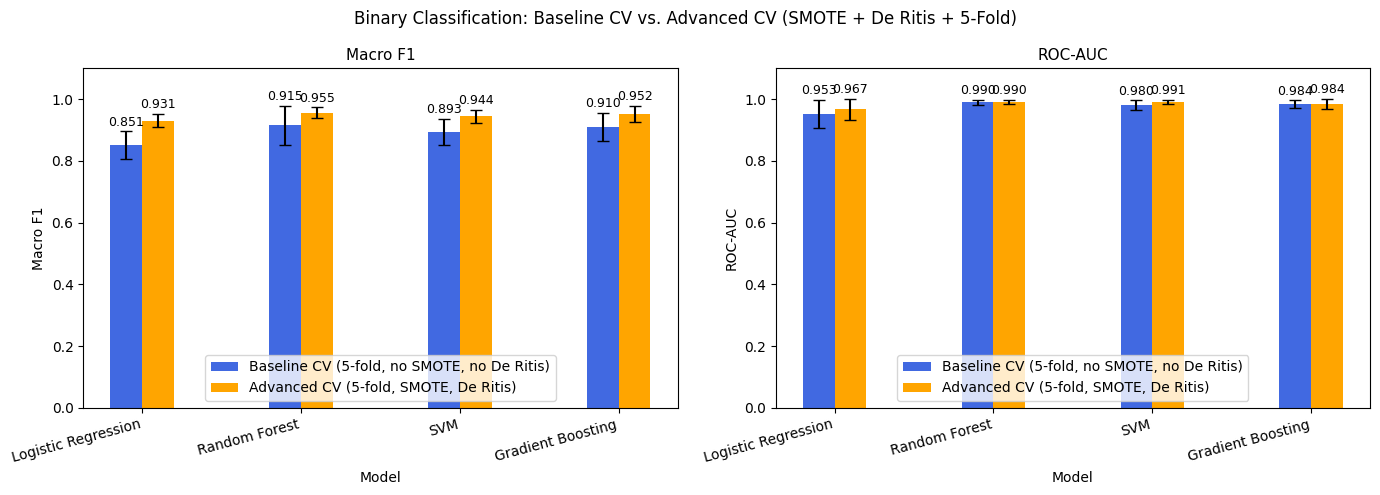

In [45]:
# Plot for binary comparison of Baseline CV vs. Advanced CV
model_names = list(advanced_binary_results.keys())
orig_f1 = [base_binary_results[n]["f1_macro_mean"] for n in model_names]
orig_f1_e = [base_binary_results[n]["f1_macro_std"] for n in model_names]
orig_auc = [base_binary_results[n]["roc_auc_mean"] for n in model_names]
orig_auc_e = [base_binary_results[n]["roc_auc_std"] for n in model_names]
adv_f1 = [advanced_binary_results[n]["f1_macro_mean"] for n in model_names]
adv_f1_e = [advanced_binary_results[n]["f1_macro_std"] for n in model_names]
adv_auc = [advanced_binary_results[n]["roc_auc_mean"] for n in model_names]
adv_auc_e = [advanced_binary_results[n]["roc_auc_std"] for n in model_names]

# Make plots
model_positions = np.arange(len(model_names))
width = 0.2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Binary Classification: Baseline CV vs. Advanced CV (SMOTE + De Ritis + 5-Fold)")

for ax, orig, orig_e, adv, adv_e, metric in [
    (ax1, orig_f1, orig_f1_e, adv_f1, adv_f1_e,  "Macro F1"),
    (ax2, orig_auc, orig_auc_e, adv_auc, adv_auc_e, "ROC-AUC"),
]:
    b1 = ax.bar(model_positions - width/2, orig, width, label="Baseline CV (5-fold, no SMOTE, no De Ritis)",
                color="royalblue", yerr=orig_e, capsize=4)
    b2 = ax.bar(model_positions + width/2, adv,  width, label="Advanced CV (5-fold, SMOTE, De Ritis)",
                color="orange", yerr=adv_e, capsize=4)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.set_xticks(model_positions)
    ax.set_xticklabels(model_names, rotation=15, ha="right")
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=9)
    ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=9)

plt.tight_layout()
plt.show()


### Interpretation: Binary Baseline vs. Advanced Comparison


The advanced pipeline improved binary classification performance for every model, especially for Macro F1. Logistic Regression improved from 0.851 to 0.931, Random Forest from 0.915 to 0.955, SVM from 0.893 to 0.944, and Gradient Boosting from 0.910 to 0.952. This suggests that the added clinical features and SMOTE helped the models classify both liver disease and non-liver disease cases more evenly.


ROC-AUC was already very high in the baseline models, so the improvements were smaller. Most models remaiend around 0.98-0.99, meaning they were already strong at separating the two binary classes. The main benefit of the advanced pipeline is thus not only better separation but better balanced classification performance across classes.


Based on these results, the advanced pipeline is better for the binary task. Since Macro F1 improved consistently across all models, the next step is to use the advanced setup for further analysis and focus on the best-performing models.


In [46]:
# Multi-class classification with our feature engineering, SMOTE, and Stratified 5-Fold CV
advanced_multi_results = {}

for model_name, model in models.items():
    pipeline = make_advanced_pipeline(model)
    cv_scores = cross_validate(
        pipeline, X_advanced_features, y_multiclass_labels,
        cv=five_fold_cv,
        scoring={"f1_macro": "f1_macro", "f1_weighted": "f1_weighted"},
        n_jobs=-1,
    )
    advanced_multi_results[model_name] = {
        "f1_macro_mean": cv_scores["test_f1_macro"].mean(),
        "f1_macro_std": cv_scores["test_f1_macro"].std(),
        "f1_weighted_mean": cv_scores["test_f1_weighted"].mean(),
        "f1_weighted_std": cv_scores["test_f1_weighted"].std(),
    }
   
    # Print results for this model
    print(f"{model_name}")
    print(f"Macro F1: {advanced_multi_results[model_name]["f1_macro_mean"]:.3f} +- {advanced_multi_results[model_name]["f1_macro_std"]:.3f}."
          f" | Weighted F1: {advanced_multi_results[model_name]["f1_weighted_mean"]:.3f} +- {advanced_multi_results[model_name]["f1_weighted_std"]:.3f}")
    print()

Logistic Regression
Macro F1: 0.671 +- 0.102. | Weighted F1: 0.935 +- 0.010

Random Forest
Macro F1: 0.703 +- 0.084. | Weighted F1: 0.947 +- 0.015

SVM
Macro F1: 0.660 +- 0.110. | Weighted F1: 0.935 +- 0.019

Gradient Boosting
Macro F1: 0.705 +- 0.105. | Weighted F1: 0.949 +- 0.014



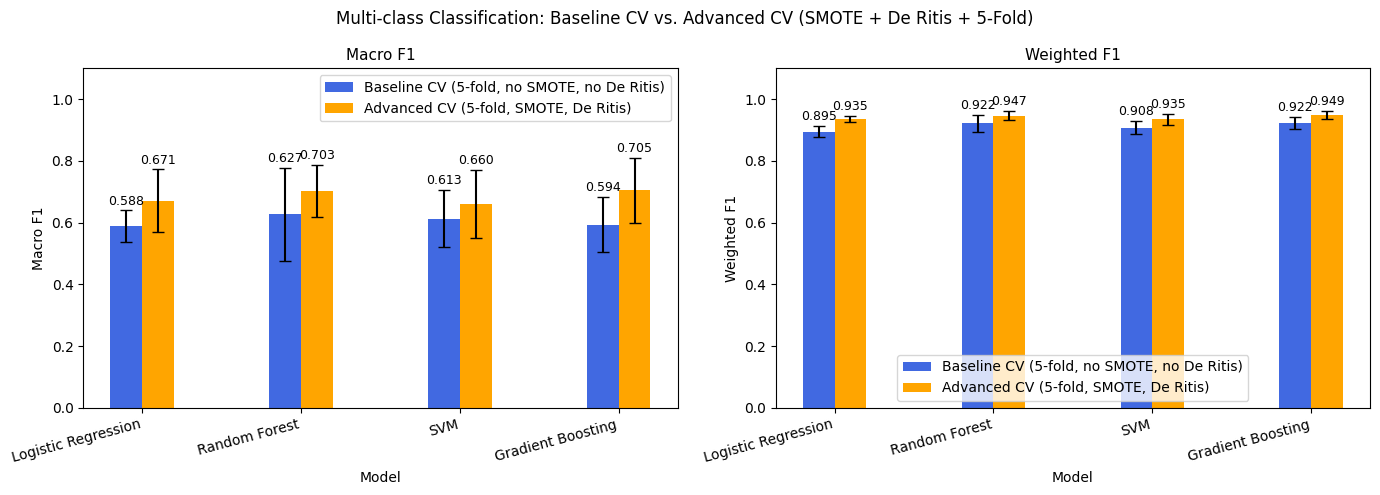

In [47]:
# Multi-class comparison: Baseline CV vs. Advanced CV (SMOTE + De Ritis + 5-Fold)
orig_mf1 = [base_multi_results[n]["f1_macro_mean"] for n in model_names]
orig_mf1_e = [base_multi_results[n]["f1_macro_std"] for n in model_names]
orig_wf1 = [base_multi_results[n]["f1_weighted_mean"] for n in model_names]
orig_wf1_e = [base_multi_results[n]["f1_weighted_std"] for n in model_names]
adv_mf1 = [advanced_multi_results[n]["f1_macro_mean"] for n in model_names]
adv_mf1_e = [advanced_multi_results[n]["f1_macro_std"] for n in model_names]
adv_wf1 = [advanced_multi_results[n]["f1_weighted_mean"] for n in model_names]
adv_wf1_e = [advanced_multi_results[n]["f1_weighted_std"] for n in model_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Multi-class Classification: Baseline CV vs. Advanced CV (SMOTE + De Ritis + 5-Fold)")

for ax, orig, orig_e, adv, adv_e, metric in [
    (ax1, orig_mf1, orig_mf1_e, adv_mf1, adv_mf1_e, "Macro F1"),
    (ax2, orig_wf1, orig_wf1_e, adv_wf1, adv_wf1_e, "Weighted F1"),
]:
    b1 = ax.bar(model_positions - width/2, orig, width, label="Baseline CV (5-fold, no SMOTE, no De Ritis)",
                color="royalblue", yerr=orig_e, capsize=4)
    b2 = ax.bar(model_positions + width/2, adv,  width, label="Advanced CV (5-fold, SMOTE, De Ritis)",
                color="orange", yerr=adv_e, capsize=4)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.set_xticks(model_positions)
    ax.set_xticklabels(model_names, rotation=15, ha="right")
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=9)
    ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=9)


plt.tight_layout()
plt.show()

### Interpretation: Multi-class Baseline vs. Advanced Comparison


The advanced pipeline improved multi-class performance for every model. The biggest improvement was in Macro F1, meaning the models became better at handling the smaller disease classes, not just the majority class. Notably, Gradient Boosting improved from 0.594 to 0.705, Random Forest improved from 0.627 to 0.703, and Logistic Regression improved from 0.588 to 0.671.


Weighted F1 was already high for the baseline models, but it also improved slightly across all models. This shows that the advanced pipeline improved overall accuracy while also helping with the harder, underrepresented classes.


The main takeaway is that our advanced setup (feature engineering + SMOTE) was more helpful for the multi-class task than the baseline setup. Since the multi-class problem is harder than the binary problem, the lower Macro F1 scores make sense. Based on these results, the advanced pipeline should be kept, with Random Forest and Gradient Boosting looking like the strongest options for the multi-class classification task. This showcases how you can use advanced techniques in order to improve the accuracy/performance of models you train for any given purpose.


### 7.3 Advanced Analysis Summary and Interpretation


The advanced analysis portion of our tutorial is meant to show how the modeling process changes when we move from a basic train-test setup to a more thought-out cross-validation pipeline. The baseline CV pipeline uses only the original lab values, while the advanced CV pipeline adds feature engineering and SMOTE. This lets us compare whether the extra preprocessing actually helps, instead of assuming it improves the model.


The main lesson from this section is that model evaluation should focus on more than accuracy. Because the dataset is imbalanced, a model can look strong overall while still performing poorly on smaller disease classes. That is why Macro F1 is especially important here, as it gives each class equal weight and helps show whether the model is learning the minority classes, not just the majority class.


The binary classification results show that the advanced pipeline gives a clear improvement in balanced performance. The multi-class results show the same general pattern, but the task is harder because the model has to separate several disease stages instead of only disease vs. non-disease. This is why the multi-class Macro F1 scores are lower than the binary scores.


For the next modeling step, the advanced pipeline is the stronger choice because it improves performance more consistently across models. However, the results should still be interpreted model by model. SMOTE and engineered features helped overall, but some models benefited more than others. In a real modeling workflow, this means we should choose the final model based on the cross-validation evidence, not just on which method seems "more advanced." Benchmarking is always essential!


Also, note the importance of doing extra research tailored to your problem. None of us knew what SMOTE was before, but an identification of the class imbalance problem followed by a short amount of research led us to this proven remedy.


Overall, this section supports keeping the advanced setup for final comparison, especially because it handles class imbalance more directly and uses features that better reflect liver-disease patterns


## 8. Looking forward: Using additional datasets


While our advanced analysis does improve our model outcomes, the imbalance/limited amount of diseased patients in our dataset is still a point of caution, especially when considering overfitting on multi-class.


This emphasizes how important your starting dataset is. No matter the amount of cleaning, exploration, feature engineering, and advanced techniques you apply, your base data is the most fundamental aspect of whatever data-driven analysis you are performing.


While we end our tutorial here, a set of next steps we identified involves combining multiple related datasets with our UCI HCV dataset to build a more robust baseline to perform analysis.


Two datasets we identified as potential candidates include:
1.  UCI: ILPD Indian Liver Patient Dataset
Link: https://archive.ics.uci.edu/ml/datasets/ILPD%2B%28Indian%2BLiver%2BPatient%2BDataset%29


2.  UCI: Hepatitis C Virus for Egyptian Patients
Link: https://archive.ics.uci.edu/ml/datasets/hepatitis%2BC%2BVirus%2B%28HCV%29%2Bfor%2BEgyptian%2Bpatients


By combining these datasets with our starting data, we could achieve a more robust dataset with less drastic class imbalance (including more diseases patient samples in our data) in order to reduce overfitting of our ML models. Of course, this is easier said than done, as the datasets' features do not exactly match. One may have to apply standardization of units/scales, imputation, and further cleaning, which may take considerable care and time.


# The End


Thank you for reading through our tutorial!
